# (Title)
## 2879105W Weijia Wang

# 1. Introduction
In today's context of environmental change and increasing energy demand, understanding household energy consumption patterns becomes key to ensuring energy sustainability and quality of life in cities. As a densely populated and economically active global city, London's energy consumption is particularly important. In recent years, the City of London has accumulated a large amount of data on household energy use through the introduction of smart meters. These data not only provide an accurate reading of energy consumption, but also record time information, forming a kind of time series data.
The aim of this study was to analyse household energy consumption patterns in the London region using a comprehensive data set of smart meter readings and weather conditions in London. The main research contents of the study include:
1. Analysis of daily and hourly energy consumption patterns: Investigate energy use trends in different households to identify common patterns and anomalies in daily or hourly energy consumption.
2. Cluster analysis based on time series: Integrate historical energy consumption data, weather conditions and demographic information to explore the daily rhythm of household energy demand. Considering the influence of different weather conditions on household energy consumption, the influence of weather conditions on energy use patterns is explored by using weather conditions as characteristic values.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import dask.dataframe as dd
from dask import delayed
from dask.diagnostics import ProgressBar
from pandas.plotting import register_matplotlib_converters
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from joblib import Parallel, delayed, Memory, cpu_count
from dtaidistance import dtw
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import MDS
from fastdtw import fastdtw

In [2]:
# from umap import UMAP

In [3]:
memory = Memory(location='cachedir', verbose=0)

In [4]:
cpu_count()

32

In [5]:
# Manual registration of Matplotlib converters
register_matplotlib_converters()

# 2. Integration and analysis of key data
## Data Import
The data set named "Smart meters in London" uploaded by Jean-Michel (2018) in kaggle was used in this study. The data set mainly includes two parts. The first part is energy consumption data for 5,567 London households that participated in the UK Power Network-led Low Carbon London project between November 2011 and February 2014, and the second part is weather data for the London area during that period.

In [6]:
@memory.cache
def read_hhblock_dataset(file_path):
    # Get the paths of all CSV files in the folder
    csv_files = [os.path.join(file_path, file) for file in os.listdir(file_path) if file.endswith('.csv')]

    # Read each CSV file as a DataFrame and store it in the list
    dataframes = [pd.read_csv(file) for file in csv_files]

    # Merge all DataFrames into one large DataFrame
    hhblock_big_dataframe = pd.concat(dataframes, ignore_index=True)

    return hhblock_big_dataframe

In [7]:
@memory.cache
def data_import():
    informations_households = pd.read_csv('archive/informations_households.csv')
    daily_dataset = pd.read_csv('archive/daily_dataset.csv')
    halfhourly_block_0 = pd.read_csv('archive/halfhourly_dataset/halfhourly_dataset/block_0.csv')
    hhblock_0 = pd.read_csv('archive/hhblock_dataset/hhblock_dataset/block_0.csv')
    hhblock_big_dataframe = read_hhblock_dataset('archive\hhblock_dataset\hhblock_dataset')
    uk_bank_holidays = pd.read_csv('archive/uk_bank_holidays.csv')
    weather_daily_darksky = pd.read_csv('archive/weather_daily_darksky.csv')
    weather_hourly_darksky = pd.read_csv('archive/weather_hourly_darksky.csv')
    return informations_households, daily_dataset, halfhourly_block_0, hhblock_0, hhblock_big_dataframe, uk_bank_holidays, weather_daily_darksky, weather_hourly_darksky

In [8]:
%%time
informations_households, daily_dataset, halfhourly_block_0, hhblock_0, hhblock_big_dataframe, uk_bank_holidays, weather_daily_darksky, weather_hourly_darksky = data_import()

CPU times: total: 109 ms
Wall time: 1.2 s


In [9]:
# %prun -s cumulative -l 10 informations_households, daily_dataset, halfhourly_block_0, hhblock_0, hhblock_big_dataframe, uk_bank_holidays, weather_daily_darksky, weather_hourly_darksky = data_import()

## 2.1 Household energy consumption pattern

In [225]:
GLOBAL_PLOT_LEVEL = 2  # 0: no graphics, 1: some graphics, 2: all graphics
def plot_level(level, function):
    if GLOBAL_PLOT_LEVEL >= level:
        function()

## informations_households.csv
Informations_house.csv contains information about each household, such as household ID, household type, total electricity consumption of the household, etc. Filter out lines with ACORN values of "acorn-u" and "ACORN-" for this dataset, which contain incomplete or unclear records. Upon inspection, the processed data set does not contain missing values.

In [11]:
informations_households

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0
...,...,...,...,...,...
5561,MAC002056,Std,ACORN-U,ACORN-U,block_111
5562,MAC004587,Std,ACORN-U,ACORN-U,block_111
5563,MAC004828,Std,ACORN-U,ACORN-U,block_111
5564,MAC001704,ToU,ACORN-U,ACORN-U,block_111


In [12]:
display(informations_households.nunique())

LCLid            5566
stdorToU            2
Acorn              19
Acorn_grouped       5
file              112
dtype: int64

In [13]:
display(informations_households['Acorn'].value_counts())

Acorn
ACORN-E    1567
ACORN-Q     831
ACORN-F     684
ACORN-H     455
ACORN-L     342
ACORN-D     292
ACORN-G     205
ACORN-K     165
ACORN-A     157
ACORN-N     152
ACORN-C     151
ACORN-M     113
ACORN-J     112
ACORN-P     110
ACORN-O     103
ACORN-I      51
ACORN-U      49
ACORN-B      25
ACORN-        2
Name: count, dtype: int64

In [14]:
display(informations_households['Acorn_grouped'].value_counts())

Acorn_grouped
Affluent       2192
Adversity      1816
Comfortable    1507
ACORN-U          49
ACORN-            2
Name: count, dtype: int64

In [15]:
display(informations_households['file'].value_counts())

file
block_0      50
block_1      50
block_82     50
block_81     50
block_80     50
             ..
block_33     50
block_32     50
block_31     50
block_30     50
block_111    16
Name: count, Length: 112, dtype: int64

In [16]:
informations_households_filtered = informations_households[
    (informations_households['Acorn'] != 'ACORN-U') & (informations_households['Acorn'] != 'ACORN-')]
informations_households_filtered

,LCLid,stdorToU,Acorn,Acorn_grouped,file
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0
5,MAC003579,Std,ACORN-A,Affluent,block_0
6,MAC003566,Std,ACORN-A,Affluent,block_0
...,...,...,...,...,...
5512,MAC002185,Std,ACORN-Q,Adversity,block_110
5513,MAC002347,Std,ACORN-Q,Adversity,block_110
5514,MAC000088,ToU,ACORN-Q,Adversity,block_110
5515,MAC002331,Std,ACORN-Q,Adversity,block_110


In [17]:
display(informations_households_filtered['Acorn'].value_counts())

Acorn
ACORN-E    1567
ACORN-Q     831
ACORN-F     684
ACORN-H     455
ACORN-L     342
ACORN-D     292
ACORN-G     205
ACORN-K     165
ACORN-A     157
ACORN-N     152
ACORN-C     151
ACORN-M     113
ACORN-J     112
ACORN-P     110
ACORN-O     103
ACORN-I      51
ACORN-B      25
Name: count, dtype: int64

In [18]:
display(informations_households_filtered['Acorn_grouped'].value_counts())

Acorn_grouped
Affluent       2192
Adversity      1816
Comfortable    1507
Name: count, dtype: int64

In [19]:
valid_lclid = informations_households_filtered['LCLid'].unique()
display(pd.Series(valid_lclid))

0       MAC000002
1       MAC003613
2       MAC003597
3       MAC003579
4       MAC003566
          ...    
5510    MAC002185
5511    MAC002347
5512    MAC000088
5513    MAC002331
5514    MAC000318
Length: 5515, dtype: object

In [20]:
unique_acorn_values = informations_households_filtered[informations_households_filtered['Acorn_grouped'] == 'Affluent'][
    'Acorn'].unique()
display(pd.Series(unique_acorn_values))

0    ACORN-A
1    ACORN-B
2    ACORN-C
3    ACORN-D
4    ACORN-E
dtype: object

In [21]:
unique_acorn_values = \
    informations_households_filtered[informations_households_filtered['Acorn_grouped'] == 'Comfortable'][
        'Acorn'].unique()
display(pd.Series(unique_acorn_values))

0    ACORN-F
1    ACORN-G
2    ACORN-H
3    ACORN-I
4    ACORN-J
dtype: object

In [22]:
unique_acorn_values = \
    informations_households_filtered[informations_households_filtered['Acorn_grouped'] == 'Adversity']['Acorn'].unique()
display(pd.Series(unique_acorn_values))

0    ACORN-K
1    ACORN-L
2    ACORN-M
3    ACORN-N
4    ACORN-O
5    ACORN-P
6    ACORN-Q
dtype: object

In [23]:
missing_informations_households_values = informations_households_filtered.isnull().sum()
display(missing_informations_households_values)

LCLid            0
stdorToU         0
Acorn            0
Acorn_grouped    0
file             0
dtype: int64

## daily_dataset

When processing the daily_dataset.csv dataset, convert the "day" column date string to type "datetime64" and use "valid_lclid" to filter out data with the same family ID. After that, a series of visual charts show the characteristics of the key data in the dataset.

In [24]:
daily_dataset.head(1000)

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066
...,...,...,...,...,...,...,...,...,...
995,MAC000132,2012-06-20,0.1350,0.267854,1.208,48,0.238778,12.857,0.072
996,MAC000132,2012-06-21,0.1505,0.240729,0.954,48,0.242623,11.555,0.057
997,MAC000132,2012-06-22,0.1490,0.225021,1.193,48,0.231525,10.801,0.046
998,MAC000132,2012-06-23,0.2135,0.317583,0.875,48,0.241235,15.244,0.060


In [25]:
@ memory.cache
def process_daily_dataset(df):
    # Convert 'day' column to datetime format
    df['day'] = pd.to_datetime(df['day'])

    # Convert 'LCLid' column to datetime format
    df['LCLid'] = df['LCLid'].astype('category')
    
    # Cleaning out data without Acorn information
    df = df[df['LCLid'].isin(valid_lclid)]

    return df

In [26]:
filtered_daily_dataset = process_daily_dataset(daily_dataset)
filtered_daily_dataset.head(1000)

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066
...,...,...,...,...,...,...,...,...,...
995,MAC000132,2012-06-20,0.1350,0.267854,1.208,48,0.238778,12.857,0.072
996,MAC000132,2012-06-21,0.1505,0.240729,0.954,48,0.242623,11.555,0.057
997,MAC000132,2012-06-22,0.1490,0.225021,1.193,48,0.231525,10.801,0.046
998,MAC000132,2012-06-23,0.2135,0.317583,0.875,48,0.241235,15.244,0.060


In [27]:
filtered_daily_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3480100 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   LCLid          category      
 1   day            datetime64[ns]
 2   energy_median  float64       
 3   energy_mean    float64       
 4   energy_max     float64       
 5   energy_count   int64         
 6   energy_std     float64       
 7   energy_sum     float64       
 8   energy_min     float64       
dtypes: category(1), datetime64[ns](1), float64(6), int64(1)
memory usage: 245.6 MB


### Missing value handling

In [28]:
missing_filtered_daily_dataset_values = filtered_daily_dataset.isnull().sum()
display(missing_filtered_daily_dataset_values)

LCLid                0
day                  0
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11214
energy_sum          30
energy_min          30
dtype: int64

In [29]:
rows_with_missing_values_specific_columns = filtered_daily_dataset[
    filtered_daily_dataset[['energy_std']].isnull().any(axis=1)]
rows_with_missing_values_specific_columns

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
806,MAC000131,2014-02-28,0.075,0.075,0.075,1,NaN,0.075,0.075
1613,MAC000132,2014-02-28,0.049,0.049,0.049,1,NaN,0.049,0.049
2434,MAC000221,2014-02-28,0.592,0.592,0.592,1,NaN,0.592,0.592
3255,MAC000228,2014-02-28,0.039,0.039,0.039,1,NaN,0.039,0.039
4076,MAC000234,2014-02-28,0.071,0.071,0.071,1,NaN,0.071,0.071
...,...,...,...,...,...,...,...,...,...
3507356,MAC004926,2014-02-28,0.033,0.033,0.033,1,NaN,0.033,0.033
3508127,MAC004932,2014-02-28,0.177,0.177,0.177,1,NaN,0.177,0.177
3508898,MAC004937,2014-02-28,0.084,0.084,0.084,1,NaN,0.084,0.084
3509666,MAC004965,2014-02-28,0.618,0.618,0.618,1,NaN,0.618,0.618


In [30]:
rows_with_missing_values_specific_columns = filtered_daily_dataset[
    filtered_daily_dataset[['energy_median', 'energy_mean']].isnull().any(axis=1)]
rows_with_missing_values_specific_columns

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
37231,MAC000410,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN
129012,MAC005560,2012-12-19,NaN,NaN,NaN,0,NaN,NaN,NaN
138461,MAC002110,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN
205939,MAC001065,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN
293243,MAC001229,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN
295223,MAC001278,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN
692446,MAC001478,2013-03-08,NaN,NaN,NaN,0,NaN,NaN,NaN
867057,MAC005558,2012-12-19,NaN,NaN,NaN,0,NaN,NaN,NaN
902532,MAC000393,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN
913986,MAC002014,2012-12-18,NaN,NaN,NaN,0,NaN,NaN,NaN


### Grouping Visualisation

In [31]:
def plot_column_histogram(df, column_name):
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column_name], kde=True)
    plt.title(f'Histogram of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Frequency')
    plt.show()

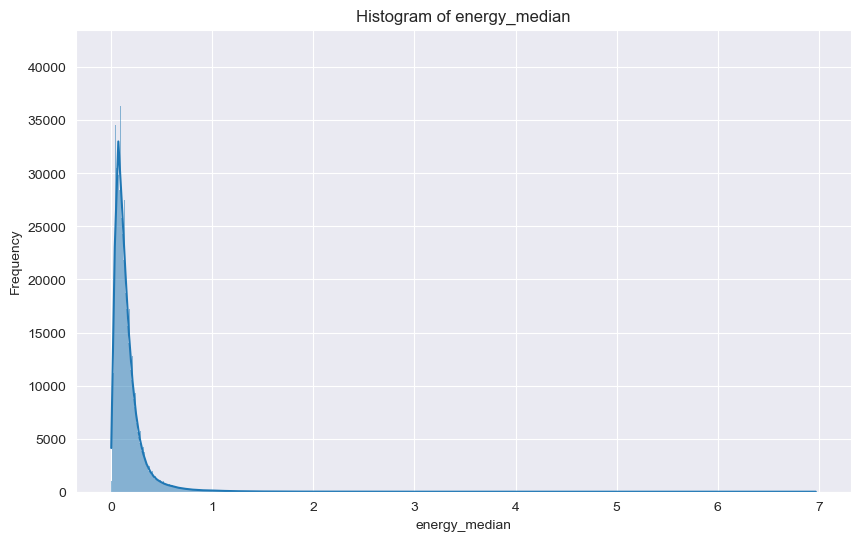

In [226]:
plot_level(1, lambda: plot_column_histogram(filtered_daily_dataset, 'energy_median'))

- Most data points are between 0 and 1 KWH, indicating that on most days, the median energy consumption is below 1 KWH.

In [33]:
columns_all = ['energy_median', 'energy_mean', 'energy_max', 'energy_std', 'energy_sum', 'energy_min']
columns_without_sum = ['energy_median', 'energy_mean', 'energy_max', 'energy_std', 'energy_min']
columns_without_min = ['energy_median', 'energy_mean', 'energy_max', 'energy_std', 'energy_sum']

In [34]:
def plot_column_histograms(df, column_names):
    plt.figure(figsize=(10, 6))
    for column_name in column_names:
        sns.histplot(df[column_name], kde=True, label=column_name)
    plt.title(f'Histogram of {" vs ".join(column_names)}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.xscale('log')  # Use of logarithmic scales
    plt.legend()
    plt.show()

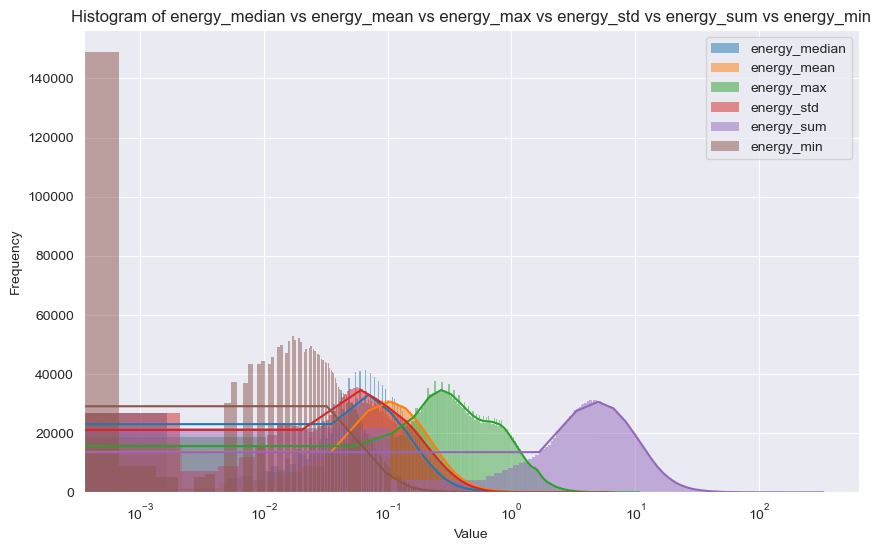

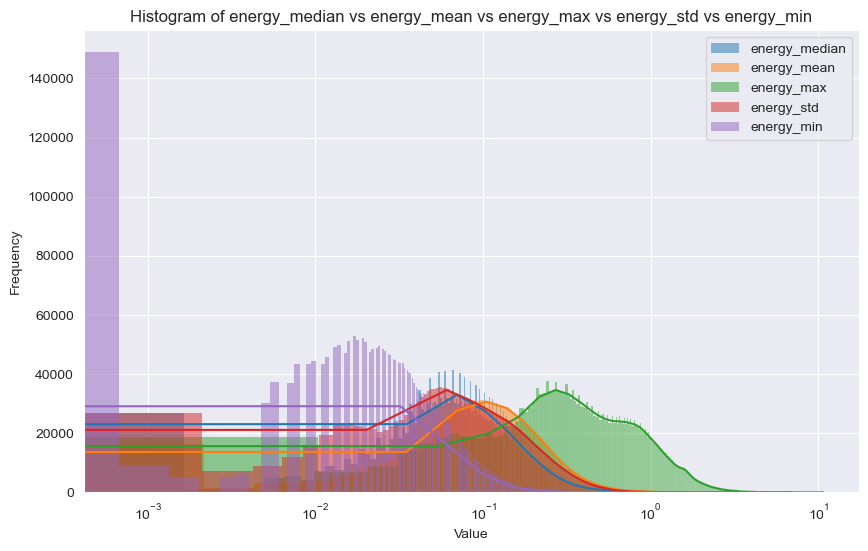

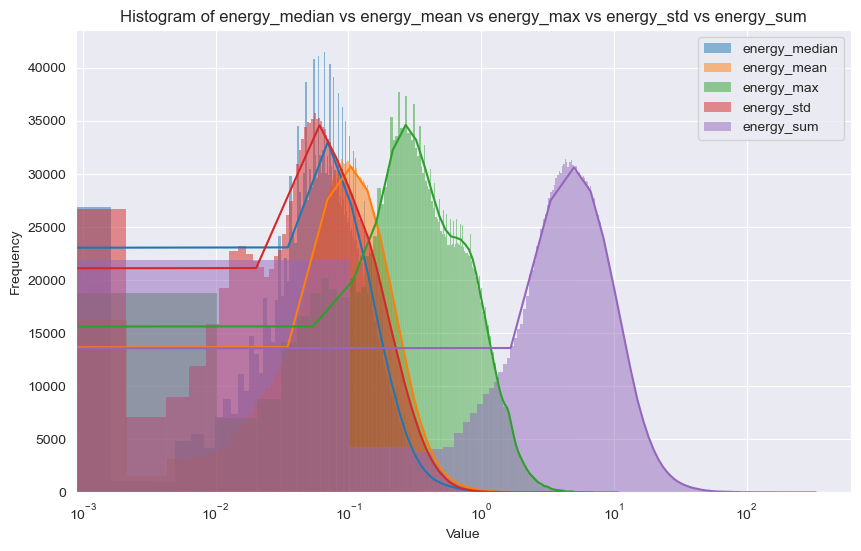

In [227]:
plot_level(1, lambda: plot_column_histograms(filtered_daily_dataset, columns_all))
plot_level(1, lambda: plot_column_histograms(filtered_daily_dataset, columns_without_sum))
plot_level(1, lambda: plot_column_histograms(filtered_daily_dataset, columns_without_min))

- In this log-scaled histogram, "energy_median," "energy_mean," and "energy_max" have similar shapes and considerable overlap, especially in the lower range of values, suggesting that days with lower median energy use also tend to have lower mean and maximum use.

In [36]:
def plot_multiple_column_histograms(df, columns):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for i, column in enumerate(columns):
        sns.histplot(df[column], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram of {column}')
        axes[i].set_xlabel(column)
        axes[i].set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

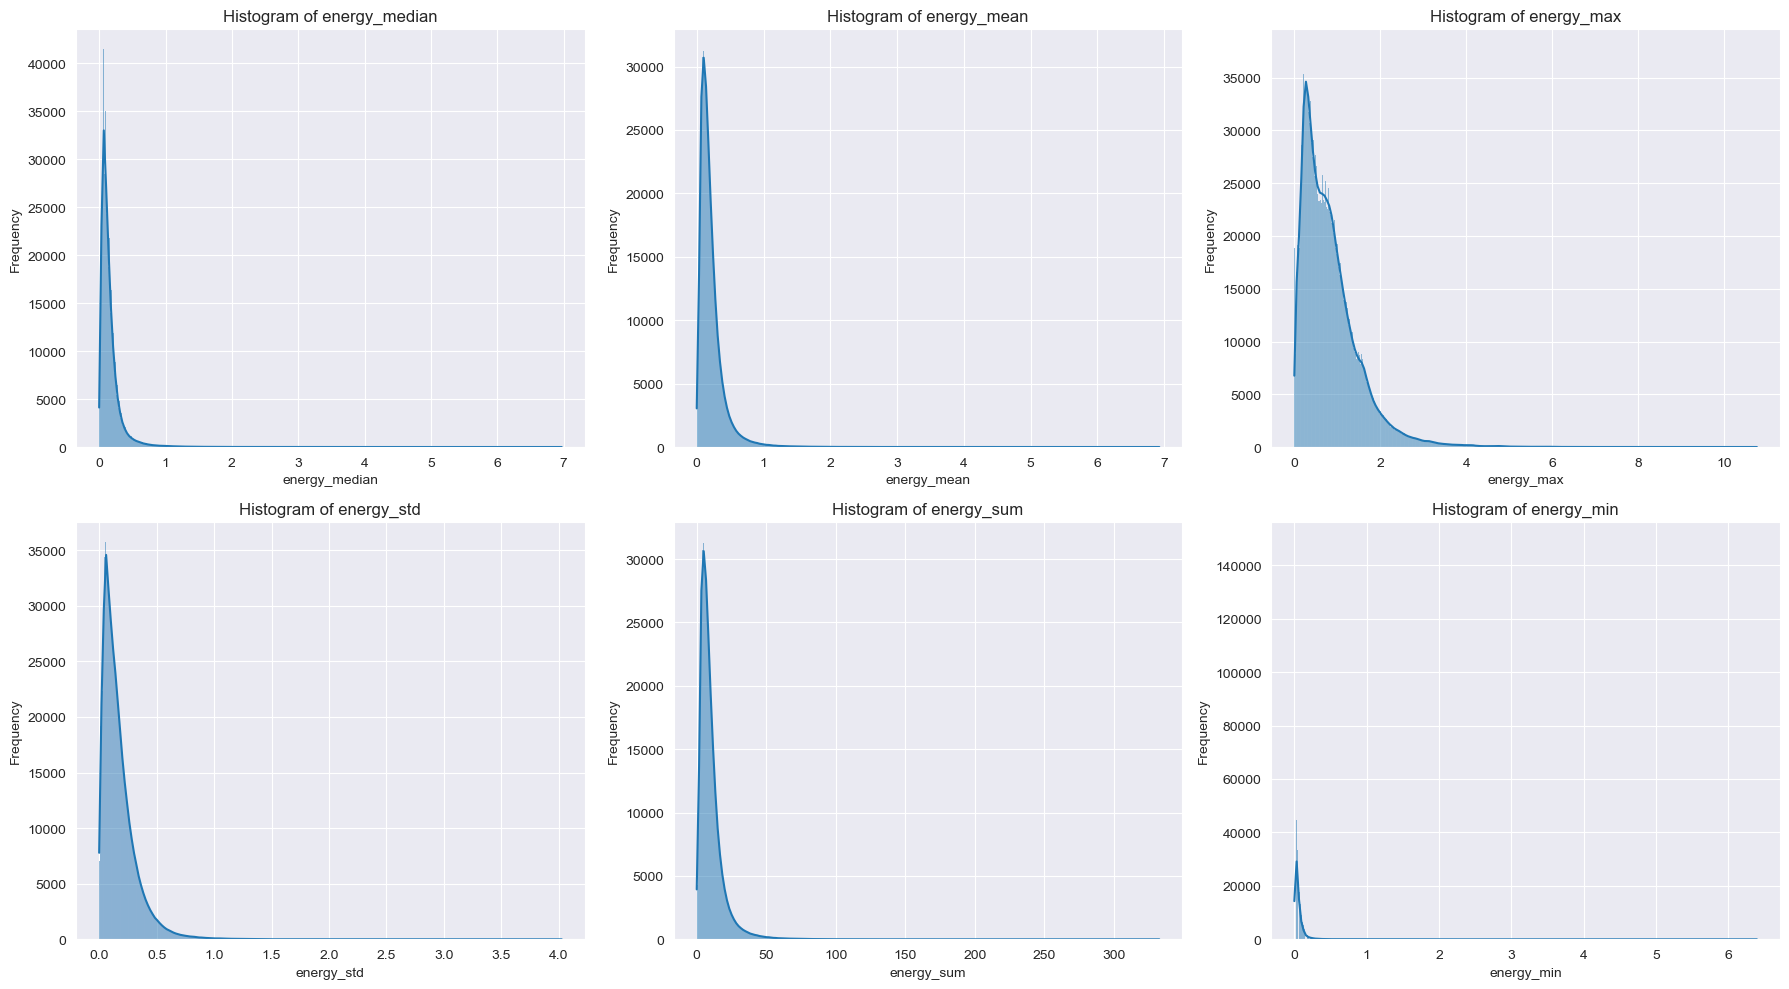

In [228]:
plot_level(1, lambda: plot_multiple_column_histograms(filtered_daily_dataset, columns_all))

- This set of histograms combines daily energy consumption patterns and variability in the data set. energy_sum exhibits a right-skewed distribution, but has a higher frequency of high-value regions relative to the median and average, indicating that although total daily energy consumption is low most of the time, there are days when consumption can be significant.

In [38]:
def plot_columns_boxplot(df, columns):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[columns])
    plt.xticks(rotation=45)
    plt.title('Box plot of Energy Consumption Statistics')
    plt.show()

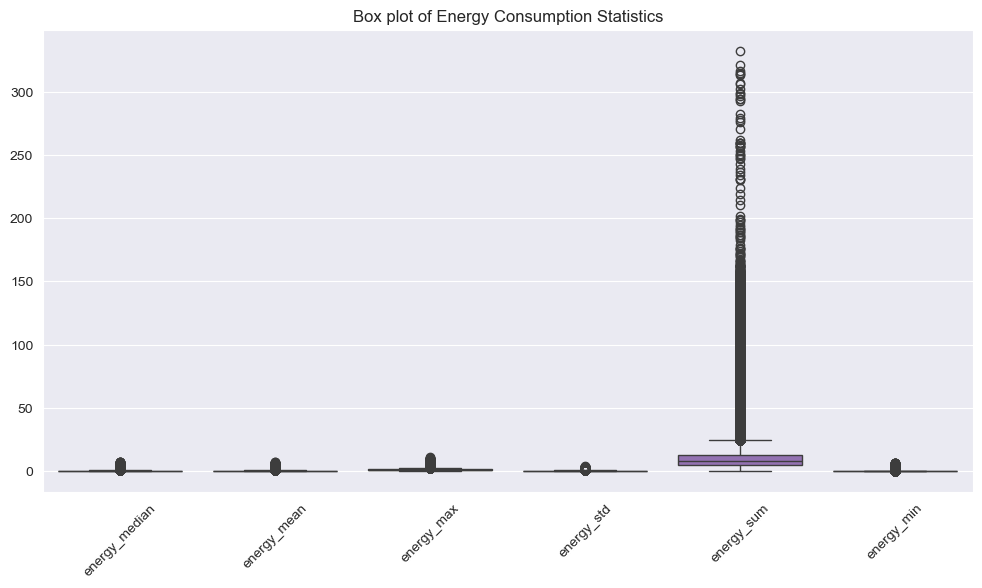

In [229]:
plot_level(1, lambda: plot_columns_boxplot(filtered_daily_dataset, columns_all))

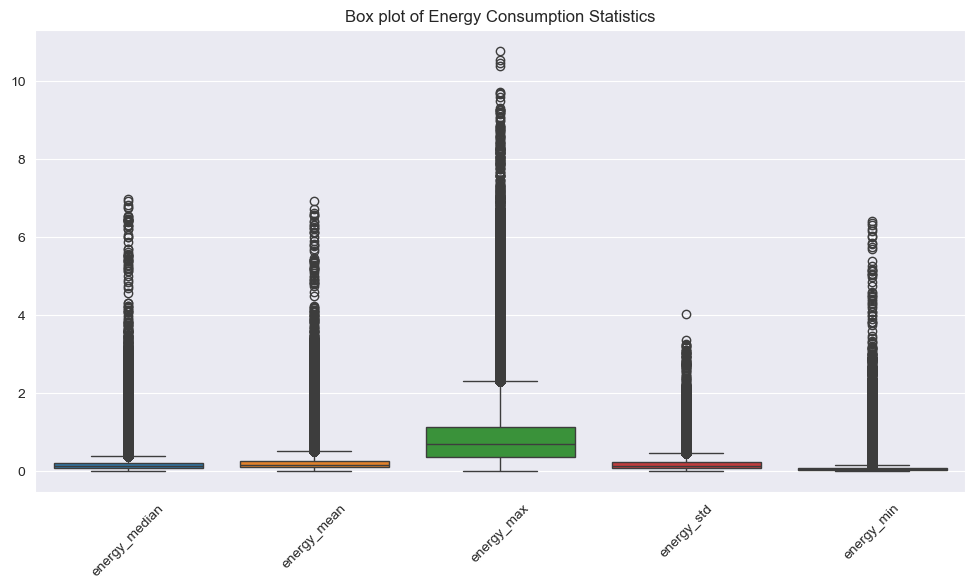

In [230]:
plot_level(1, lambda: plot_columns_boxplot(filtered_daily_dataset, columns_without_sum))

- In the adjusted box diagram, outliers generally appear at the top, possibly due to periods of unusually high energy use.

In [41]:
def plot_column_difference(df, column1, column2):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=column1, y=column2, data=df)
    plt.title(f'Scatter plot of {column1} vs. {column2}')
    plt.xlabel(column1)
    plt.ylabel(column2)
    plt.show()

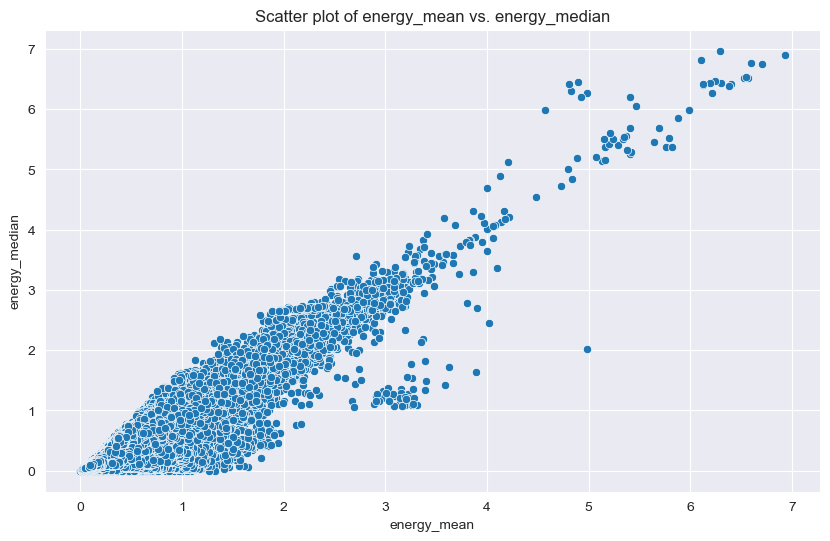

In [231]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_mean', 'energy_median'))

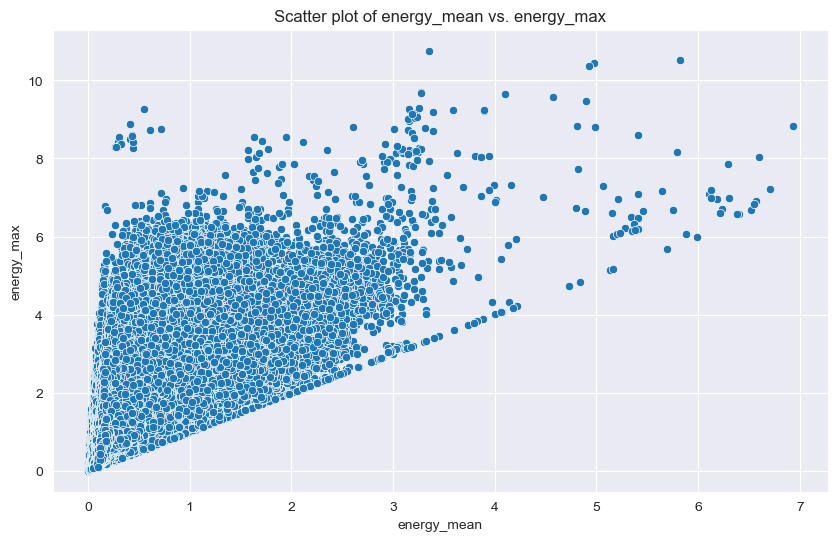

In [232]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_mean', 'energy_max'))

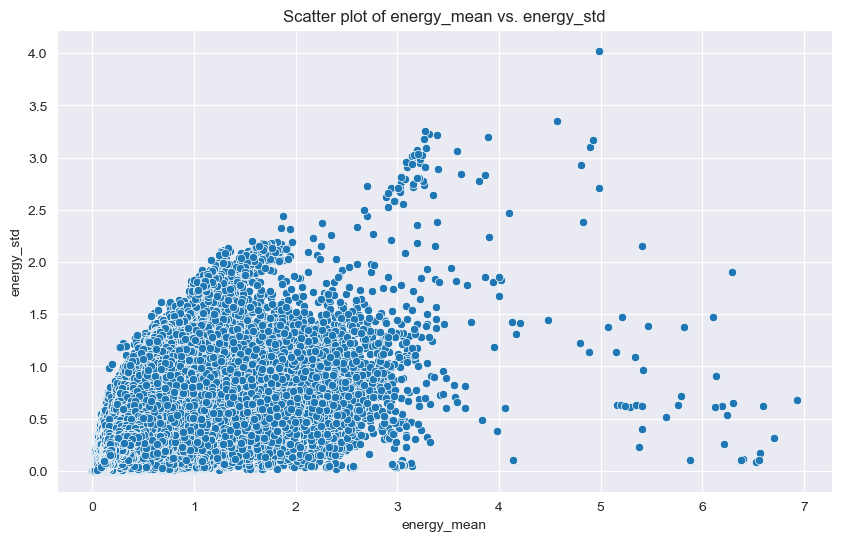

In [233]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_mean', 'energy_std'))

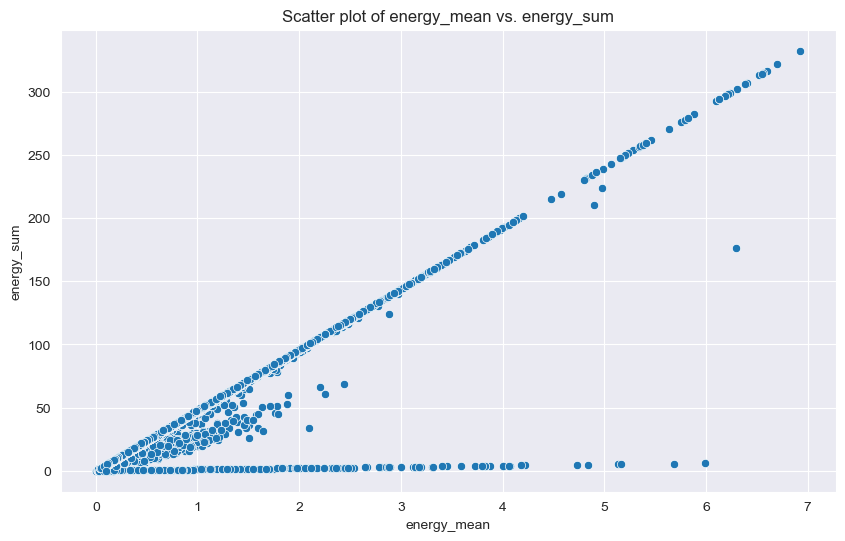

In [234]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_mean', 'energy_sum'))

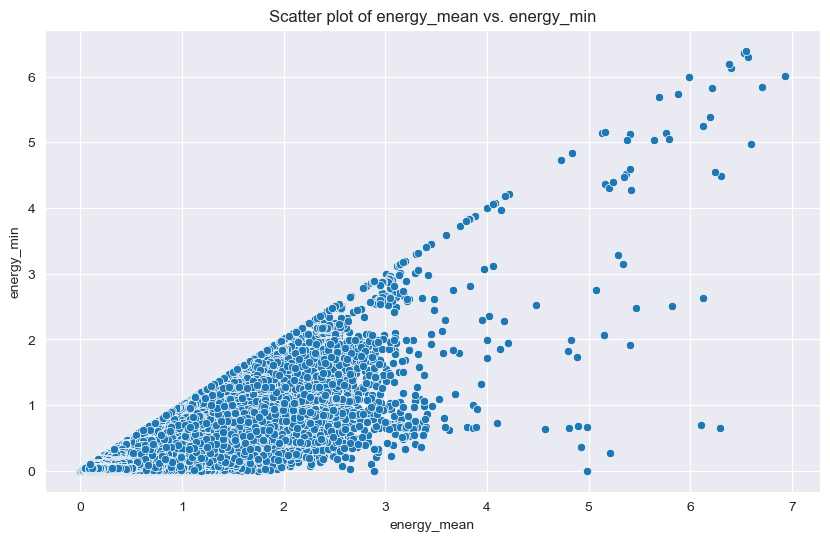

In [235]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_mean', 'energy_min'))

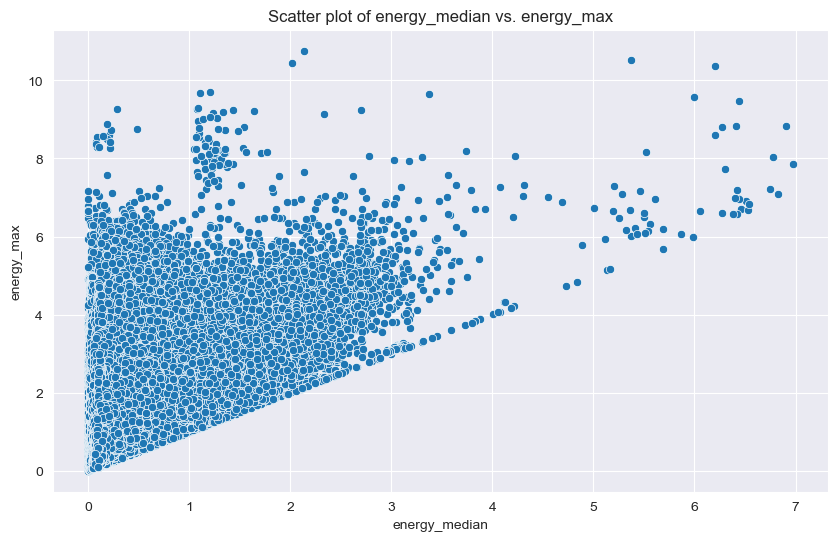

In [236]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_median', 'energy_max'))

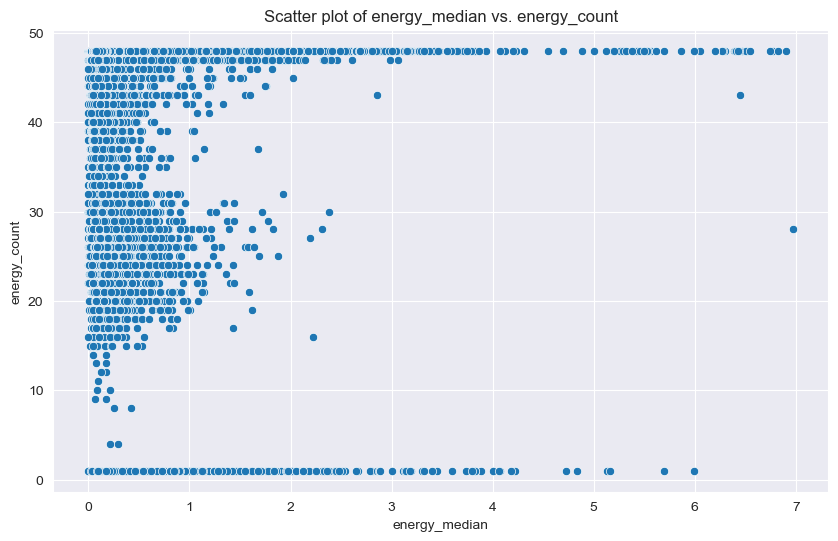

In [237]:
plot_level(1, lambda: plot_column_difference(filtered_daily_dataset, 'energy_median', 'energy_count'))

- From this scatter plot, it can be found that most of the data points are at the low end of the "energy_median" range, which indicates that most of the time, the median energy use is low. While in the top half of the picture, there is a large cluster of points where "energy_median" is low (near zero) and "energy_count" is high (at the top of the Y-axis), this section indicates many days with lower median energy use but higher readings.

In [49]:
def plot_yearly_energy_trend(df, stat_col='energy_mean'):
    plt.figure(figsize=(14, 8))

    # Get a list of years
    years = df['day'].dt.year.unique()
    for year in sorted(years):
        # Select the current year's data
        df_year = df[df['day'].dt.year == year]

        # Group by 'day' and calculate the average electricity consumption for each day.
        daily_avg = df_year.groupby('day')[stat_col].mean()

        # Re-indexing to ensure time-series plotting is possible
        daily_avg = daily_avg.reset_index()

        # Plotting average daily electricity consumption trends for the current year
        plt.plot(daily_avg['day'], daily_avg[stat_col], label=str(year))

    # Setup Legend
    plt.legend(title="Year")

    # Setting up title and axis labels
    plt.title(f'Yearly Trend of Daily Average {stat_col.capitalize()}')
    plt.xlabel('Day of Year')
    plt.ylabel(f'Average {stat_col.capitalize()}')

    # Display Grid
    plt.grid(True)

    # Display Graphics
    plt.show()

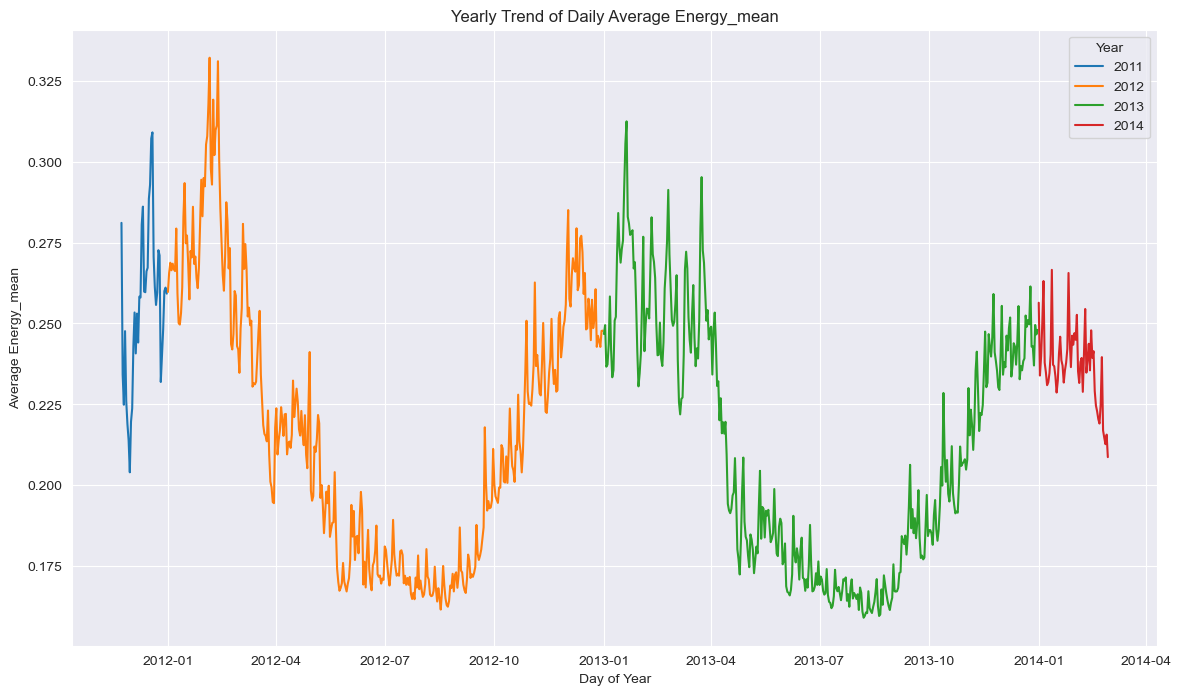

In [238]:
plot_level(1, lambda: plot_yearly_energy_trend(filtered_daily_dataset))

- The chart shows the annual trend of average daily energy consumption from November 2011 to February 2014, from which it can be found that energy use has a clear seasonal fluctuation trend, with average energy consumption low in summer and high in winter.

## halfhourly_dataset

In [51]:
halfhourly_block_0

,LCLid,tstp,energy(kWh/hh)
0,MAC000002,2012-10-12 00:30:00.0000000,0
1,MAC000002,2012-10-12 01:00:00.0000000,0
2,MAC000002,2012-10-12 01:30:00.0000000,0
3,MAC000002,2012-10-12 02:00:00.0000000,0
4,MAC000002,2012-10-12 02:30:00.0000000,0
...,...,...,...
1222665,MAC005492,2014-02-27 22:00:00.0000000,0.182
1222666,MAC005492,2014-02-27 22:30:00.0000000,0.122
1222667,MAC005492,2014-02-27 23:00:00.0000000,0.14
1222668,MAC005492,2014-02-27 23:30:00.0000000,0.192


In [52]:
display(halfhourly_block_0.nunique())

LCLid                50
tstp              39292
energy(kWh/hh)     5022
dtype: int64

In [53]:
halfhourly_block_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222670 entries, 0 to 1222669
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   LCLid           1222670 non-null  object
 1   tstp            1222670 non-null  object
 2   energy(kWh/hh)  1222670 non-null  object
dtypes: object(3)
memory usage: 28.0+ MB


## hhblock_dataset

For the hhblock_dataset, the structure information for one of the blocks was validated, and then all dataframes were merged into hhBLOCK_BIG_dataframes, which were then converted to date and time, checked for missing values, and visualized.

### Data Viewing and Cleaning

In [54]:
hhblock_0.head(1000)

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000246,2013-04-15,0.702,0.764,0.356,0.041,0.055,0.050,0.039,0.093,...,0.698,2.153,2.850,1.241,1.039,1.209,0.860,0.457,0.802,0.742
996,MAC000246,2013-04-16,0.640,0.095,0.748,0.693,0.302,0.024,0.029,0.072,...,0.820,2.551,2.907,2.186,2.239,1.239,1.003,0.685,0.887,0.550
997,MAC000246,2013-04-17,0.600,0.776,0.453,0.064,0.057,0.045,0.058,0.024,...,0.834,0.364,1.113,1.081,0.353,0.731,0.836,0.701,0.233,0.171
998,MAC000246,2013-04-18,0.134,0.120,0.277,0.235,0.148,0.749,0.504,0.073,...,0.121,1.189,1.935,2.145,1.430,1.486,1.099,0.960,0.761,0.215


In [55]:
hhblock_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25286 entries, 0 to 25285
Data columns (total 50 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   LCLid   25286 non-null  object 
 1   day     25286 non-null  object 
 2   hh_0    25286 non-null  float64
 3   hh_1    25286 non-null  float64
 4   hh_2    25286 non-null  float64
 5   hh_3    25286 non-null  float64
 6   hh_4    25286 non-null  float64
 7   hh_5    25286 non-null  float64
 8   hh_6    25286 non-null  float64
 9   hh_7    25286 non-null  float64
 10  hh_8    25286 non-null  float64
 11  hh_9    25286 non-null  float64
 12  hh_10   25286 non-null  float64
 13  hh_11   25286 non-null  float64
 14  hh_12   25286 non-null  float64
 15  hh_13   25286 non-null  float64
 16  hh_14   25286 non-null  float64
 17  hh_15   25286 non-null  float64
 18  hh_16   25286 non-null  float64
 19  hh_17   25286 non-null  float64
 20  hh_18   25286 non-null  float64
 21  hh_19   25286 non-null  float64
 22

In [56]:
# View information about the merged DataFrame
hhblock_big_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3469352 entries, 0 to 3469351
Data columns (total 50 columns):
 #   Column  Dtype  
---  ------  -----  
 0   LCLid   object 
 1   day     object 
 2   hh_0    float64
 3   hh_1    float64
 4   hh_2    float64
 5   hh_3    float64
 6   hh_4    float64
 7   hh_5    float64
 8   hh_6    float64
 9   hh_7    float64
 10  hh_8    float64
 11  hh_9    float64
 12  hh_10   float64
 13  hh_11   float64
 14  hh_12   float64
 15  hh_13   float64
 16  hh_14   float64
 17  hh_15   float64
 18  hh_16   float64
 19  hh_17   float64
 20  hh_18   float64
 21  hh_19   float64
 22  hh_20   float64
 23  hh_21   float64
 24  hh_22   float64
 25  hh_23   float64
 26  hh_24   float64
 27  hh_25   float64
 28  hh_26   float64
 29  hh_27   float64
 30  hh_28   float64
 31  hh_29   float64
 32  hh_30   float64
 33  hh_31   float64
 34  hh_32   float64
 35  hh_33   float64
 36  hh_34   float64
 37  hh_35   float64
 38  hh_36   float64
 39  hh_37   float64
 40  

In [57]:
hhblock_big_dataframe.head(1000)

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000246,2013-04-15,0.702,0.764,0.356,0.041,0.055,0.050,0.039,0.093,...,0.698,2.153,2.850,1.241,1.039,1.209,0.860,0.457,0.802,0.742
996,MAC000246,2013-04-16,0.640,0.095,0.748,0.693,0.302,0.024,0.029,0.072,...,0.820,2.551,2.907,2.186,2.239,1.239,1.003,0.685,0.887,0.550
997,MAC000246,2013-04-17,0.600,0.776,0.453,0.064,0.057,0.045,0.058,0.024,...,0.834,0.364,1.113,1.081,0.353,0.731,0.836,0.701,0.233,0.171
998,MAC000246,2013-04-18,0.134,0.120,0.277,0.235,0.148,0.749,0.504,0.073,...,0.121,1.189,1.935,2.145,1.430,1.486,1.099,0.960,0.761,0.215


In [58]:
def process_hhblock_dataset(df):
    # Convert 'day' column to datetime format
    df['day'] = pd.to_datetime(df['day'])

    # Convert 'LCLid' column to categorical data type
    df['LCLid'] = df['LCLid'].astype('category')
    
    # Cleaning out data without Acorn information
    df = df[df['LCLid'].isin(valid_lclid)]

    return df

In [59]:
filtered_big_hhblock = process_hhblock_dataset(hhblock_big_dataframe)
filtered_big_hhblock.head(1000)

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000246,2013-04-15,0.702,0.764,0.356,0.041,0.055,0.050,0.039,0.093,...,0.698,2.153,2.850,1.241,1.039,1.209,0.860,0.457,0.802,0.742
996,MAC000246,2013-04-16,0.640,0.095,0.748,0.693,0.302,0.024,0.029,0.072,...,0.820,2.551,2.907,2.186,2.239,1.239,1.003,0.685,0.887,0.550
997,MAC000246,2013-04-17,0.600,0.776,0.453,0.064,0.057,0.045,0.058,0.024,...,0.834,0.364,1.113,1.081,0.353,0.731,0.836,0.701,0.233,0.171
998,MAC000246,2013-04-18,0.134,0.120,0.277,0.235,0.148,0.749,0.504,0.073,...,0.121,1.189,1.935,2.145,1.430,1.486,1.099,0.960,0.761,0.215


In [60]:
filtered_big_hhblock.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3439414 entries, 0 to 3469351
Data columns (total 50 columns):
 #   Column  Dtype         
---  ------  -----         
 0   LCLid   category      
 1   day     datetime64[ns]
 2   hh_0    float64       
 3   hh_1    float64       
 4   hh_2    float64       
 5   hh_3    float64       
 6   hh_4    float64       
 7   hh_5    float64       
 8   hh_6    float64       
 9   hh_7    float64       
 10  hh_8    float64       
 11  hh_9    float64       
 12  hh_10   float64       
 13  hh_11   float64       
 14  hh_12   float64       
 15  hh_13   float64       
 16  hh_14   float64       
 17  hh_15   float64       
 18  hh_16   float64       
 19  hh_17   float64       
 20  hh_18   float64       
 21  hh_19   float64       
 22  hh_20   float64       
 23  hh_21   float64       
 24  hh_22   float64       
 25  hh_23   float64       
 26  hh_24   float64       
 27  hh_25   float64       
 28  hh_26   float64       
 29  hh_27   float64    

### Missing value handling

In [61]:
missing_filtered_big_hhblock_values = filtered_big_hhblock.isnull().sum()
missing_filtered_big_hhblock_values

LCLid       0
day         0
hh_0        0
hh_1        0
hh_2        0
hh_3        0
hh_4        0
hh_5        0
hh_6        0
hh_7        0
hh_8        0
hh_9        0
hh_10       0
hh_11       0
hh_12       0
hh_13       0
hh_14       0
hh_15       0
hh_16       0
hh_17       0
hh_18       0
hh_19       2
hh_20       0
hh_21       0
hh_22       0
hh_23       0
hh_24       0
hh_25      21
hh_26       1
hh_27       0
hh_28       0
hh_29       0
hh_30    5410
hh_31       0
hh_32       0
hh_33       0
hh_34       0
hh_35       0
hh_36       1
hh_37       0
hh_38       0
hh_39       0
hh_40       0
hh_41       0
hh_42       0
hh_43       0
hh_44       0
hh_45       0
hh_46       0
hh_47       0
dtype: int64

In [62]:
@ memory.cache
def data_for_hhblock_plot():
    # Select all numeric columns for group aggregation
    df_numeric = filtered_big_hhblock.iloc[:, 2:]  # Select all columns from the third to the last
    
    # Means by year grouping
    df_yearly_mean = df_numeric.groupby(filtered_big_hhblock['day'].dt.to_period('Y')).mean()
    
    # Grouping by quarter to find the mean
    df_quarterly_mean = df_numeric.groupby(filtered_big_hhblock['day'].dt.to_period('Q')).mean()
    
    # Grouping by quarter to find the mean
    df_monthly_mean = df_numeric.groupby(filtered_big_hhblock['day'].dt.to_period('M')).mean()

    # Get a string representation of the quarter and month, regardless of the year.
    # For example, convert "2011Q4" to "Q4" and 2012-05 to "M5".
    quarter_str = filtered_big_hhblock['day'].dt.to_period('Q').astype(str).str[-2:]
    month_str = filtered_big_hhblock['day'].dt.month.apply(lambda x: f"M{x}")
    
    # Grouping by quarter to find the mean, here using the converted quarterly string
    df_year_quarterly_mean = df_numeric.groupby(quarter_str).mean()
    
    # Group by month to find the mean, here use the converted month string
    df_year_monthly_mean = df_numeric.groupby(month_str).mean()
    
    # Find the mean by grouping by day of the week
    df_dayofweek_mean = df_numeric.groupby(filtered_big_hhblock['day'].dt.dayofweek).mean()
    
    return df_yearly_mean, df_quarterly_mean, df_monthly_mean, df_year_quarterly_mean, df_year_monthly_mean, df_dayofweek_mean

In [63]:
df_yearly_mean, df_quarterly_mean, df_monthly_mean, df_year_quarterly_mean, df_year_monthly_mean, df_dayofweek_mean = data_for_hhblock_plot()

In [64]:
df_yearly_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
day,,,,,,,,,,,,,,,,,,,,,
2011,0.226201,0.24568,0.221275,0.195596,0.175225,0.162091,0.154699,0.144014,0.133944,0.133677,...,0.383679,0.379936,0.369906,0.355203,0.347197,0.335236,0.324993,0.304083,0.279174,0.253856
2012,0.159381,0.16862,0.151961,0.137585,0.126645,0.119919,0.115118,0.112078,0.111088,0.113655,...,0.310947,0.310509,0.306104,0.300896,0.291368,0.279294,0.257216,0.232182,0.204753,0.178719
2013,0.184745,0.16436,0.147354,0.134487,0.125518,0.120020,0.115712,0.113359,0.112772,0.115713,...,0.317786,0.317877,0.313502,0.308174,0.298632,0.286424,0.265282,0.241039,0.213262,0.186334
2014,0.226068,0.20113,0.177073,0.158040,0.143906,0.135155,0.129038,0.124343,0.120784,0.120477,...,0.381394,0.379103,0.367036,0.354726,0.341916,0.327858,0.308835,0.289947,0.259638,0.225511


In [65]:
df_quarterly_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
day,,,,,,,,,,,,,,,,,,,,,
2011Q4,0.226201,0.245680,0.221275,0.195596,0.175225,0.162091,0.154699,0.144014,0.133944,0.133677,...,0.383679,0.379936,0.369906,0.355203,0.347197,0.335236,0.324993,0.304083,0.279174,0.253856
2012Q1,0.209771,0.310967,0.277628,0.245669,0.216038,0.195507,0.181364,0.167980,0.157781,0.153169,...,0.386493,0.390015,0.380736,0.371728,0.357558,0.343285,0.322938,0.300625,0.268069,0.232011
2012Q2,0.137277,0.157365,0.142929,0.128968,0.118306,0.112503,0.108702,0.106239,0.106892,0.111569,...,0.260276,0.263451,0.266395,0.267539,0.264199,0.255828,0.231871,0.203206,0.175490,0.152413
2012Q3,0.130201,0.130736,0.119133,0.109516,0.103800,0.100794,0.098181,0.096950,0.097384,0.100871,...,0.252736,0.256613,0.256824,0.255322,0.247685,0.236615,0.214782,0.189460,0.165254,0.144934
2012Q4,0.189138,0.188218,0.168269,0.151895,0.138766,0.130182,0.124224,0.120703,0.118882,0.120549,...,0.376950,0.370414,0.358954,0.347841,0.334183,0.319673,0.298091,0.274766,0.245359,0.214207
2013Q1,0.244006,0.215267,0.191614,0.172602,0.158003,0.148439,0.141510,0.136939,0.134069,0.133747,...,0.407327,0.405880,0.394920,0.383283,0.371070,0.356727,0.337140,0.315500,0.282706,0.246222
2013Q2,0.153557,0.138017,0.125485,0.116116,0.110448,0.107476,0.104906,0.104176,0.105139,0.110761,...,0.264239,0.269302,0.272621,0.274390,0.267965,0.256550,0.231813,0.202638,0.175267,0.152055
2013Q3,0.140656,0.126481,0.115432,0.108487,0.104327,0.101624,0.099019,0.097829,0.098796,0.103469,...,0.243198,0.246473,0.247669,0.247277,0.240764,0.231540,0.210414,0.186189,0.162811,0.143303
2013Q4,0.200443,0.177387,0.156583,0.140434,0.128990,0.122256,0.117135,0.114223,0.112818,0.114616,...,0.356271,0.349581,0.338420,0.327281,0.314202,0.300340,0.281276,0.259391,0.231907,0.203483


In [66]:
df_monthly_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
day,,,,,,,,,,,,,,,,,,,,,
2011-11,0.199826,0.226474,0.211819,0.196941,0.193441,0.172685,0.155222,0.144552,0.127522,0.125133,...,0.316441,0.330333,0.317011,0.310348,0.302056,0.295026,0.294744,0.282011,0.256685,0.232770
2011-12,0.227123,0.246352,0.221606,0.195549,0.174588,0.161720,0.154681,0.143995,0.134168,0.133976,...,0.386030,0.381670,0.371755,0.356771,0.348776,0.336642,0.326051,0.304855,0.279961,0.254593
2012-01,0.223491,0.289421,0.257377,0.229763,0.203643,0.184150,0.174570,0.160749,0.151930,0.147932,...,0.420052,0.415183,0.401288,0.391381,0.375023,0.359044,0.339462,0.318275,0.285698,0.254078
2012-02,0.232255,0.349428,0.313940,0.281096,0.251662,0.228801,0.214398,0.199987,0.184847,0.177134,...,0.417492,0.417689,0.409205,0.401762,0.388464,0.373001,0.351558,0.328357,0.296102,0.254422
2012-03,0.188977,0.295700,0.263174,0.229830,0.198486,0.179001,0.162970,0.150449,0.142837,0.139963,...,0.351219,0.360685,0.352973,0.343354,0.329605,0.316874,0.296893,0.274650,0.241907,0.207499
2012-04,0.152400,0.217229,0.197744,0.175748,0.156256,0.142692,0.134073,0.128980,0.127899,0.132474,...,0.307767,0.318279,0.320971,0.311462,0.296848,0.282221,0.252988,0.219906,0.188952,0.164874
2012-05,0.134830,0.154574,0.140291,0.126945,0.116503,0.110832,0.107758,0.105116,0.105975,0.111560,...,0.254587,0.257347,0.262779,0.268836,0.265439,0.255529,0.230154,0.200542,0.172461,0.149573
2012-06,0.132968,0.135052,0.122561,0.111412,0.104188,0.101452,0.099064,0.097811,0.099015,0.103042,...,0.245224,0.245720,0.246870,0.248621,0.249927,0.245282,0.224558,0.198418,0.172302,0.149490
2012-07,0.131606,0.130598,0.118536,0.109373,0.104069,0.100448,0.097798,0.096398,0.097152,0.100576,...,0.234815,0.236610,0.239133,0.245179,0.245399,0.238080,0.217509,0.192570,0.167802,0.146468


In [67]:
df_year_quarterly_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
day,,,,,,,,,,,,,,,,,,,,,
Q1,0.235165,0.217951,0.193398,0.173360,0.157738,0.147590,0.140371,0.135064,0.131382,0.130727,...,0.396800,0.395455,0.384248,0.372587,0.360016,0.345776,0.326322,0.305572,0.273648,0.238006
Q2,0.148033,0.144582,0.131403,0.120476,0.113115,0.109181,0.106194,0.104876,0.105734,0.111035,...,0.262895,0.267317,0.270509,0.272066,0.266687,0.256305,0.231832,0.202831,0.175343,0.152176
Q3,0.135707,0.128495,0.117184,0.108974,0.104078,0.101231,0.098623,0.097413,0.098128,0.102239,...,0.247713,0.251273,0.252002,0.251085,0.244040,0.233942,0.212482,0.187738,0.163967,0.144075
Q4,0.194900,0.183465,0.163067,0.146724,0.134349,0.126620,0.121055,0.117768,0.116080,0.117794,...,0.367025,0.360438,0.349134,0.337979,0.324647,0.310471,0.290198,0.267588,0.239146,0.209359


In [68]:
df_year_monthly_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
day,,,,,,,,,,,,,,,,,,,,,
M1,0.237189,0.213976,0.189298,0.169251,0.154328,0.144411,0.137603,0.132314,0.128726,0.127993,...,0.402798,0.399526,0.387023,0.375134,0.362133,0.347177,0.327825,0.307900,0.275760,0.239747
M10,0.147806,0.143043,0.129777,0.119244,0.111496,0.106990,0.104197,0.103379,0.104203,0.109397,...,0.332048,0.322271,0.310346,0.298499,0.282741,0.266386,0.240255,0.211959,0.183747,0.159438
M11,0.205350,0.193436,0.170217,0.152056,0.138186,0.129542,0.123537,0.119385,0.116812,0.117402,...,0.378352,0.374059,0.363058,0.352066,0.339470,0.325900,0.307865,0.287524,0.258334,0.225242
M12,0.230379,0.212962,0.188373,0.168158,0.152744,0.142778,0.134956,0.130114,0.126845,0.126274,...,0.389970,0.384273,0.373278,0.362636,0.350942,0.338291,0.321535,0.302247,0.274299,0.242378
M2,0.233749,0.216688,0.192232,0.172659,0.157256,0.147310,0.140330,0.135290,0.131544,0.131055,...,0.395093,0.393565,0.382803,0.370851,0.358068,0.344152,0.324493,0.303561,0.272260,0.236685
M3,0.233903,0.226678,0.202186,0.181445,0.164294,0.153439,0.145153,0.139403,0.135658,0.134878,...,0.389219,0.391439,0.381753,0.370930,0.359420,0.345897,0.326587,0.304715,0.272197,0.237083
M4,0.167618,0.169459,0.155181,0.142036,0.131871,0.125439,0.121091,0.119176,0.118981,0.124338,...,0.302997,0.314523,0.317412,0.310667,0.296189,0.279501,0.251026,0.218938,0.188960,0.163826
M5,0.143250,0.140137,0.126910,0.116299,0.109459,0.105811,0.103411,0.102149,0.103429,0.109290,...,0.256222,0.259179,0.264506,0.269496,0.264071,0.252364,0.227619,0.198866,0.171242,0.148405
M6,0.137621,0.129853,0.117551,0.108011,0.102290,0.099985,0.097486,0.096567,0.097832,0.102578,...,0.238697,0.239093,0.240546,0.245221,0.246771,0.242384,0.221191,0.194296,0.168817,0.146837


In [69]:
df_dayofweek_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
day,,,,,,,,,,,,,,,,,,,,,
0,0.175689,0.165756,0.148915,0.135408,0.125732,0.119690,0.115129,0.112522,0.111899,0.114931,...,0.328055,0.328702,0.325068,0.318206,0.308557,0.294844,0.270457,0.243551,0.212463,0.183091
1,0.174443,0.164973,0.148070,0.135002,0.125382,0.119641,0.115421,0.112848,0.112525,0.115719,...,0.323757,0.325141,0.319816,0.315689,0.305162,0.292160,0.268636,0.242715,0.212326,0.183450
2,0.175248,0.165085,0.148343,0.135188,0.125460,0.119637,0.115592,0.113150,0.112579,0.115691,...,0.320613,0.322116,0.318184,0.313606,0.303705,0.290953,0.268544,0.243409,0.213778,0.185286
3,0.176654,0.166573,0.149173,0.135665,0.125957,0.120320,0.115982,0.113386,0.112765,0.116054,...,0.317018,0.318254,0.314734,0.310774,0.301600,0.289201,0.267418,0.243101,0.214596,0.186872
4,0.178309,0.167695,0.149891,0.136132,0.126346,0.120517,0.116123,0.113633,0.112878,0.116311,...,0.313438,0.311456,0.306077,0.299135,0.290217,0.279377,0.260936,0.239813,0.215558,0.191198
5,0.184965,0.174826,0.156625,0.141648,0.130883,0.124014,0.118795,0.115613,0.113955,0.114982,...,0.312575,0.308813,0.302039,0.294194,0.285438,0.274266,0.258864,0.239746,0.217597,0.194776
6,0.189022,0.179145,0.160622,0.144918,0.133259,0.125604,0.119877,0.116062,0.113600,0.114207,...,0.330060,0.328870,0.322138,0.315209,0.303493,0.291185,0.268226,0.242262,0.213309,0.184548


In [70]:
def plot_with_seasonal_colors(df, title_suffix):
    plt.figure(figsize=(14, 8))

    # Define season or month colour mapping
    # Extract all unique seasons/months directly by string slicing
    unique_seasons = sorted({str(index)[-2:] for index in df.index})
    season_colors = plt.cm.viridis(np.linspace(0, 1, len(unique_seasons)))
    color_map = dict(zip(unique_seasons, season_colors))

    # x-axis labels
    x_labels = [f'{i // 2:02d}:{i % 2 * 30:02d}' for i in range(48)]

    # Iterate through each row of the DataFrame
    for index, row in df.iterrows():
        year, season = str(index)[:-2], str(index)[-2:]
        # Ensure that all values in row.values are of a plottable numeric type
        values = [float(value) for value in row.values if isinstance(value, (int, float))]

        # Select colours for rows in this season/month
        color = color_map[season]

        # Plotting average electricity consumption per half hour
        plt.plot(x_labels, values, marker='o', linestyle='-', label=f'{year} {season}', color=color)

    # Plotting average electricity consumption per half hour
    plt.legend(title="Time Period", loc='upper right', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
    plt.title(f'Average Daily Electricity Consumption per 30 Minutes - {title_suffix}')
    plt.xlabel('Time of Day (in 30-minute intervals)')
    plt.ylabel('Average Electricity Consumption (kWh)')
    plt.xticks(range(0, 48, 3), labels=x_labels[::3])
    plt.grid(True)
    plt.tight_layout()
    plt.show()


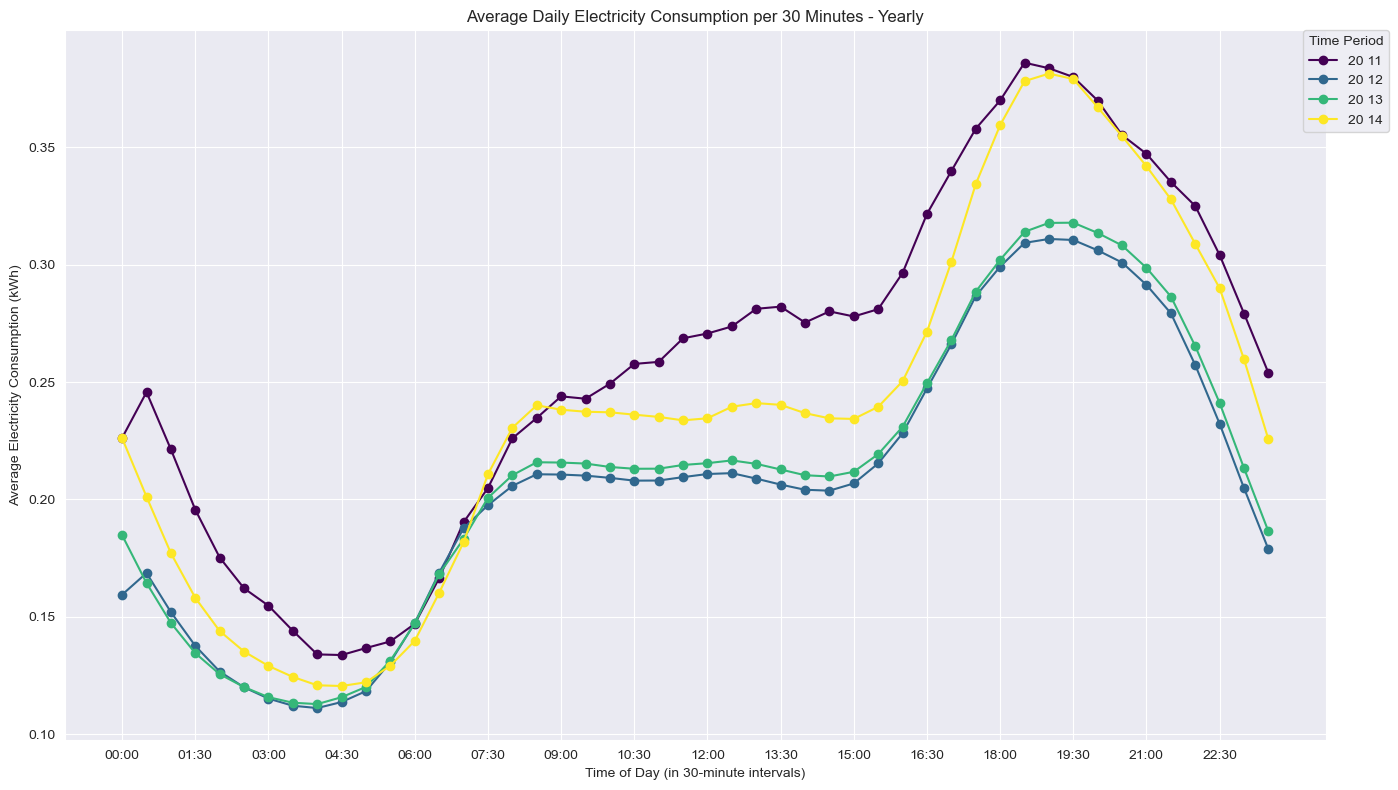

In [239]:
plot_level(1, lambda: plot_with_seasonal_colors(df_yearly_mean, 'Yearly'))

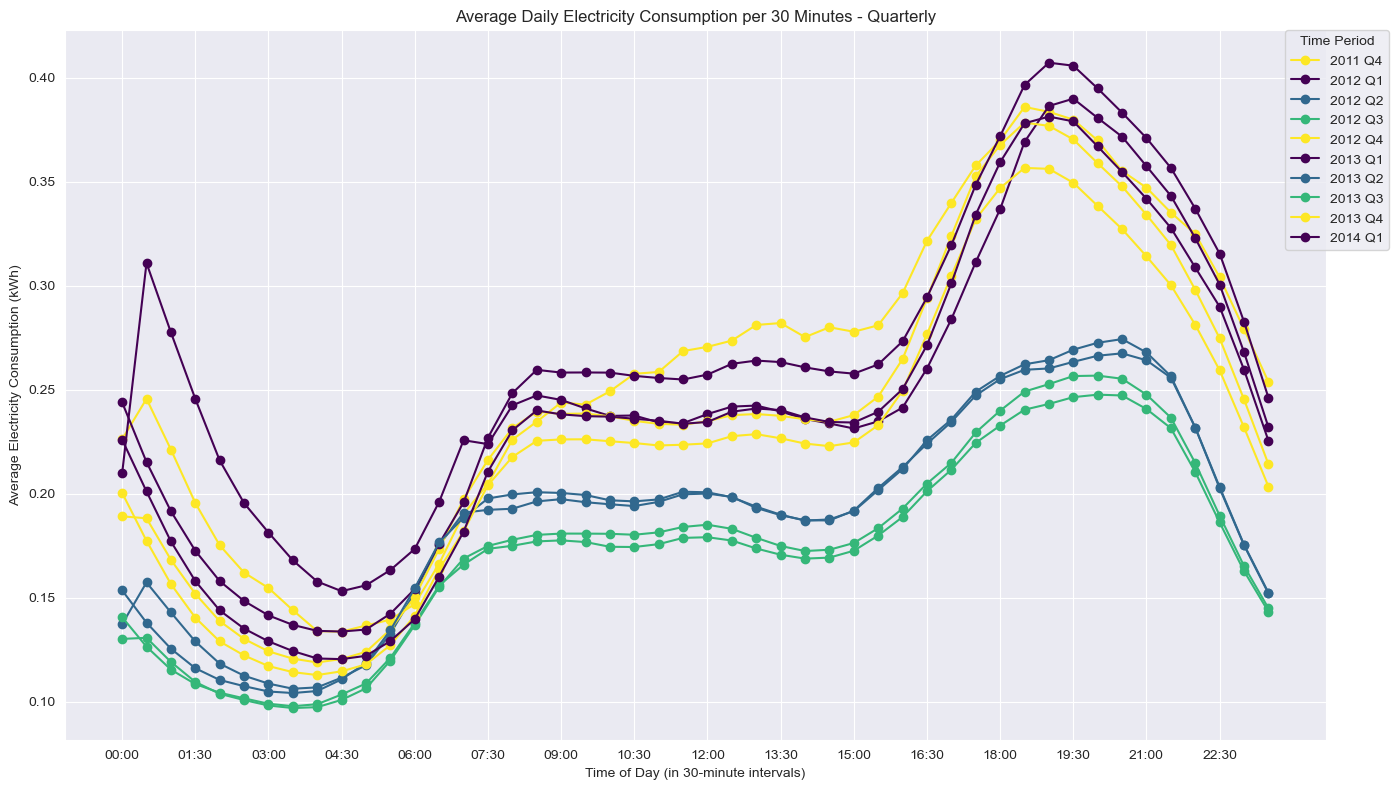

In [240]:
plot_level(1, lambda: plot_with_seasonal_colors(df_quarterly_mean, 'Quarterly'))

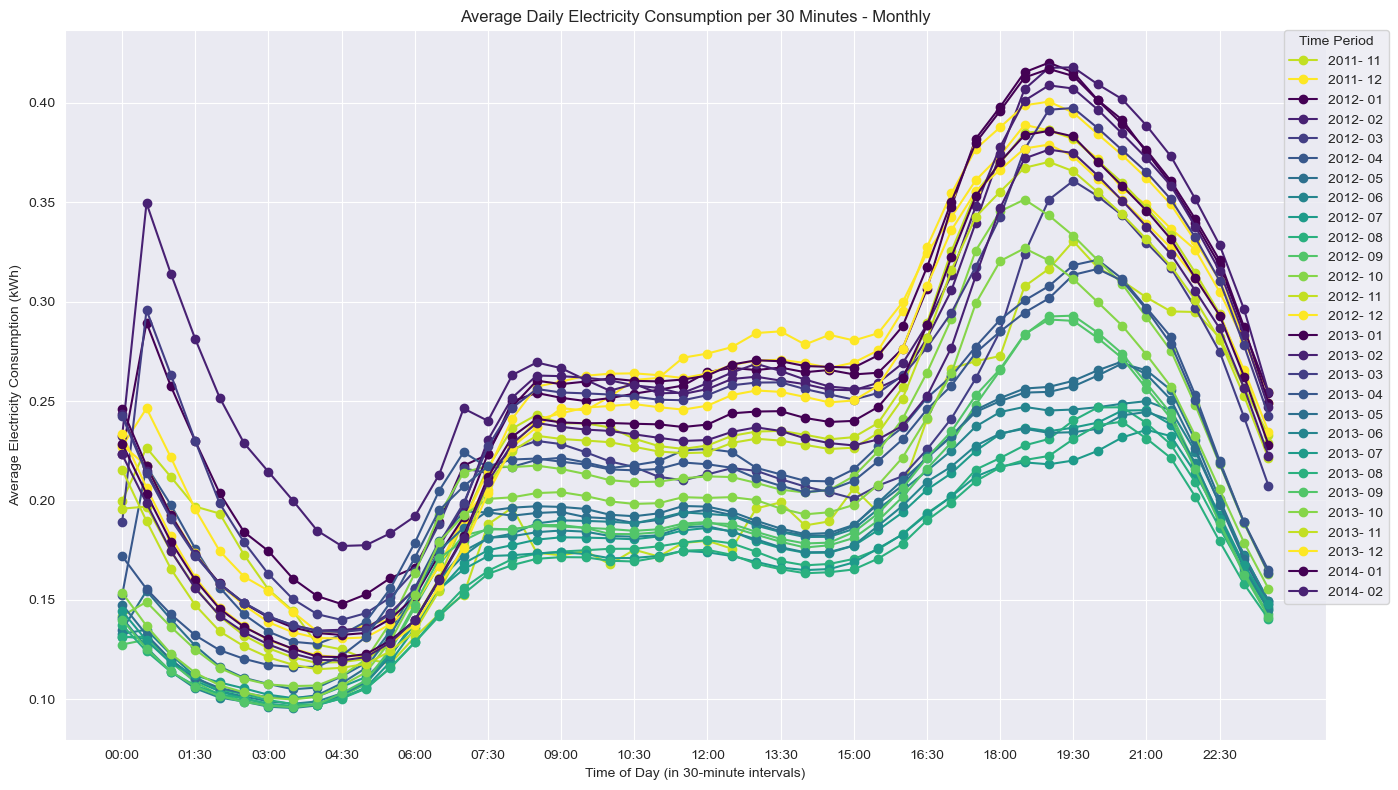

In [241]:
plot_level(1, lambda: plot_with_seasonal_colors(df_monthly_mean, 'Monthly'))

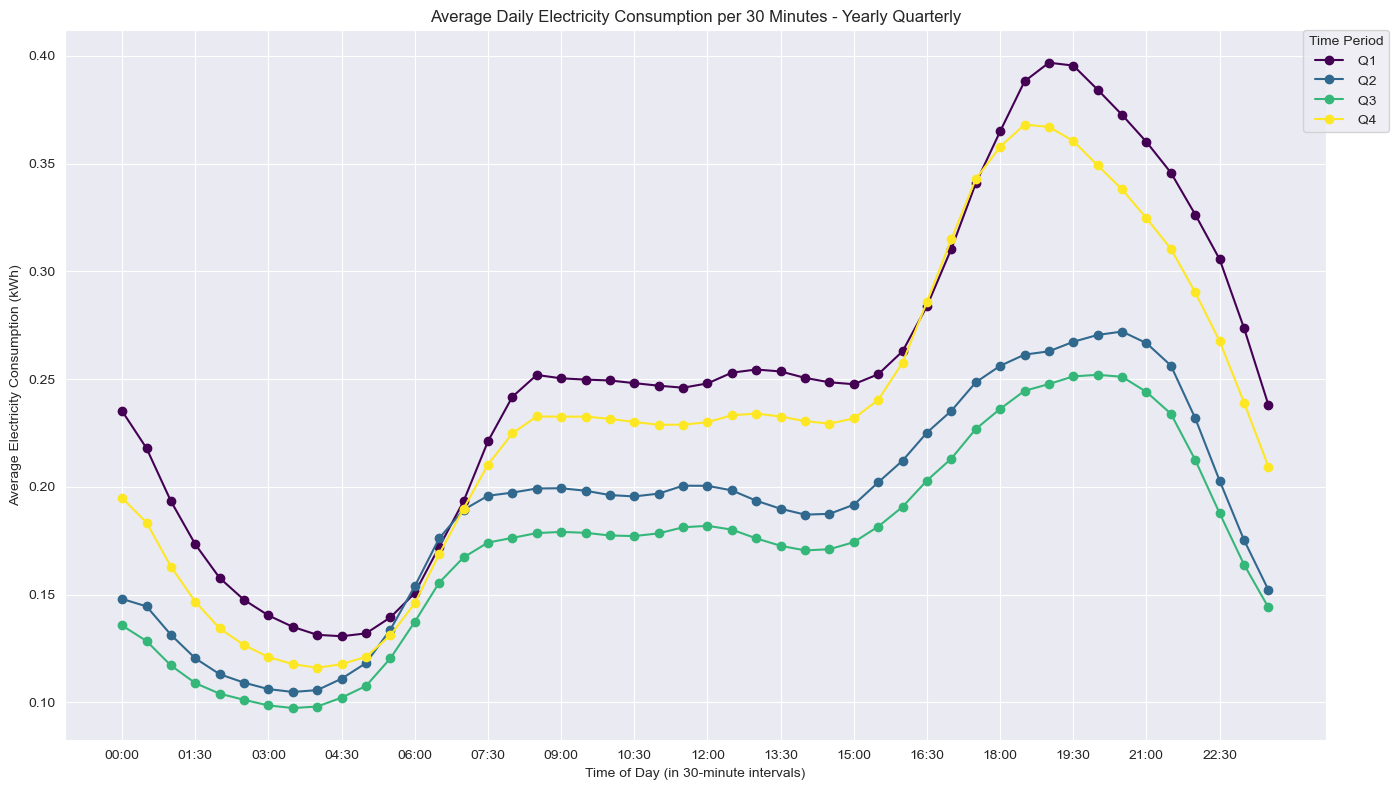

In [242]:
plot_level(1, lambda: plot_with_seasonal_colors(df_year_quarterly_mean, 'Yearly Quarterly'))

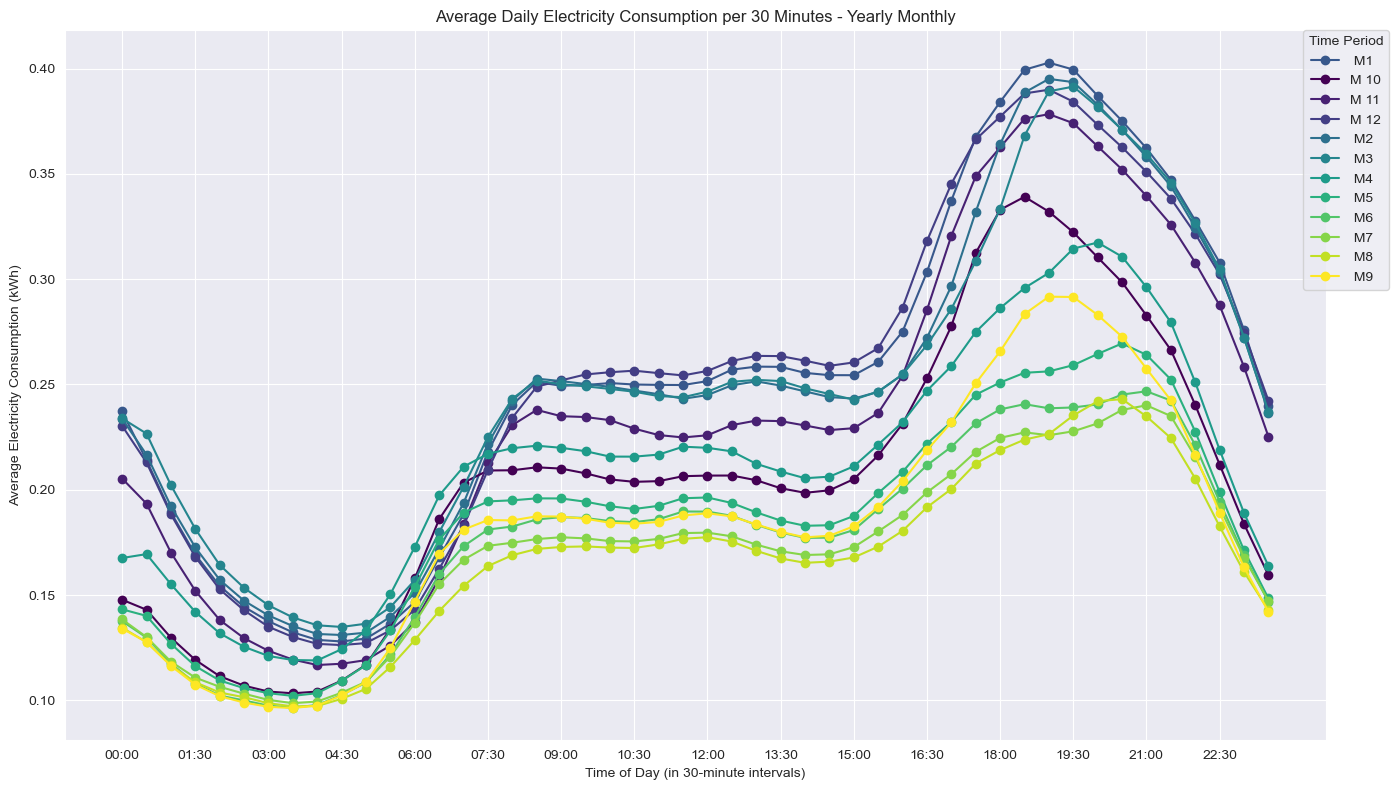

In [243]:
plot_level(1, lambda: plot_with_seasonal_colors(df_year_monthly_mean, 'Yearly Monthly'))

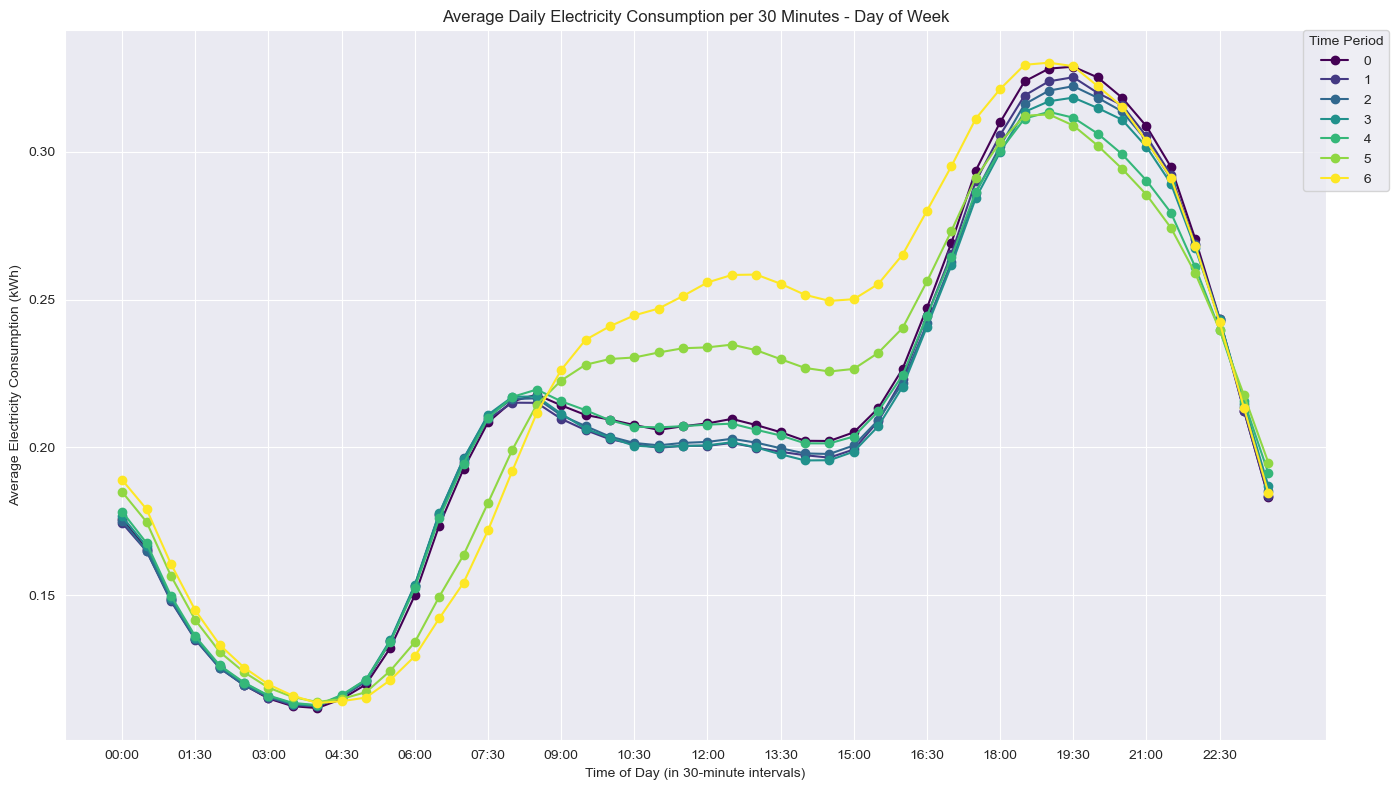

In [244]:
plot_level(1, lambda: plot_with_seasonal_colors(df_dayofweek_mean, 'Day of Week'))

- It can be seen from many line plots that draw the average power consumption for every 30 minutes in a day that the second half of the night is the time when energy use is the least, while energy consumption shows an upward trend from 04:30 to 07:30-09:00 in the morning, and then starts to rise in the near evening until it reaches a peak in the evening, and then gradually declines, and so on.

## uk_bank_holidays

### Data Viewing and Cleaning

In [77]:
uk_bank_holidays

,Bank holidays,Type
0,2012-12-26,Boxing Day
1,2012-12-25,Christmas Day
2,2012-08-27,Summer bank holiday
3,2012-05-06,Queen?s Diamond Jubilee (extra bank holiday)
4,2012-04-06,Spring bank holiday (substitute day)
5,2012-07-05,Early May bank holiday
6,2012-09-04,Easter Monday
7,2012-06-04,Good Friday
8,2012-02-01,New Year?s Day (substitute day)
9,2013-12-26,Boxing Day


In [78]:
def process_uk_bank_holidays(df_bank_holidays, df_hhblock):
    df_bank_holidays['Bank holidays'] = pd.to_datetime(df_bank_holidays['Bank holidays'])

    df_bank_holidays['Bank holidays'] = pd.to_datetime(df_bank_holidays['Bank holidays'])
    # Create a collection with all the holiday dates
    holidays_set = set(df_bank_holidays['Bank holidays'])

    # Use .copy() to ensure that filtered_big_hhblock is a separate copy to avoid subsequent modifications affecting the original data
    filtered_big_hhblock_copy = df_hhblock.copy()
    
    filtered_big_hhblock_copy.loc[:, 'is_holiday'] = filtered_big_hhblock_copy['day'].isin(holidays_set)
    
    df_numeric = filtered_big_hhblock_copy.iloc[:, 2:]  # Select the value column
    
    # Finding the mean by grouping according to the is_holiday columns
    df_holidays_mean = df_numeric.groupby(filtered_big_hhblock_copy['is_holiday']).mean()
    
    # Rename indexes to represent data more clearly
    df_holidays_mean.index = ['out_holidays', 'in_holidays']

    return df_holidays_mean

In [79]:
%%time
df_holidays_mean = process_uk_bank_holidays(uk_bank_holidays, filtered_big_hhblock)

CPU times: total: 125 ms
Wall time: 878 ms


In [80]:
def plot_average_daily_consumption(df, title_suffix):
    plt.figure(figsize=(14, 8))

    # Create a list of x-axis labels representing each half-hourly interval over a 24-hour period
    x_labels = [f'{i//2:02d}:{i%2*30:02d}' for i in range(48)]

    for index, row in df.iterrows():
        # Convert index to string for any form of Period or other index type
        index_str = str(index)

        values = [float(value) for value in row.values if isinstance(value, (int, float))]

        # Plotting average electricity consumption per half hour
        plt.plot(x_labels, values, marker='o', linestyle='-', label=index_str)

    plt.legend(title="Time Period", loc='upper right')
    plt.title(f'Average Daily Electricity Consumption per 30 Minutes - {title_suffix}')
    plt.xlabel('Time of Day (in 30-minute intervals)')
    plt.ylabel('Average Electricity Consumption (kWh)')
    plt.xticks(range(0, 48, 3), labels=x_labels[::3])
    plt.grid(True)
    plt.show()

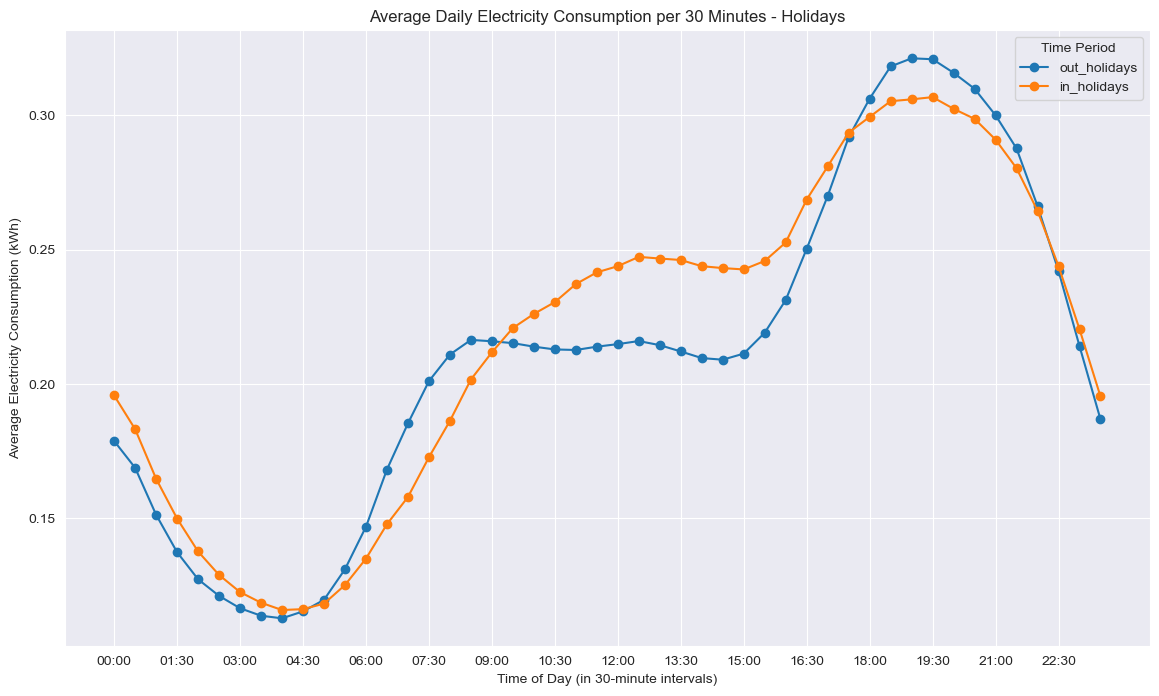

In [245]:
plot_level(1, lambda: plot_average_daily_consumption(df_holidays_mean.iloc[:, :-1], 'Holidays'))

- Comparing energy consumption on holidays with that on non-holidays, it can be found that the average start time of electricity consumption on holidays is slightly later than that on daily days, and daytime energy consumption is higher than daily electricity consumption, which may be caused by more people using electrical appliances at home during holidays (Kang and Reiner, 2022).

## Acorn Data Analysis and Visualisation

In [82]:
# Merge DataFrame
merged_info_hhblock_df = pd.merge(filtered_big_hhblock,
                                  informations_households_filtered[['LCLid', 'stdorToU', 'Acorn', 'Acorn_grouped']],
                                  on='LCLid', how='left')

In [83]:
merged_info_hhblock_df.head(1000)

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47,stdorToU,Acorn,Acorn_grouped
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.239,0.230,0.233,0.235,0.188,0.259,0.250,Std,ACORN-A,Affluent
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,0.745,0.712,0.511,0.231,0.210,0.278,0.159,Std,ACORN-A,Affluent
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,0.258,0.260,0.334,0.299,0.236,0.241,0.237,Std,ACORN-A,Affluent
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.228,0.203,0.211,0.188,0.213,0.157,0.202,Std,ACORN-A,Affluent
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.208,0.265,0.377,0.327,0.277,0.288,0.256,Std,ACORN-A,Affluent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000246,2013-04-15,0.702,0.764,0.356,0.041,0.055,0.050,0.039,0.093,...,1.241,1.039,1.209,0.860,0.457,0.802,0.742,Std,ACORN-A,Affluent
996,MAC000246,2013-04-16,0.640,0.095,0.748,0.693,0.302,0.024,0.029,0.072,...,2.186,2.239,1.239,1.003,0.685,0.887,0.550,Std,ACORN-A,Affluent
997,MAC000246,2013-04-17,0.600,0.776,0.453,0.064,0.057,0.045,0.058,0.024,...,1.081,0.353,0.731,0.836,0.701,0.233,0.171,Std,ACORN-A,Affluent
998,MAC000246,2013-04-18,0.134,0.120,0.277,0.235,0.148,0.749,0.504,0.073,...,2.145,1.430,1.486,1.099,0.960,0.761,0.215,Std,ACORN-A,Affluent


In [84]:
def data_for_acorn_plot(merged_info_hhblock_df):
    # Select all numeric columns for group aggregation
    df_numeric = merged_info_hhblock_df.iloc[:, 2:-3]
    
    # Grouping by 'stdorToU' to find means
    df_std_tou_mean = df_numeric.groupby(merged_info_hhblock_df['stdorToU']).mean()
    
    # Finding the mean by 'Acorn' grouping
    df_acorn_mean = df_numeric.groupby(merged_info_hhblock_df['Acorn']).mean()
    
    # Means by 'Acorn_grouped' grouping
    df_acorn_grouped_mean = df_numeric.groupby(merged_info_hhblock_df['Acorn_grouped']).mean()
    
    return df_std_tou_mean, df_acorn_mean, df_acorn_grouped_mean

In [85]:
%%time
df_std_tou_mean, df_acorn_mean, df_acorn_grouped_mean = data_for_acorn_plot(merged_info_hhblock_df)

CPU times: total: 359 ms
Wall time: 1.45 s


In [86]:
df_std_tou_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
stdorToU,,,,,,,,,,,,,,,,,,,,,
Std,0.185532,0.177643,0.159185,0.144048,0.132801,0.125803,0.120766,0.117434,0.116304,0.118851,...,0.323984,0.324053,0.319433,0.313533,0.303504,0.290602,0.268844,0.244293,0.216493,0.189280
ToU,0.153965,0.135380,0.121753,0.112506,0.106794,0.103628,0.100550,0.099791,0.099298,0.101755,...,0.308110,0.306311,0.299600,0.293750,0.284830,0.274854,0.255495,0.233325,0.205239,0.178074


In [87]:
df_acorn_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
Acorn,,,,,,,,,,,,,,,,,,,,,
ACORN-A,0.310594,0.275233,0.249999,0.233997,0.223660,0.217964,0.214212,0.212482,0.213791,0.217612,...,0.621023,0.618901,0.613864,0.607231,0.594865,0.567839,0.527554,0.475788,0.416736,0.359784
ACORN-B,0.176595,0.153550,0.135713,0.127037,0.122915,0.123745,0.123675,0.124608,0.124809,0.126982,...,0.406199,0.401831,0.385444,0.373999,0.367419,0.350518,0.324503,0.288066,0.247814,0.208473
ACORN-C,0.180511,0.156411,0.140311,0.129169,0.121903,0.117881,0.114905,0.114885,0.113887,0.117030,...,0.401863,0.393627,0.381439,0.373072,0.359463,0.343767,0.313998,0.284920,0.245768,0.210174
ACORN-D,0.215055,0.188244,0.168507,0.156437,0.147990,0.143163,0.139424,0.138753,0.138603,0.140139,...,0.457504,0.463231,0.458638,0.448370,0.433686,0.416672,0.384734,0.343719,0.299946,0.253789
ACORN-E,0.194509,0.188161,0.169465,0.153901,0.142367,0.135577,0.130344,0.125761,0.124095,0.126568,...,0.324501,0.327997,0.323897,0.317185,0.306325,0.293762,0.272571,0.248094,0.220153,0.191844
ACORN-F,0.156744,0.140010,0.128291,0.118938,0.111147,0.105000,0.100997,0.099255,0.098745,0.101192,...,0.286275,0.288135,0.285672,0.282226,0.274664,0.263536,0.246060,0.225132,0.202099,0.178210
ACORN-G,0.165387,0.150853,0.135291,0.125210,0.117683,0.112944,0.116979,0.116311,0.108730,0.115878,...,0.335059,0.325954,0.316183,0.308423,0.299972,0.286508,0.264702,0.242130,0.212200,0.184461
ACORN-H,0.171134,0.151252,0.135965,0.123986,0.117435,0.114038,0.110737,0.110551,0.111230,0.114085,...,0.366944,0.360537,0.352982,0.346635,0.335639,0.322592,0.295274,0.266071,0.230752,0.198722
ACORN-I,0.137267,0.121608,0.111217,0.104484,0.101162,0.099284,0.097319,0.097159,0.095106,0.096003,...,0.299042,0.296769,0.291644,0.289498,0.281951,0.269198,0.247433,0.219366,0.187023,0.159960


In [88]:
df_acorn_grouped_mean

,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
Acorn_grouped,,,,,,,,,,,,,,,,,,,,,
Adversity,0.155153,0.149892,0.134126,0.120670,0.110920,0.104401,0.098853,0.095930,0.095351,0.097542,...,0.263342,0.261277,0.256085,0.251144,0.242884,0.232900,0.215803,0.198104,0.177161,0.157519
Affluent,0.203860,0.191560,0.172465,0.157691,0.146995,0.140794,0.136055,0.132530,0.131325,0.133800,...,0.367639,0.370243,0.365378,0.358041,0.346439,0.332082,0.307599,0.278687,0.245735,0.212568
Comfortable,0.171179,0.158756,0.141604,0.128282,0.118529,0.112612,0.109210,0.107593,0.106387,0.109404,...,0.319896,0.317342,0.312220,0.307358,0.298380,0.286318,0.264808,0.240297,0.211733,0.184342


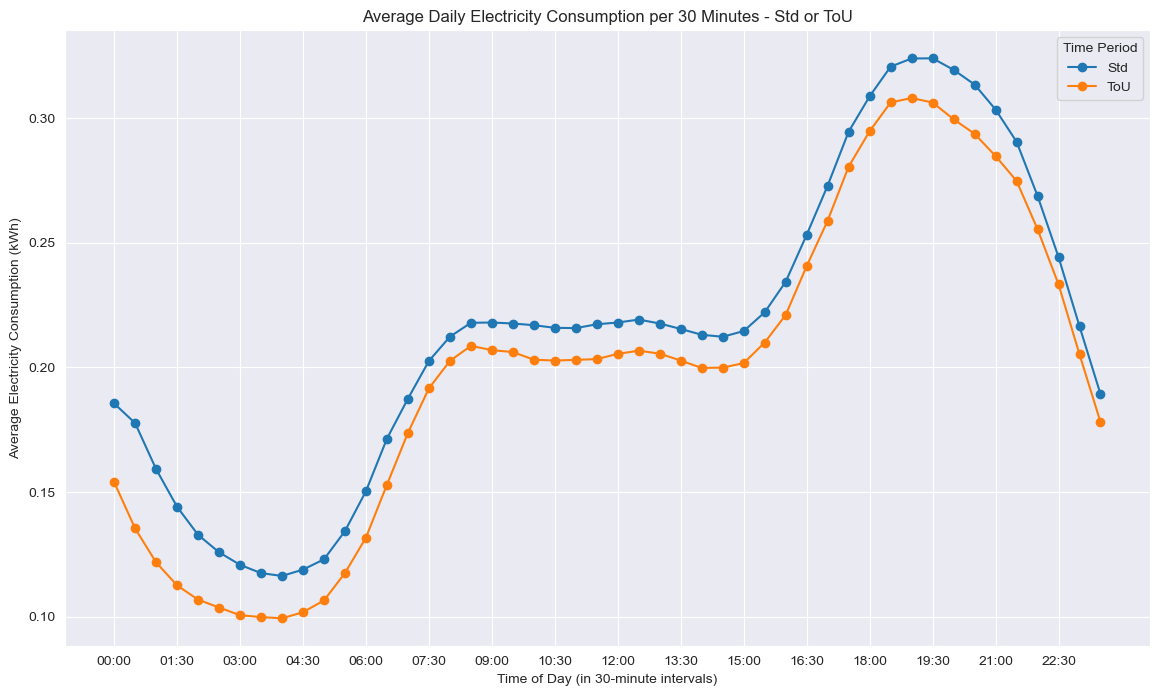

In [246]:
plot_level(1, lambda: plot_average_daily_consumption(df_std_tou_mean, 'Std or ToU'))

- Comparing the two billing methods, it is found that the energy consumption under Std billing is higher than that under ToU billing.

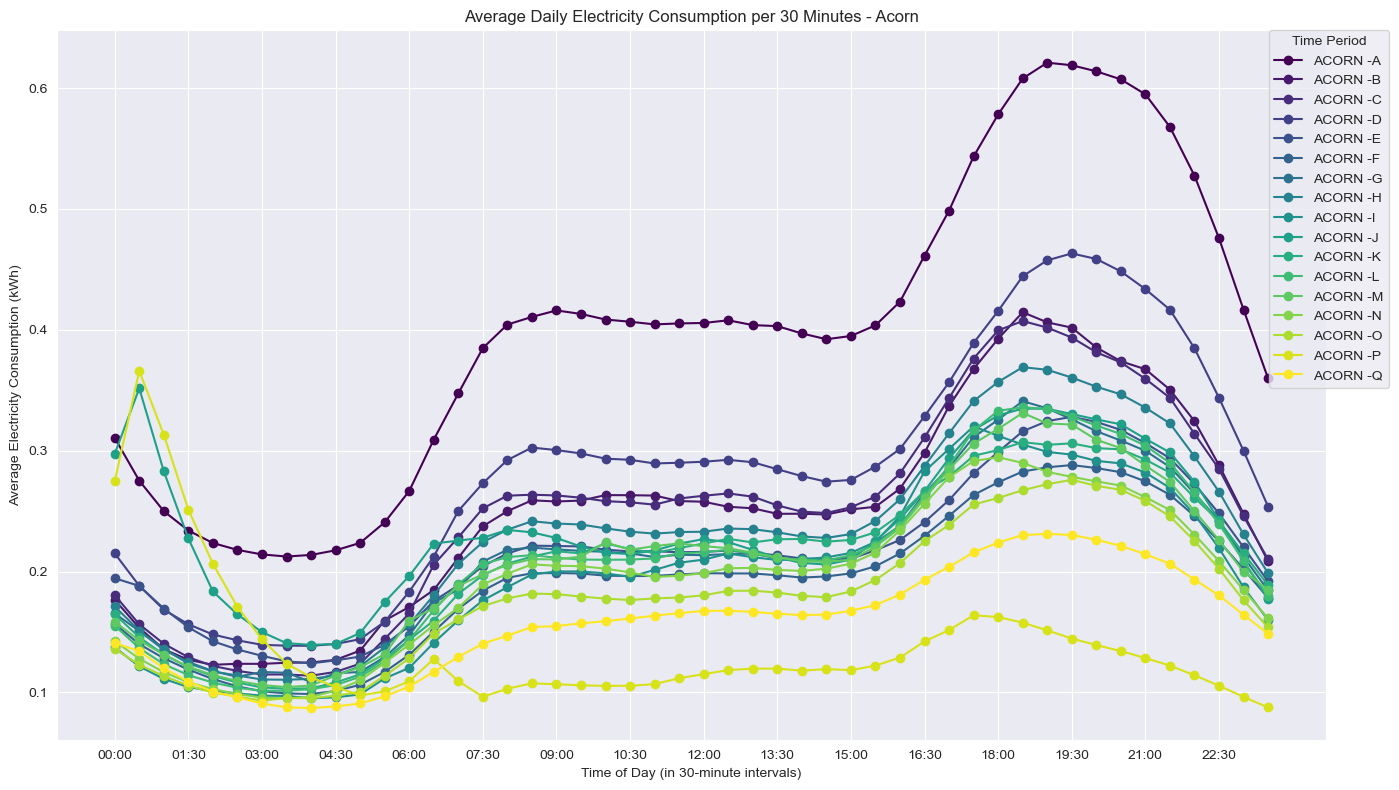

In [247]:
plot_level(1, lambda: plot_with_seasonal_colors(df_acorn_mean, 'Acorn'))

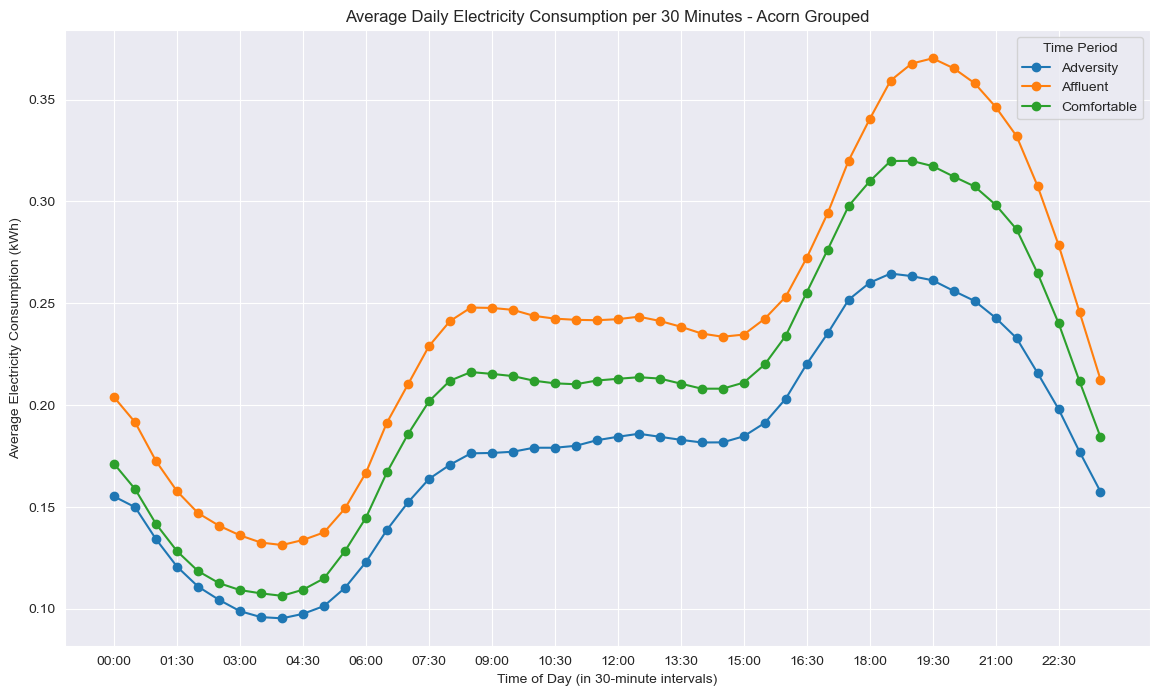

In [248]:
plot_level(1, lambda: plot_average_daily_consumption(df_acorn_grouped_mean, 'Acorn Grouped'))

- For households of different wealth levels, households labeled "affluent" tend to have higher energy consumption, while those labeled "adversity" tend to have lower energy consumption.

## 2.2 Weather Conditions

Energy consumption at the household level may vary from day to day due to working hours, holidays, weather conditions, etc. (Kiprijanovska et al., 2020), and different weather conditions may have different effects on household energy consumption. The weather data used in this study was collected by Jean-Michel (2018) using darksky api, including two dimensions: daily weather data and hourly weather data. The daily data mainly includes the maximum temperature of the day and its occurrence time, the maximum perceived temperature of the day, the time when the maximum perceived temperature occurred, wind speed, atmospheric pressure, etc., while the hourly data mainly includes visibility, wind direction, temperature, perceived temperature, and the specific time point of data collection.

In [92]:
weather_daily_darksky

,temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,windSpeed,pressure,apparentTemperatureMinTime,...,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase
0,11.96,2011-11-11 23:00:00,123,fog,9.40,2011-11-11 07:00:00,0.79,3.88,1016.08,2011-11-11 07:00:00,...,10.87,2011-11-11 07:12:14,2011-11-11 19:00:00,2011-11-11 11:00:00,Foggy until afternoon.,2011-11-11 19:00:00,6.48,2011-11-11 23:00:00,2011-11-11 19:00:00,0.52
1,8.59,2011-12-11 14:00:00,198,partly-cloudy-day,4.49,2011-12-11 01:00:00,0.56,3.94,1007.71,2011-12-11 02:00:00,...,8.59,2011-12-11 07:57:02,2011-12-11 14:00:00,2011-12-11 12:00:00,Partly cloudy throughout the day.,2011-12-12 07:00:00,0.11,2011-12-11 20:00:00,2011-12-12 08:00:00,0.53
2,10.33,2011-12-27 02:00:00,225,partly-cloudy-day,5.47,2011-12-27 23:00:00,0.85,3.54,1032.76,2011-12-27 22:00:00,...,10.33,2011-12-27 08:07:06,2011-12-27 14:00:00,2011-12-27 00:00:00,Mostly cloudy throughout the day.,2011-12-27 23:00:00,5.59,2011-12-27 02:00:00,2011-12-28 00:00:00,0.10
3,8.07,2011-12-02 23:00:00,232,wind,3.69,2011-12-02 07:00:00,0.32,3.00,1012.12,2011-12-02 07:00:00,...,7.36,2011-12-02 07:46:09,2011-12-02 12:00:00,2011-12-02 10:00:00,Partly cloudy throughout the day and breezy ov...,2011-12-02 19:00:00,0.46,2011-12-02 12:00:00,2011-12-02 19:00:00,0.25
4,8.22,2011-12-24 23:00:00,252,partly-cloudy-night,2.79,2011-12-24 07:00:00,0.37,4.46,1028.17,2011-12-24 07:00:00,...,7.93,2011-12-24 08:06:15,2011-12-24 15:00:00,2011-12-24 13:00:00,Mostly cloudy throughout the day.,2011-12-24 19:00:00,-0.51,2011-12-24 23:00:00,2011-12-24 20:00:00,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
877,9.03,2014-01-26 16:00:00,233,partly-cloudy-day,2.39,2014-01-26 21:00:00,0.40,4.55,1002.10,2014-01-26 22:00:00,...,9.03,2014-01-26 07:48:49,2014-01-26 16:00:00,2014-01-26 11:00:00,Mostly cloudy until evening.,2014-01-27 05:00:00,-1.30,2014-01-26 15:00:00,2014-01-27 04:00:00,0.84
878,10.31,2014-02-27 14:00:00,224,partly-cloudy-day,3.08,2014-02-27 23:00:00,0.32,4.14,1007.02,2014-02-27 22:00:00,...,10.31,2014-02-27 06:51:45,2014-02-27 14:00:00,2014-02-27 12:00:00,Partly cloudy until evening.,2014-02-28 02:00:00,1.41,2014-02-27 14:00:00,2014-02-28 02:00:00,0.93
879,18.97,2014-03-09 14:00:00,172,partly-cloudy-night,4.30,2014-03-09 07:00:00,0.04,2.78,1022.44,2014-03-09 07:00:00,...,18.97,2014-03-09 06:29:49,2014-03-09 14:00:00,2014-03-09 12:00:00,Partly cloudy in the evening.,2014-03-10 05:00:00,7.08,2014-03-09 14:00:00,2014-03-10 06:00:00,0.28
880,8.83,2014-02-12 16:00:00,210,wind,1.94,2014-02-12 01:00:00,0.59,7.24,994.27,2014-02-12 01:00:00,...,8.83,2014-02-12 07:21:44,2014-02-12 16:00:00,2014-02-12 10:00:00,Mostly cloudy until evening and breezy through...,2014-02-13 05:00:00,-1.20,2014-02-12 16:00:00,2014-02-13 02:00:00,0.42


In [93]:
weather_daily_darksky.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 882 entries, 0 to 881
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperatureMax               882 non-null    float64
 1   temperatureMaxTime           882 non-null    object 
 2   windBearing                  882 non-null    int64  
 3   icon                         882 non-null    object 
 4   dewPoint                     882 non-null    float64
 5   temperatureMinTime           882 non-null    object 
 6   cloudCover                   881 non-null    float64
 7   windSpeed                    882 non-null    float64
 8   pressure                     882 non-null    float64
 9   apparentTemperatureMinTime   882 non-null    object 
 10  apparentTemperatureHigh      882 non-null    float64
 11  precipType                   882 non-null    object 
 12  visibility                   882 non-null    float64
 13  humidity            

In [94]:
missing_weather_daily_darksky_values = weather_daily_darksky.isnull().sum()
missing_weather_daily_darksky_values

temperatureMax                 0
temperatureMaxTime             0
windBearing                    0
icon                           0
dewPoint                       0
temperatureMinTime             0
cloudCover                     1
windSpeed                      0
pressure                       0
apparentTemperatureMinTime     0
apparentTemperatureHigh        0
precipType                     0
visibility                     0
humidity                       0
apparentTemperatureHighTime    0
apparentTemperatureLow         0
apparentTemperatureMax         0
uvIndex                        1
time                           0
sunsetTime                     0
temperatureLow                 0
temperatureMin                 0
temperatureHigh                0
sunriseTime                    0
temperatureHighTime            0
uvIndexTime                    1
summary                        0
temperatureLowTime             0
apparentTemperatureMin         0
apparentTemperatureMaxTime     0
apparentTe

visibility - 能见度，通常以公里或英里为单位，表示在特定天气条件下最远可见的距离。
windBearing - 风向，表示风从哪个方向吹来。通常以角度表示，其中0度代表北风，90度代表东风，180度代表南风，270度代表西风。
temperature - 气温，通常以摄氏度或华氏度为单位，表示空气的热度。
time - 时间，数据采集的具体时间点，通常以UNIX时间戳或可读格式表示。
dewPoint - 露点温度，当空气冷却到无法容纳其中所有水蒸气时，水蒸气凝结成露水的温度。
pressure - 大气压强，表示空气的重量压在地面上的力量，通常以百帕斯卡（hPa）或毫巴（mb）为单位。
apparentTemperature - 体感温度，综合考虑风速、湿度和实际气温对人体感知温度的影响。
windSpeed - 风速，表示风的快慢，通常以每秒米数或每小时英里数表示。
precipType - 降水类型，如雨、雪、冰雹等。
icon - 天气图标的标识，用于直观表示天气状况，如晴天、多云、雨天等。
humidity - 湿度，表示空气中水蒸气的含量，通常以百分比表示。
summary - 天气概况的文字描述，提供对当前或预测天气状况的简短总结。

In [95]:
weather_hourly_darksky.head(1000)

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy
...,...,...,...,...,...,...,...,...,...,...,...,...
995,13.07,252,11.63,2011-12-31 11:00:00,9.73,1010.91,11.63,5.24,rain,partly-cloudy-day,0.88,Mostly Cloudy
996,13.52,251,11.88,2011-12-31 12:00:00,9.77,1010.65,11.88,6.08,rain,partly-cloudy-day,0.87,Mostly Cloudy
997,13.07,252,12.16,2011-12-31 13:00:00,10.09,1010.47,12.16,6.00,rain,partly-cloudy-day,0.87,Mostly Cloudy
998,12.89,251,12.17,2011-12-31 14:00:00,9.74,1010.15,12.17,5.98,rain,partly-cloudy-day,0.85,Mostly Cloudy


In [96]:
# Make sure the time column is in datetime format
weather_hourly_darksky['time'] = pd.to_datetime(weather_hourly_darksky['time'])

In [97]:
weather_hourly_darksky.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21165 entries, 0 to 21164
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visibility           21165 non-null  float64       
 1   windBearing          21165 non-null  int64         
 2   temperature          21165 non-null  float64       
 3   time                 21165 non-null  datetime64[ns]
 4   dewPoint             21165 non-null  float64       
 5   pressure             21152 non-null  float64       
 6   apparentTemperature  21165 non-null  float64       
 7   windSpeed            21165 non-null  float64       
 8   precipType           21165 non-null  object        
 9   icon                 21165 non-null  object        
 10  humidity             21165 non-null  float64       
 11  summary              21165 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 1.9+ MB


### Missing value handling

In [98]:
missing_weather_hourly_darksky_values = weather_hourly_darksky.isnull().sum()
missing_weather_hourly_darksky_values

visibility              0
windBearing             0
temperature             0
time                    0
dewPoint                0
pressure               13
apparentTemperature     0
windSpeed               0
precipType              0
icon                    0
humidity                0
summary                 0
dtype: int64

In [99]:
weather_hourly_darksky['pressure'] = weather_hourly_darksky['pressure'].ffill()

In [100]:
weather_hourly_darksky.info()
missing_weather_hourly_darksky_values = weather_hourly_darksky.isnull().sum()
missing_weather_hourly_darksky_values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21165 entries, 0 to 21164
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visibility           21165 non-null  float64       
 1   windBearing          21165 non-null  int64         
 2   temperature          21165 non-null  float64       
 3   time                 21165 non-null  datetime64[ns]
 4   dewPoint             21165 non-null  float64       
 5   pressure             21165 non-null  float64       
 6   apparentTemperature  21165 non-null  float64       
 7   windSpeed            21165 non-null  float64       
 8   precipType           21165 non-null  object        
 9   icon                 21165 non-null  object        
 10  humidity             21165 non-null  float64       
 11  summary              21165 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 1.9+ MB


visibility             0
windBearing            0
temperature            0
time                   0
dewPoint               0
pressure               0
apparentTemperature    0
windSpeed              0
precipType             0
icon                   0
humidity               0
summary                0
dtype: int64

In [101]:
def plot_weather_boxplot(df, column_name, time_type):
    # Make sure the time column is in datetime format
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Make sure the time column is in datetime format
    if time_type == 'hour':
        df['time_unit'] = df['time'].dt.hour
    elif time_type == 'day':
        df['time_unit'] = df['time'].dt.date
    elif time_type == 'month':
        df['time_unit'] = df['time'].dt.month
    elif time_type == 'quarter':
        df['time_unit'] = df['time'].dt.quarter
    elif time_type == 'year':
        df['time_unit'] = df['time'].dt.year
    else:
        raise ValueError("Invalid time_type provided. Choose from 'hour', 'day', 'month', 'quarter', 'year'.")

    # Plotting box lines
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='time_unit', y=column_name, data=df)
    plt.title(f'Box plot of {column_name} over {time_type}')
    plt.xlabel(time_type.capitalize())
    plt.ylabel(column_name.capitalize())
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


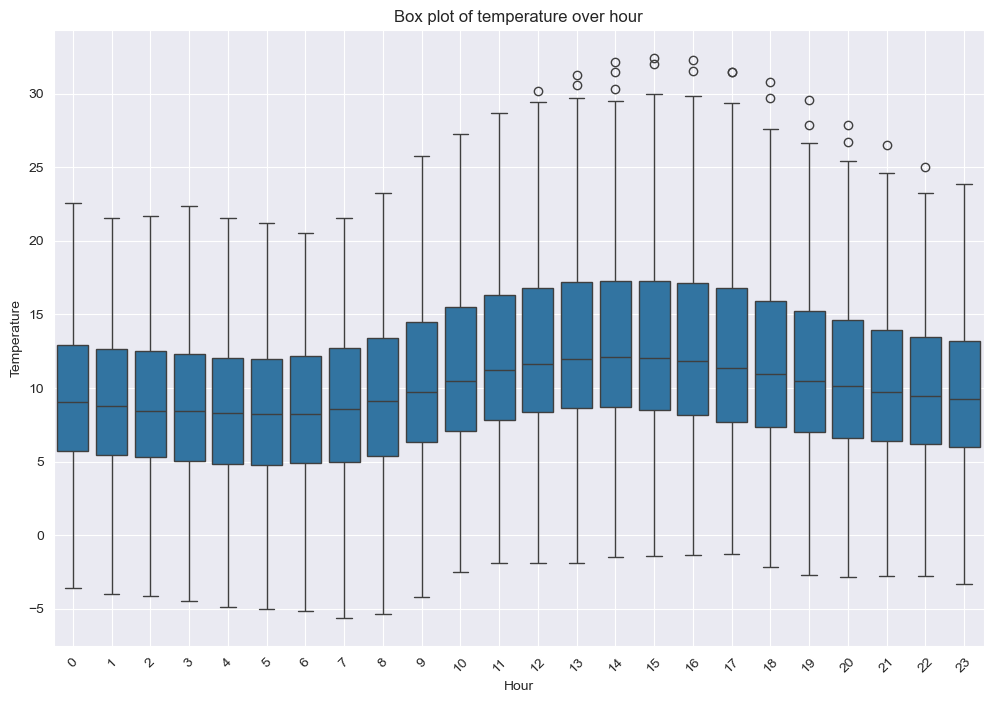

In [249]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'temperature', 'hour'))

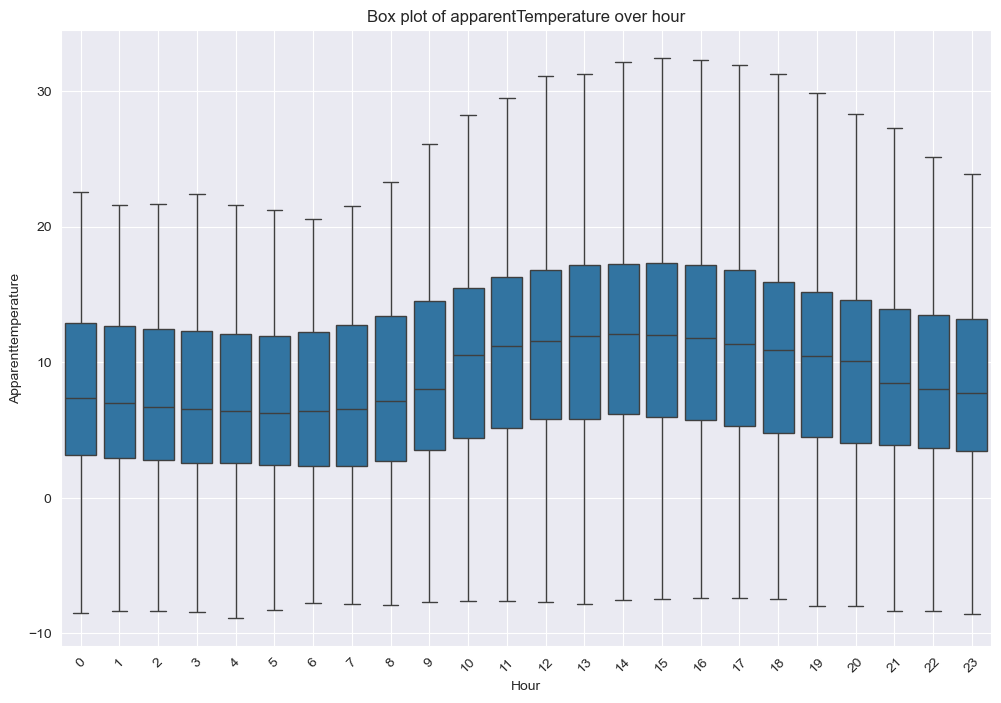

In [250]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'apparentTemperature', 'hour'))

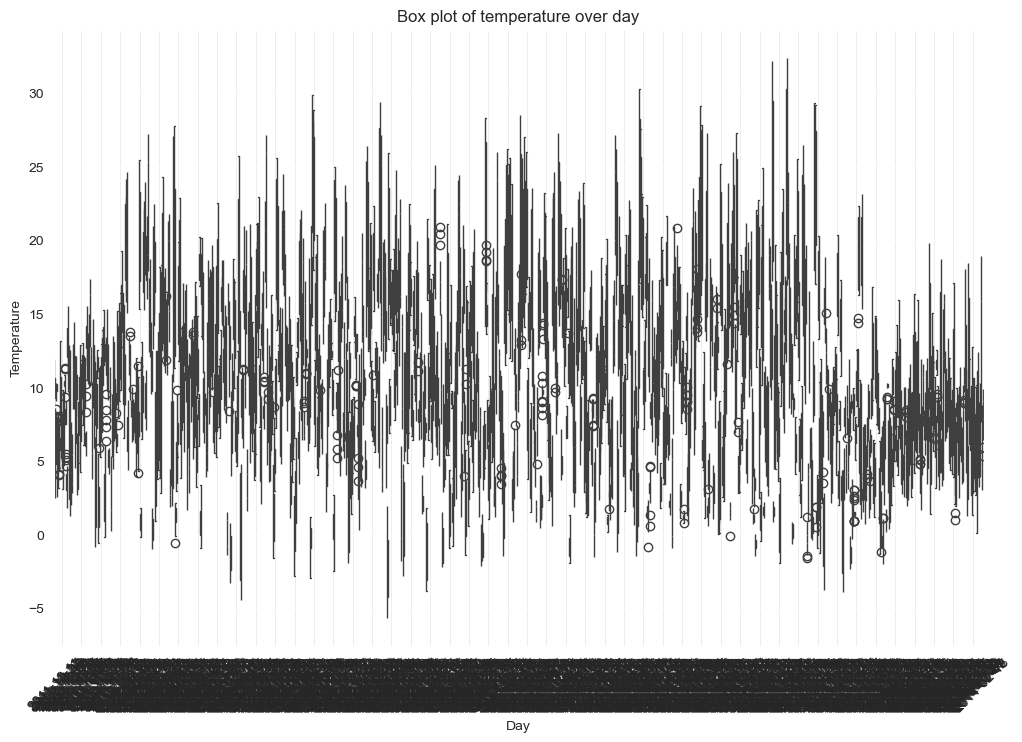

In [251]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'temperature', 'day'))

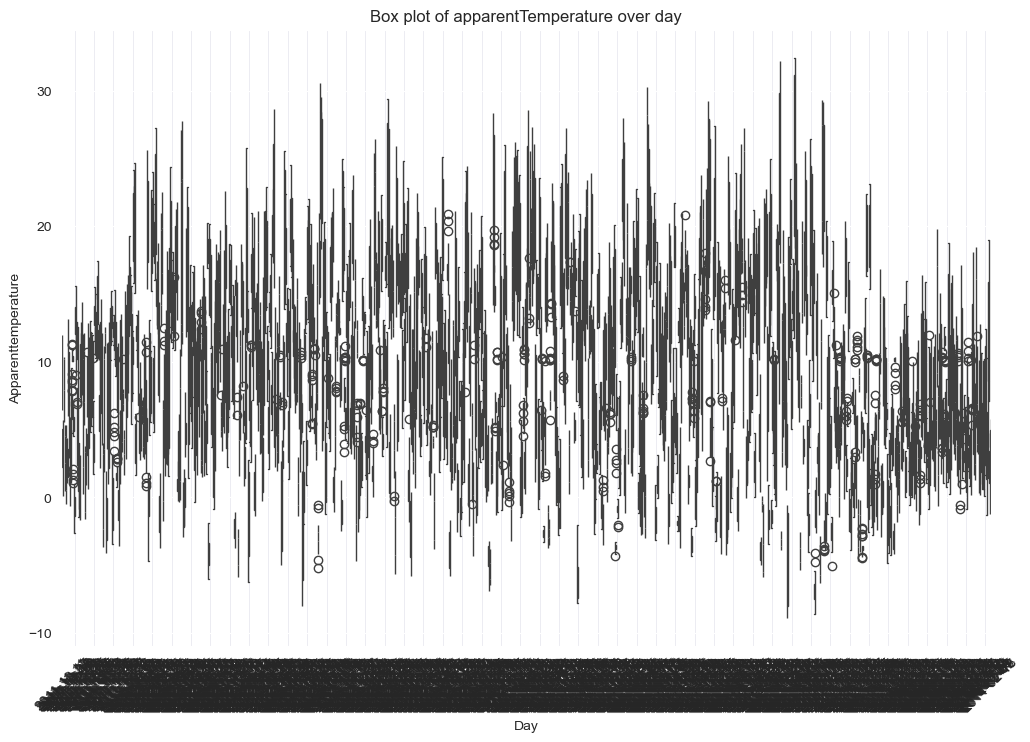

In [252]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'apparentTemperature', 'day'))

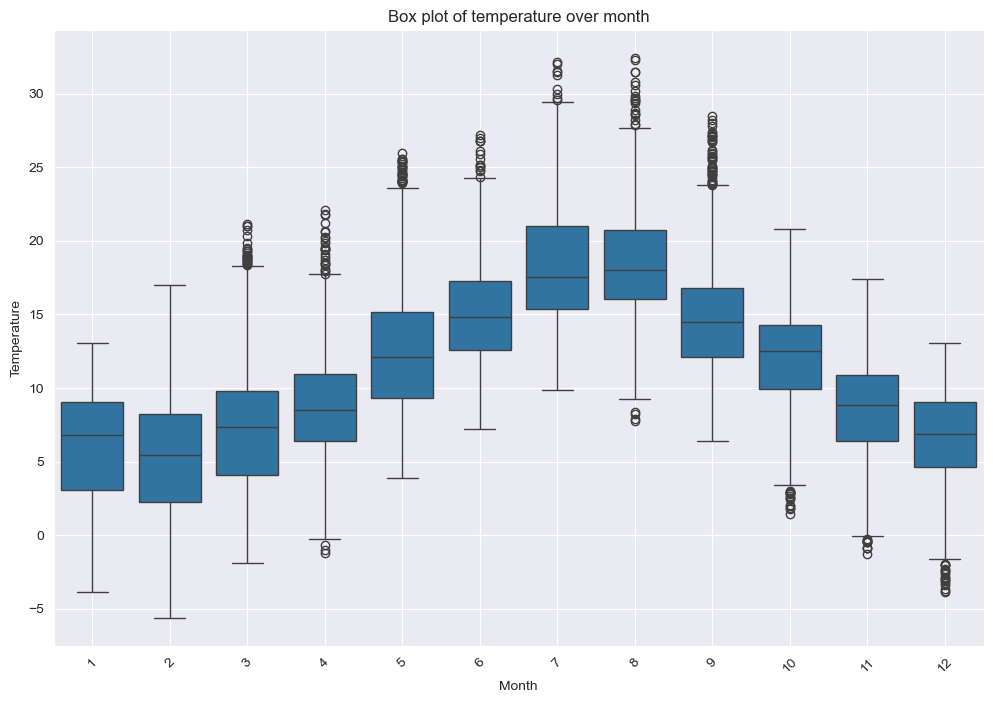

In [253]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'temperature', 'month'))

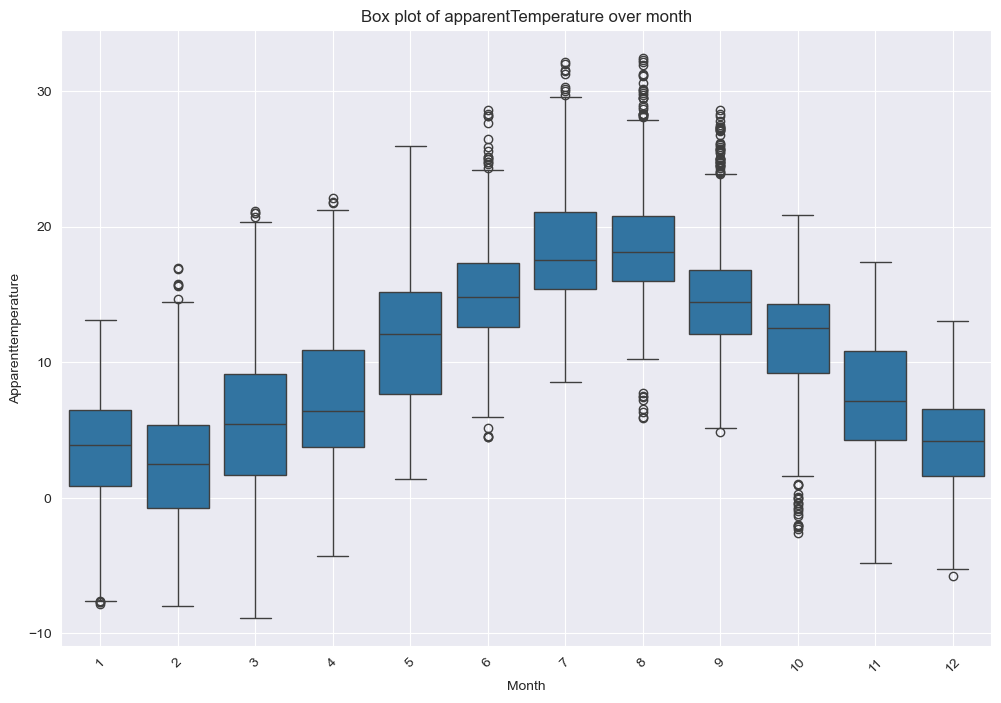

In [254]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'apparentTemperature', 'month'))

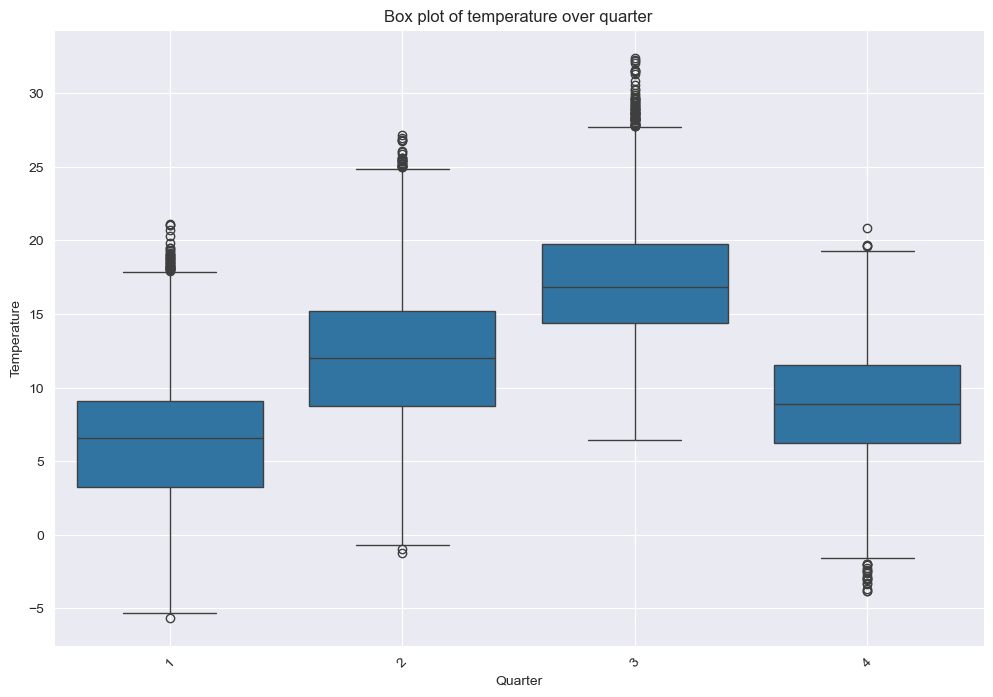

In [255]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'temperature', 'quarter'))

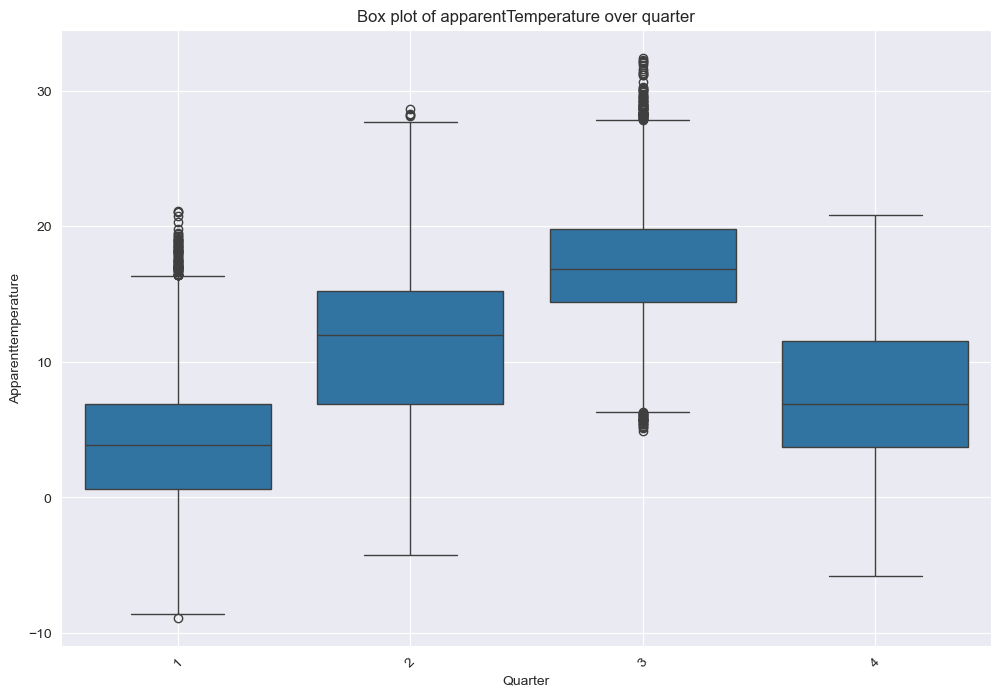

In [256]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'apparentTemperature', 'quarter'))

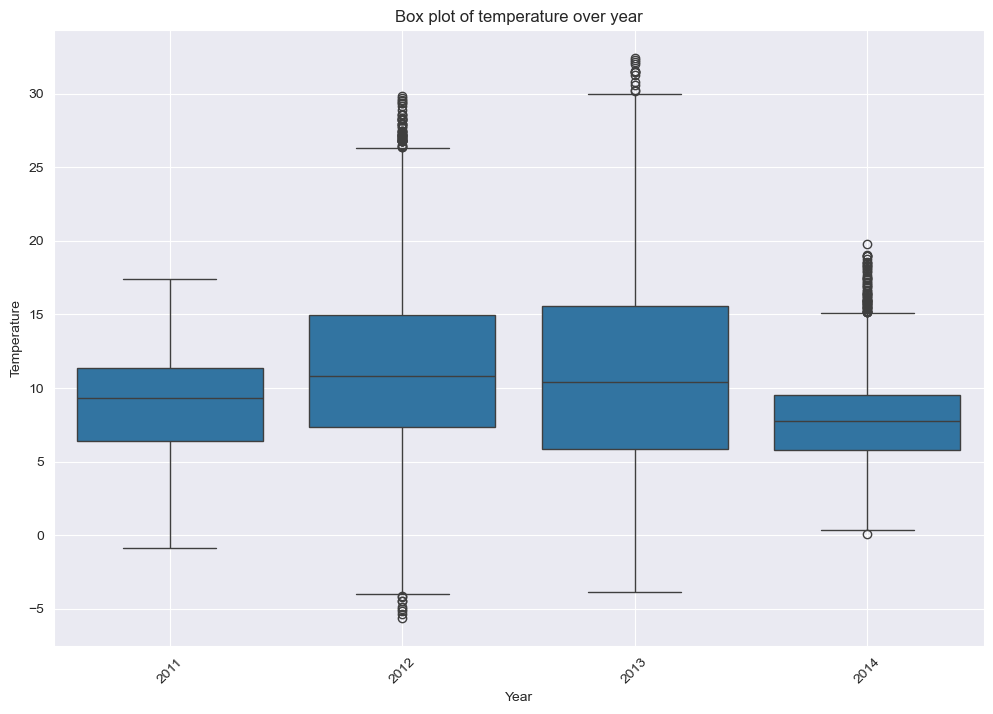

In [257]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'temperature', 'year'))

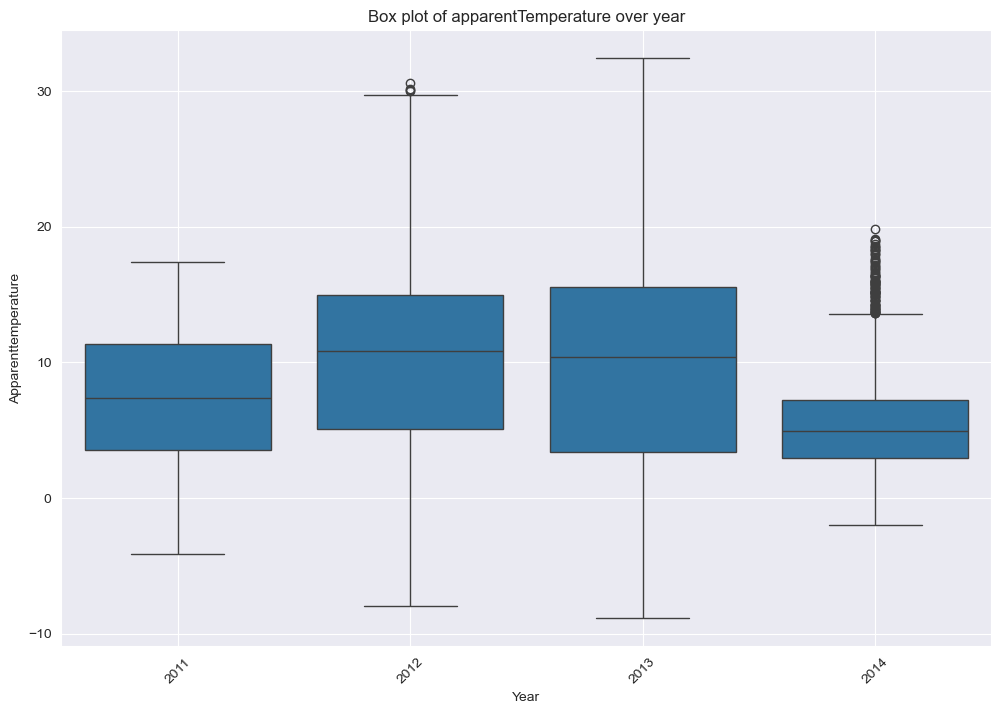

In [258]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'apparentTemperature', 'year'))

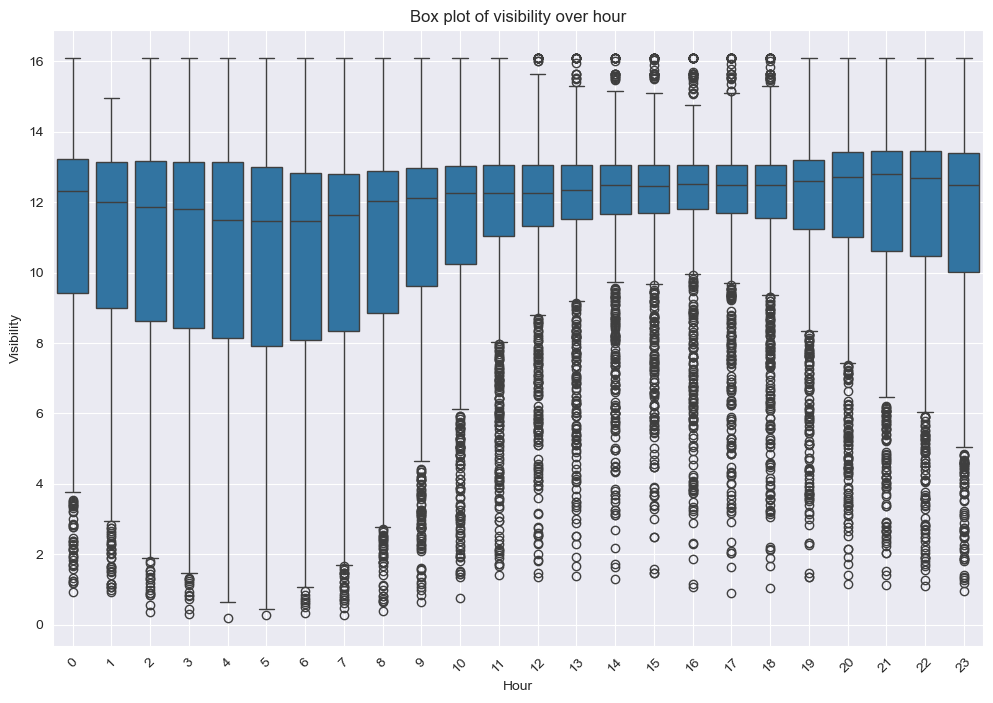

In [259]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'visibility', 'hour'))

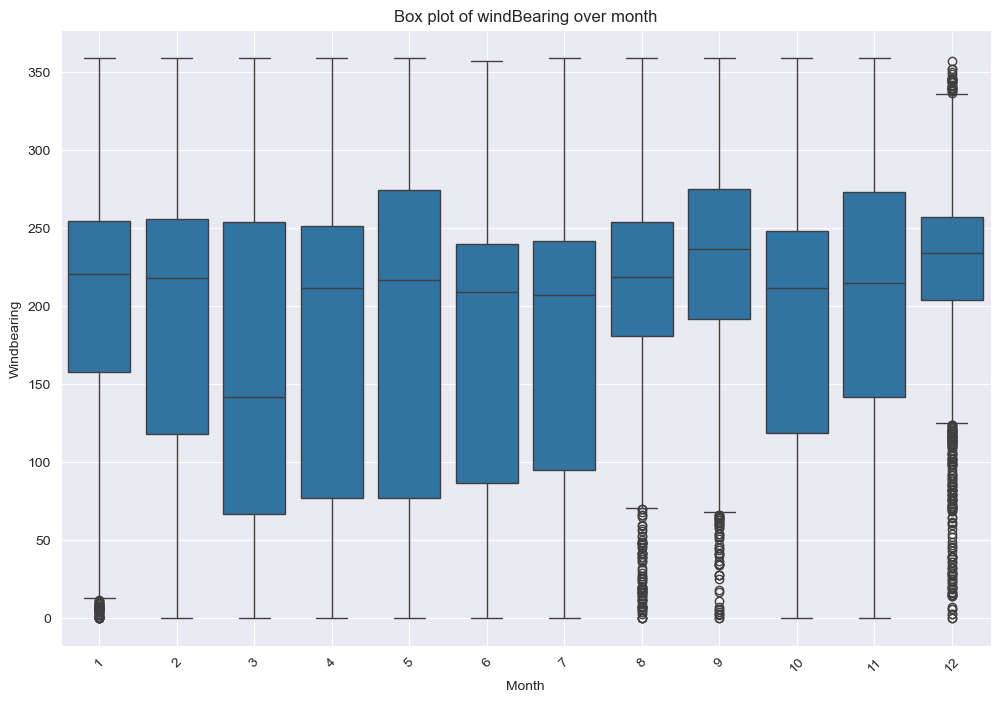

In [260]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'windBearing', 'month'))

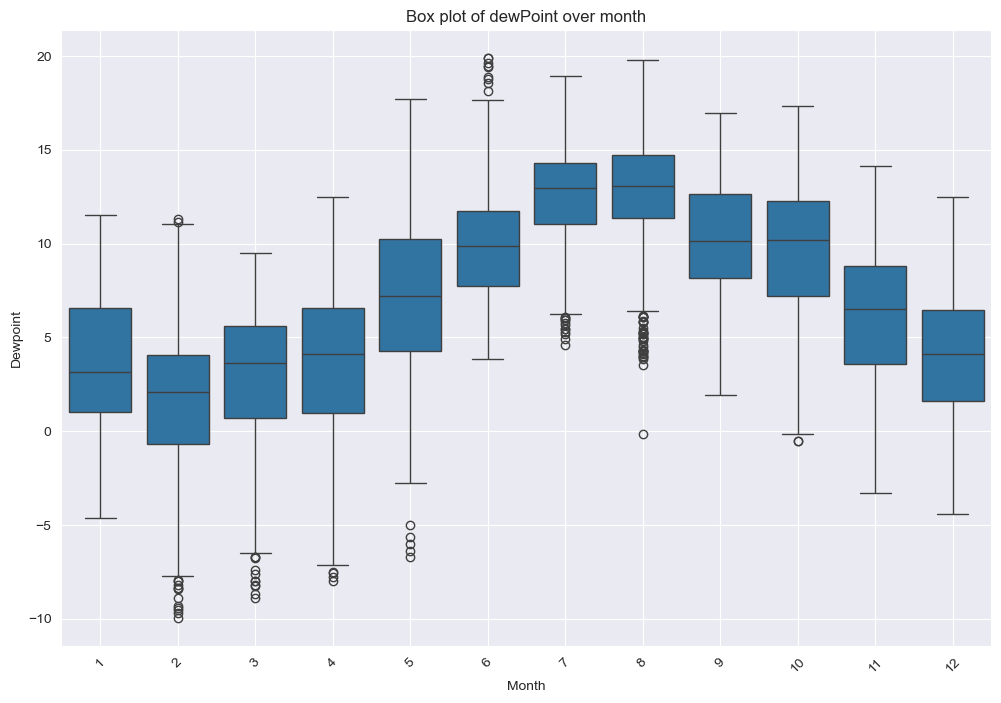

In [261]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'dewPoint', 'month'))

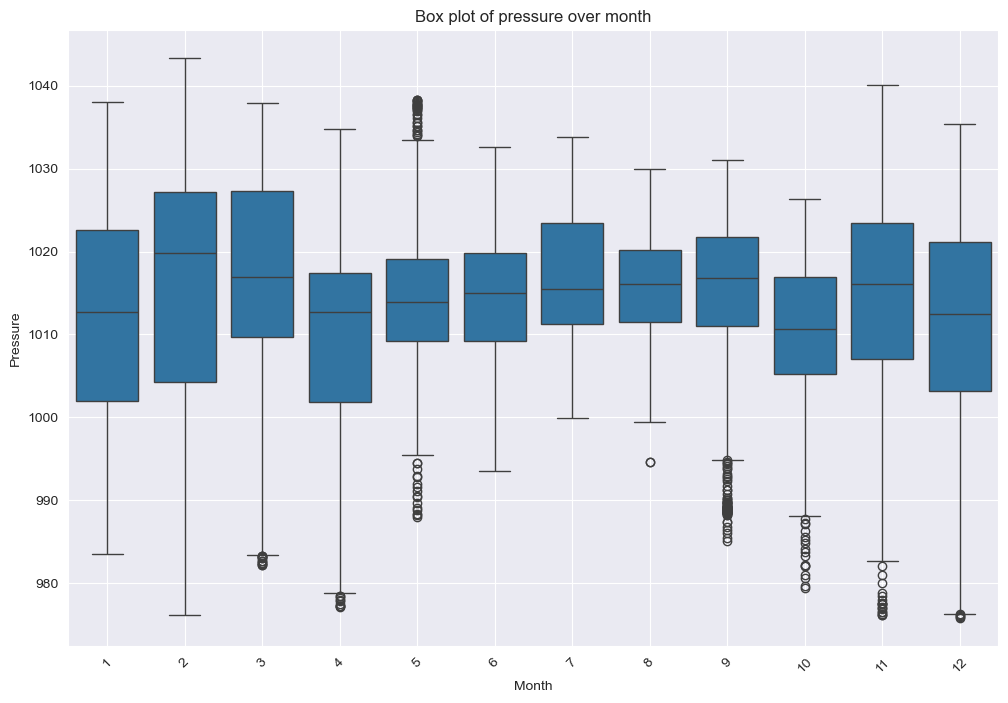

In [262]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'pressure', 'month'))

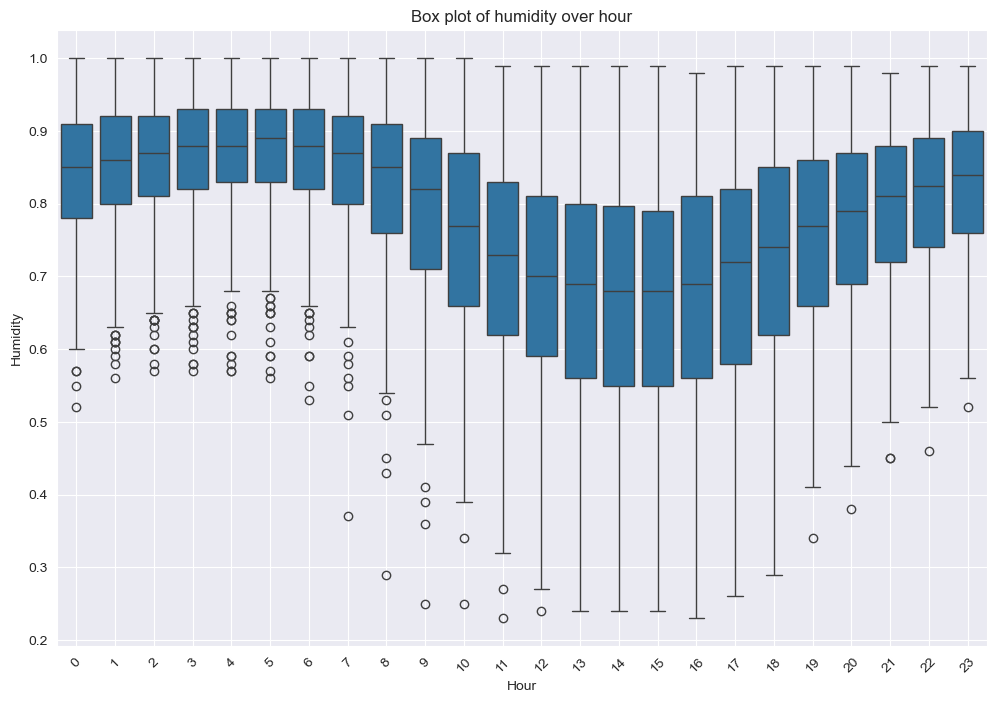

In [263]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'humidity', 'hour'))

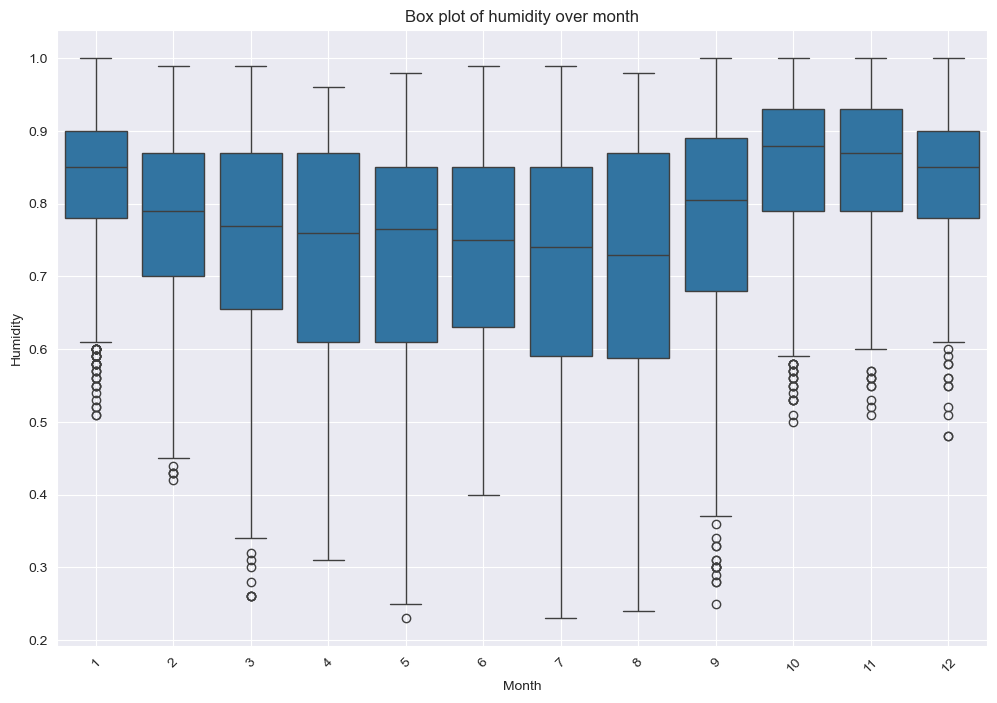

In [264]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'humidity', 'month'))

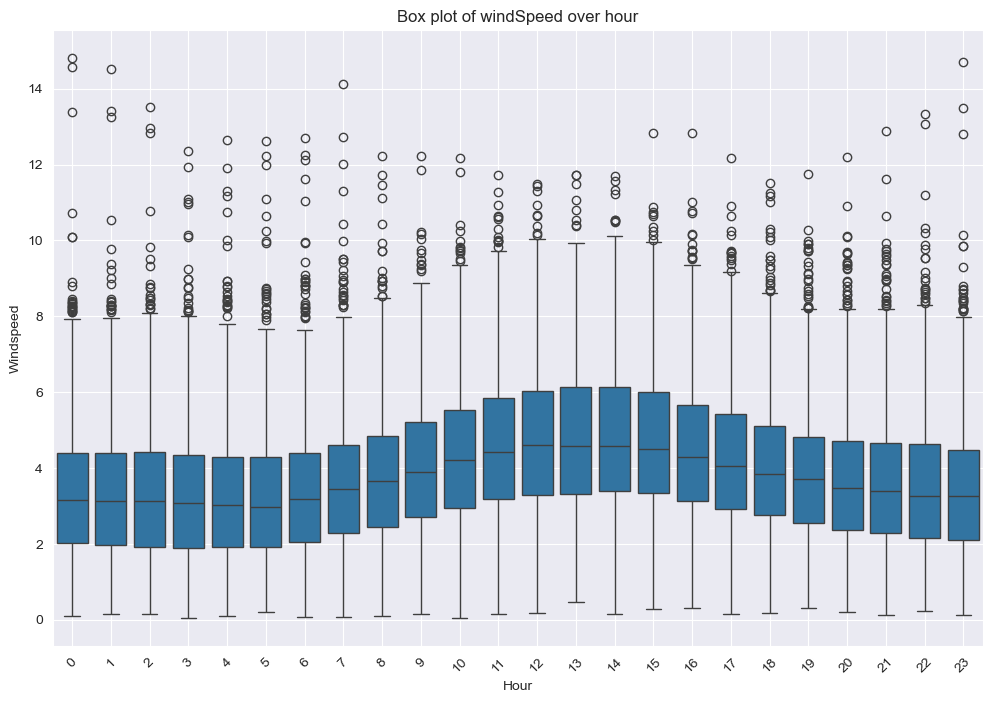

In [265]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'windSpeed', 'hour'))

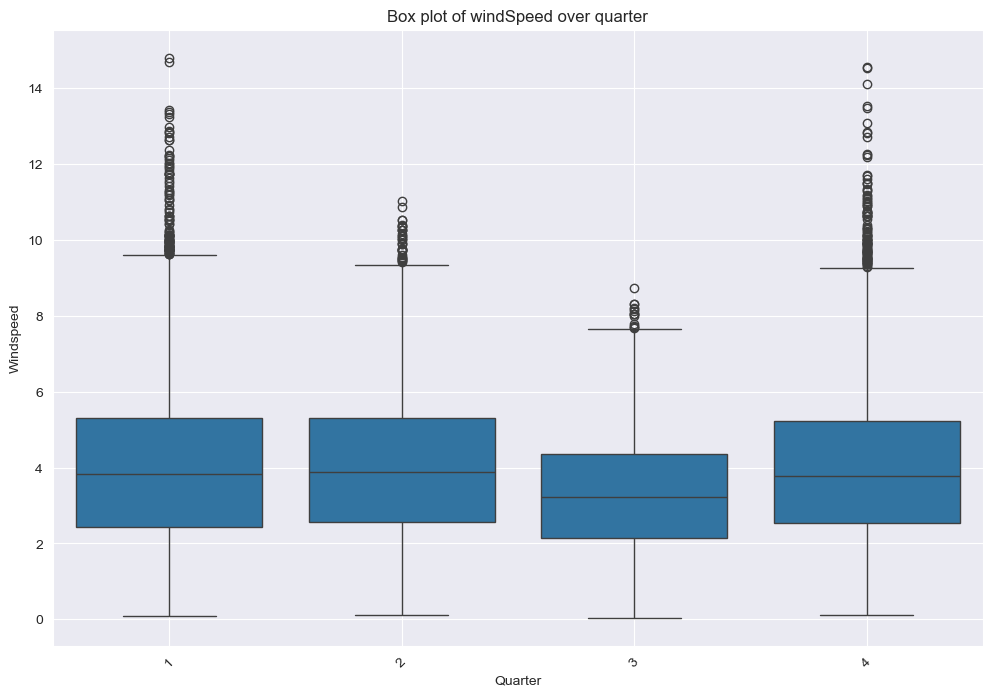

In [266]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'windSpeed', 'quarter'))

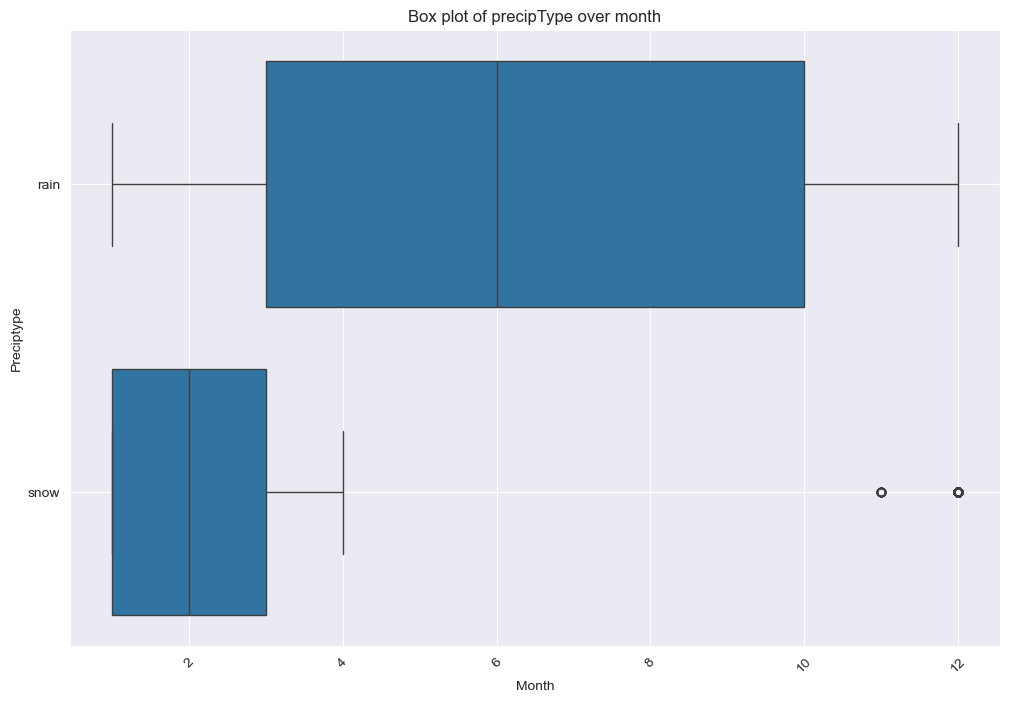

In [267]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'precipType', 'month'))

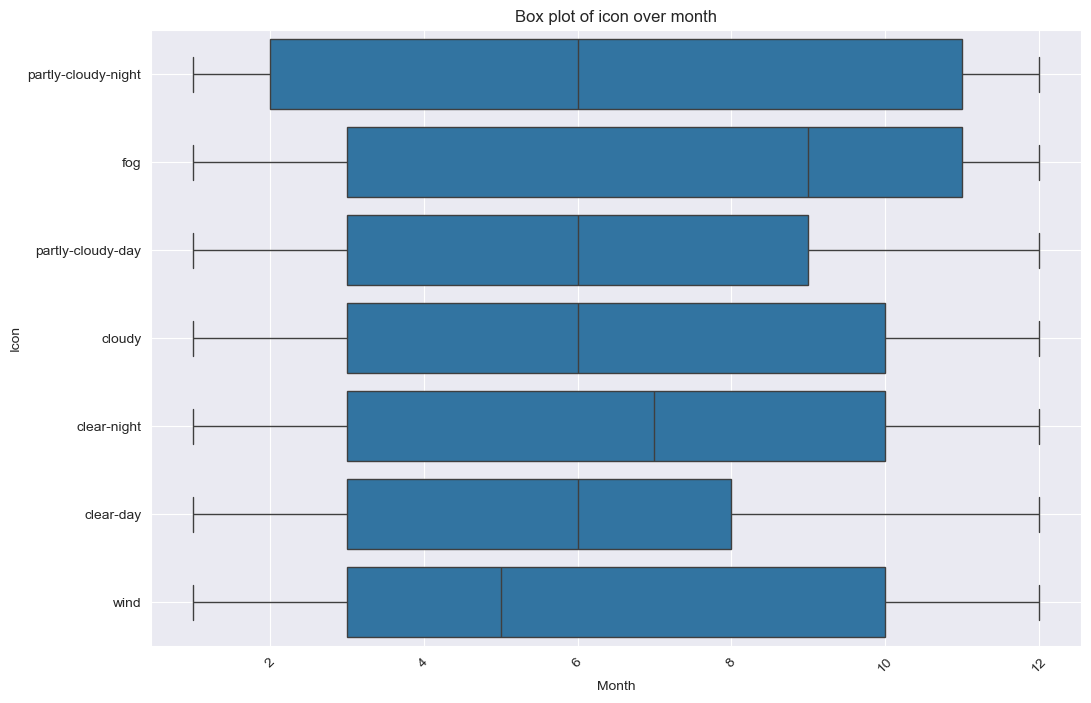

In [268]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'icon', 'month'))

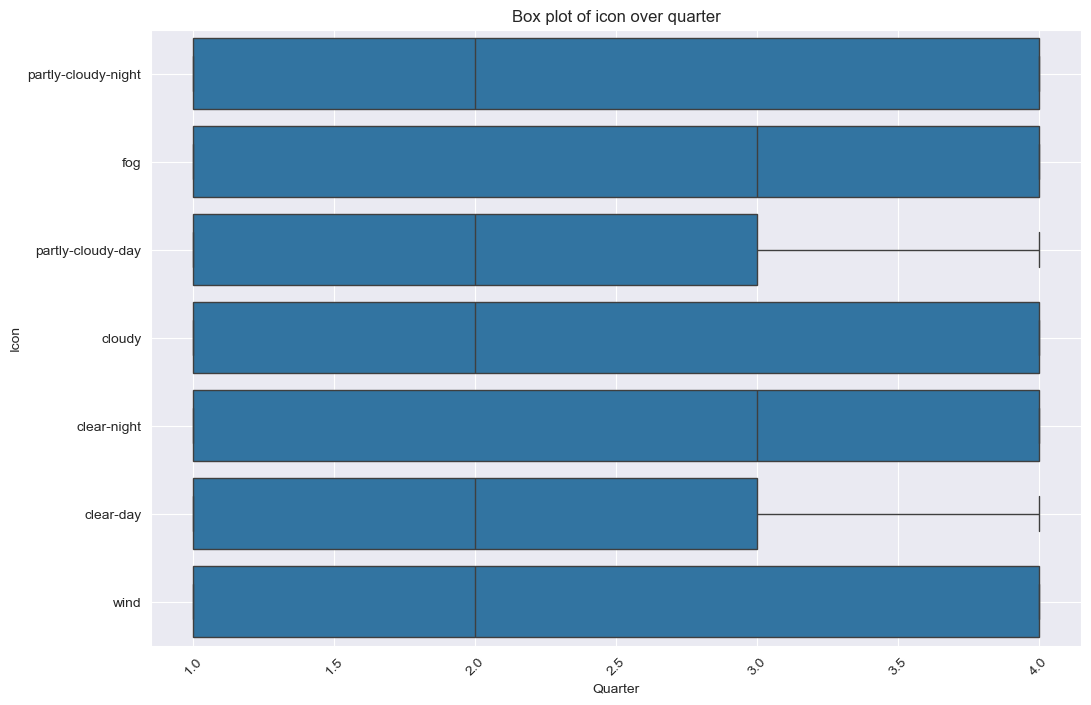

In [269]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'icon', 'quarter'))

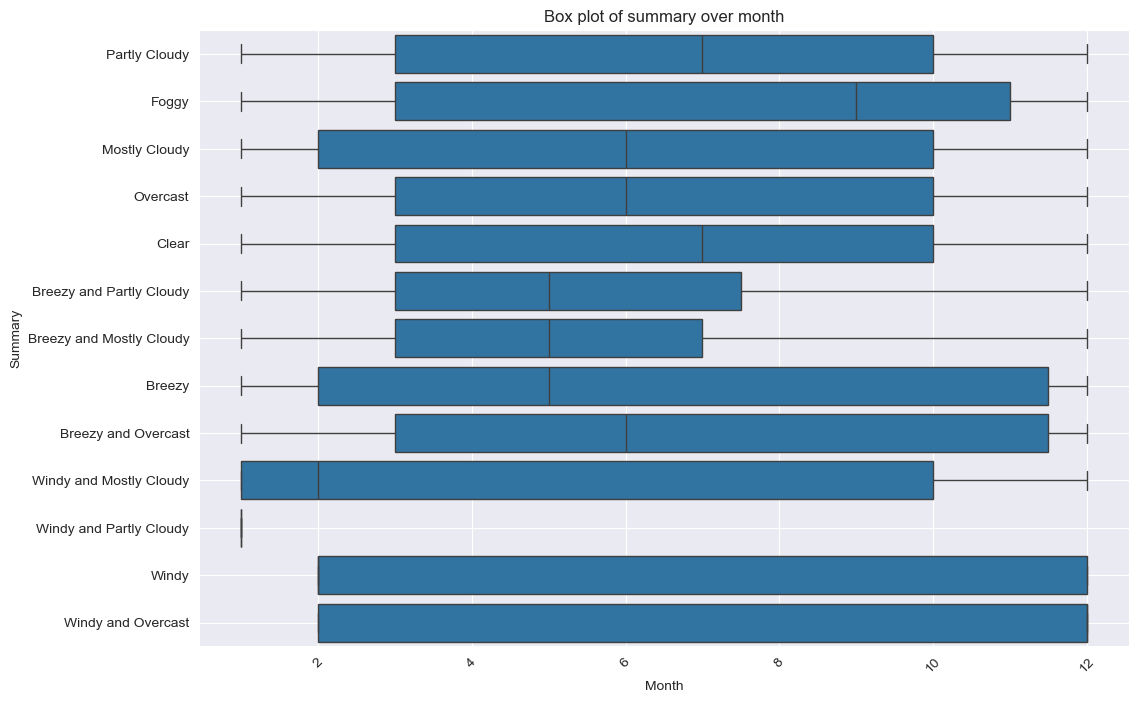

In [270]:
plot_level(2, lambda: plot_weather_boxplot(weather_hourly_darksky, 'summary', 'month'))

- The box chart reflects the changes of temperature, perceived temperature, visibility and windBearing over time during the day, as well as the concentrated distribution trend of these data.

In [271]:
def plot_weather_scatterplot(df, column_name1, column_name2):
    # Scatterplotting
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=column_name1, y=column_name2, data=df)
    plt.title(f'Scatter plot of {column_name1} vs. {column_name2}')
    plt.xlabel(column_name1.capitalize())
    plt.ylabel(column_name2.capitalize())
    plt.grid(True)
    plt.show()

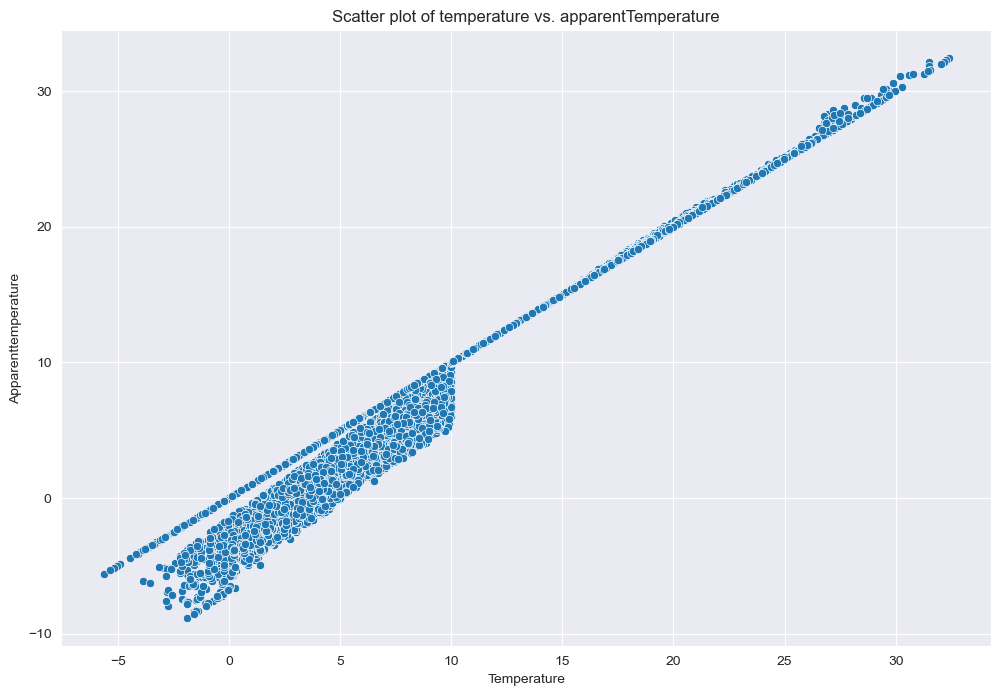

In [272]:
plot_level(1, lambda: plot_weather_scatterplot(weather_hourly_darksky, 'temperature', 'apparentTemperature'))

- This picture is one of the more interesting ones. According to the information conveyed by the picture, people feel the somatosensory temperature is lower when the ambient temperature is low, and the somatosensory temperature is higher when the ambient temperature is high.

In [126]:
def plot_weather_lineplot(df, column_name, time_type):
    if not pd.api.types.is_datetime64_any_dtype(df['time']):
        df['time'] = pd.to_datetime(df['time'])

    # Extract the corresponding time unit according to the time type
    if time_type == 'hour':
        df['time_unit'] = df['time'].dt.hour
    elif time_type == 'day':
        df['time_unit'] = df['time'].dt.date
    elif time_type == 'month':
        df['time_unit'] = df['time'].dt.month
    elif time_type == 'quarter':
        df['time_unit'] = df['time'].dt.quarter
    elif time_type == 'year':
        df['time_unit'] = df['time'].dt.year
    else:
        raise ValueError("Invalid time_type provided. Choose from 'day', 'month', 'quarter', 'year'.")

    # Plotting line graphs
    plt.figure(figsize=(12, 8))
    sns.lineplot(x='time_unit', y=column_name, data=df)
    plt.title(f'Line plot of {column_name} over {time_type}')
    plt.xlabel(time_type.capitalize())
    plt.ylabel(column_name.capitalize())
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

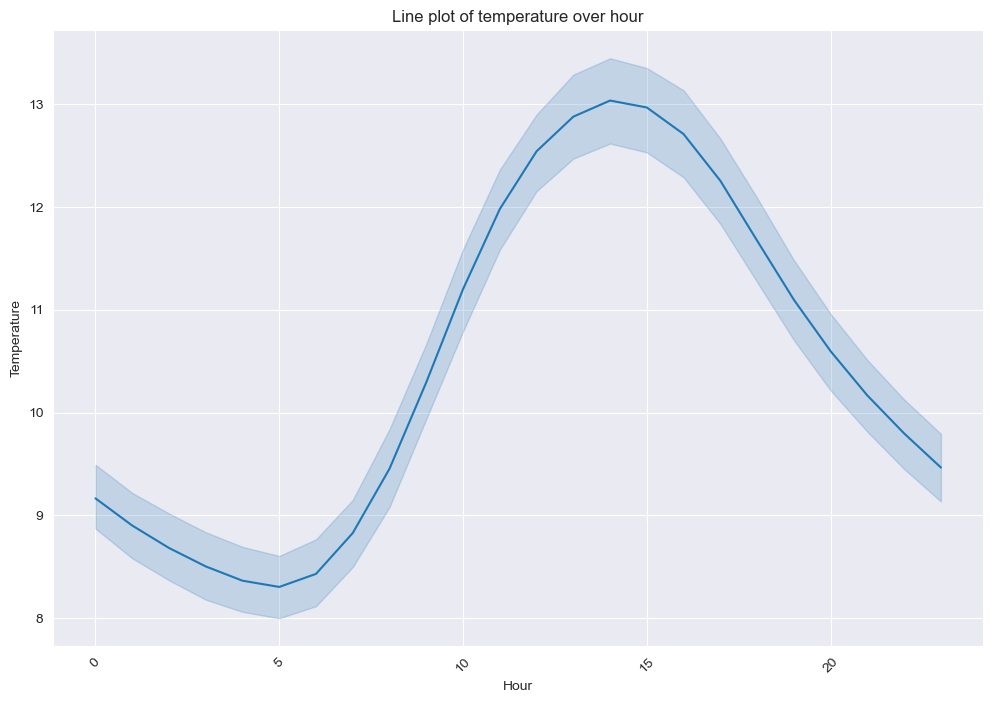

In [273]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'temperature', 'hour'))

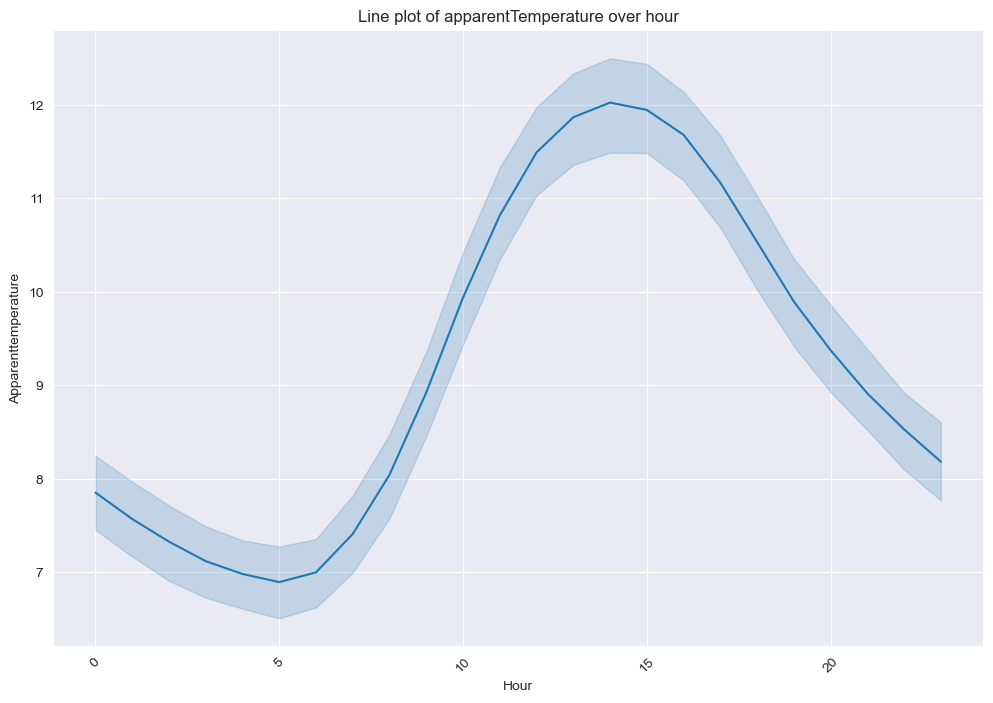

In [274]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'apparentTemperature', 'hour'))

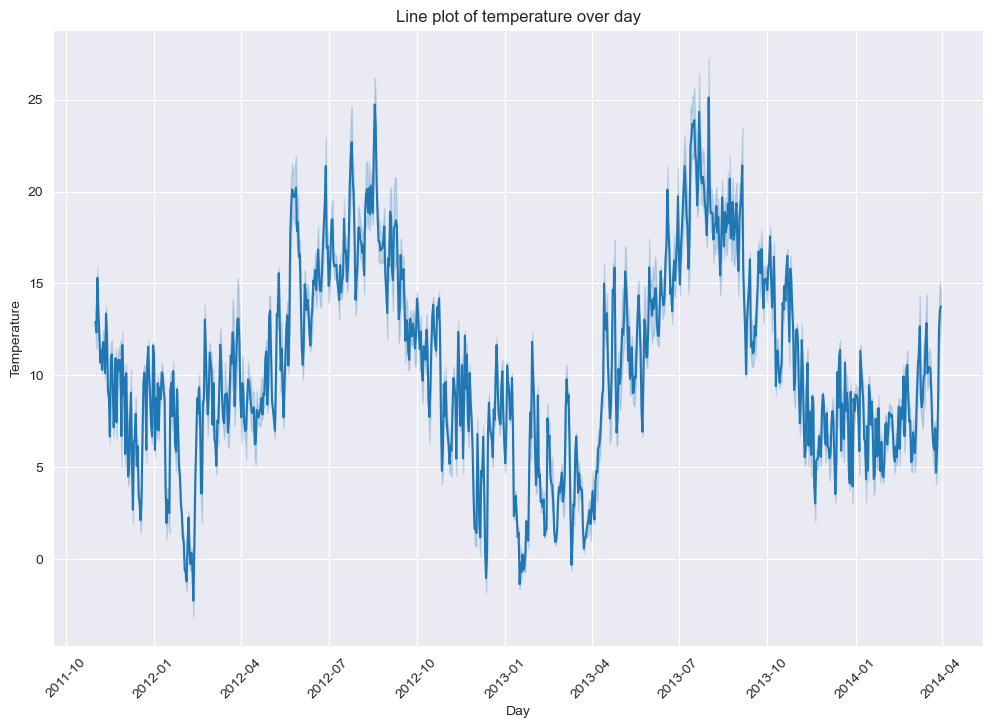

In [275]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'temperature', 'day'))

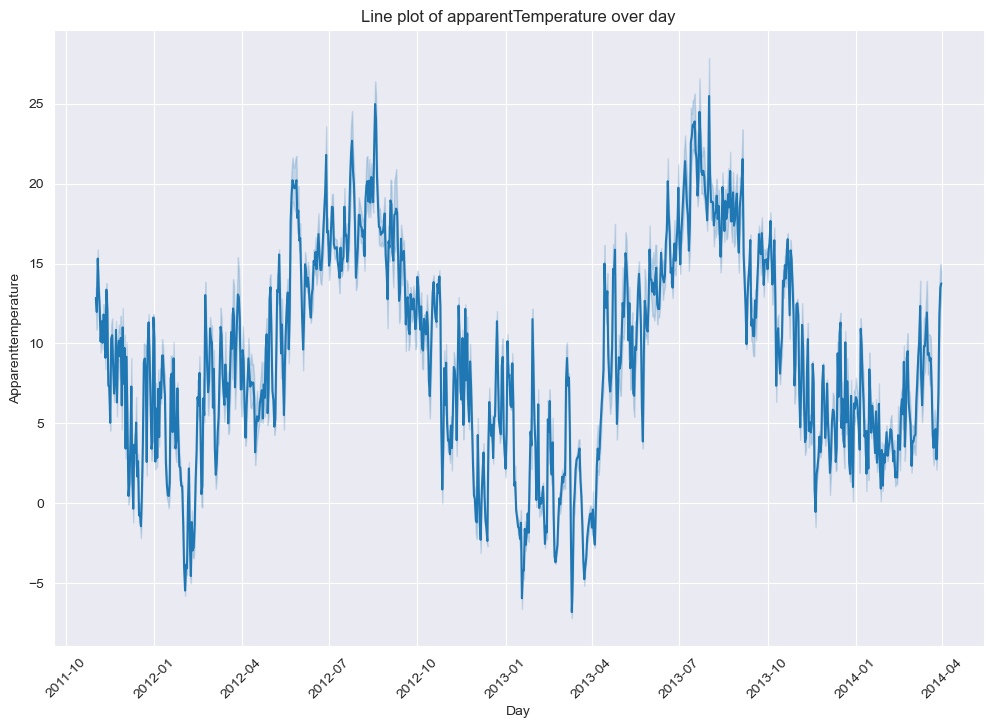

In [276]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'apparentTemperature', 'day'))

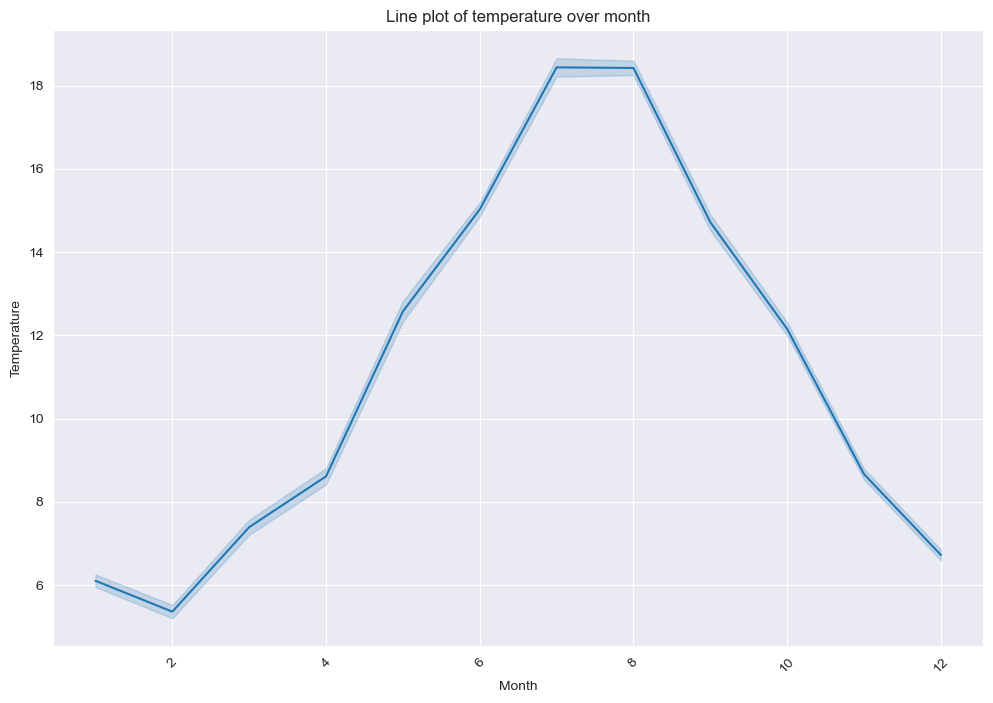

In [277]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'temperature', 'month'))

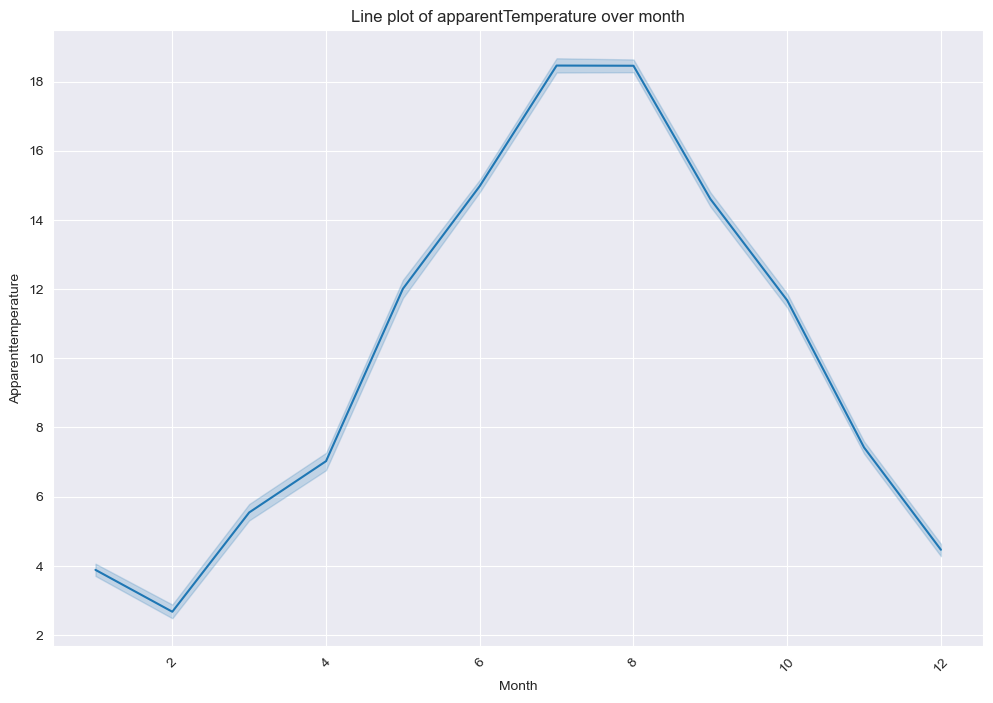

In [278]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'apparentTemperature', 'month'))

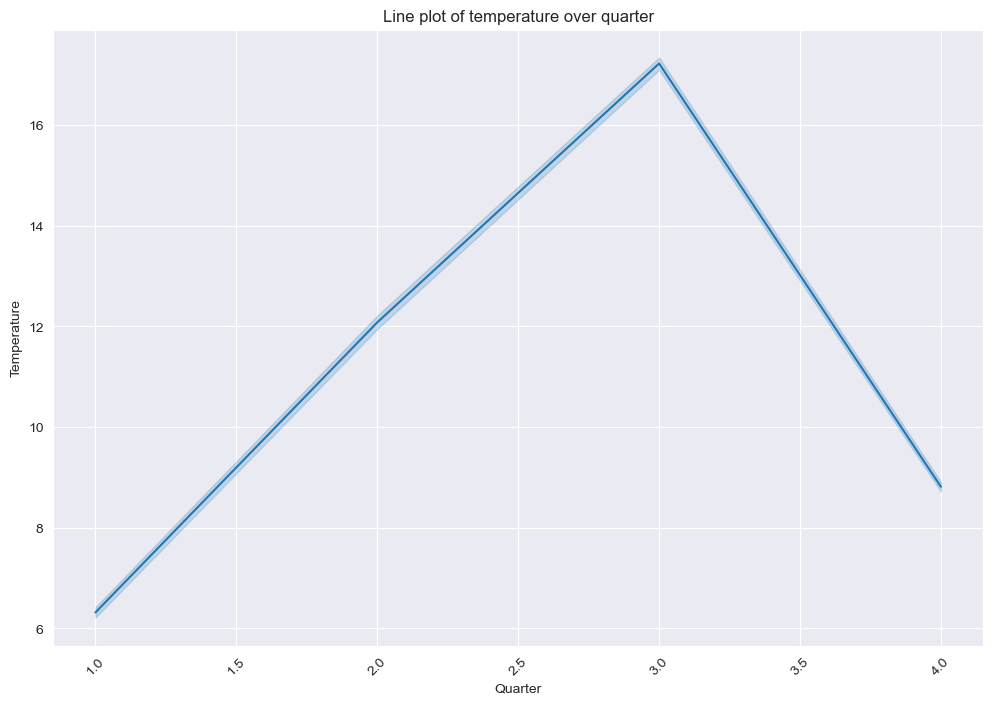

In [279]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'temperature', 'quarter'))

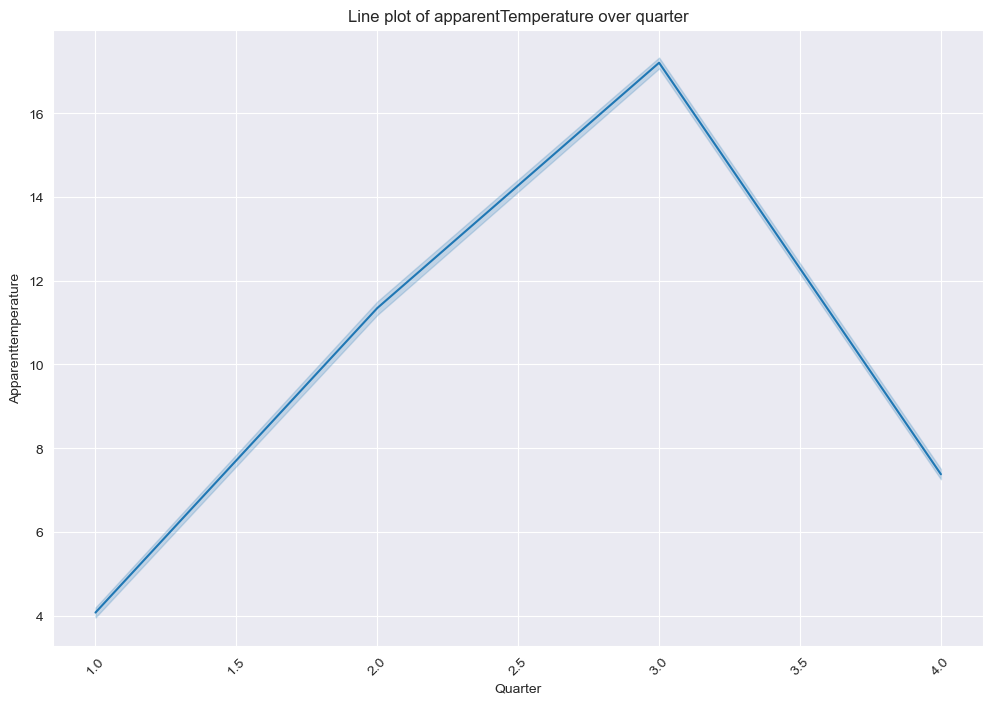

In [280]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'apparentTemperature', 'quarter'))

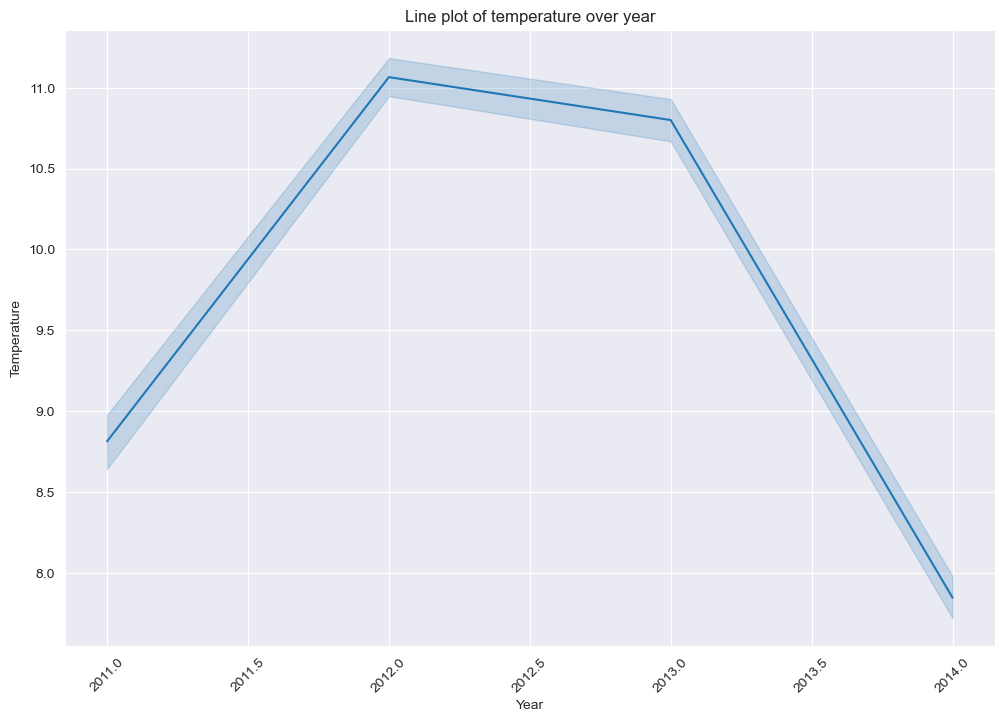

In [281]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'temperature', 'year'))

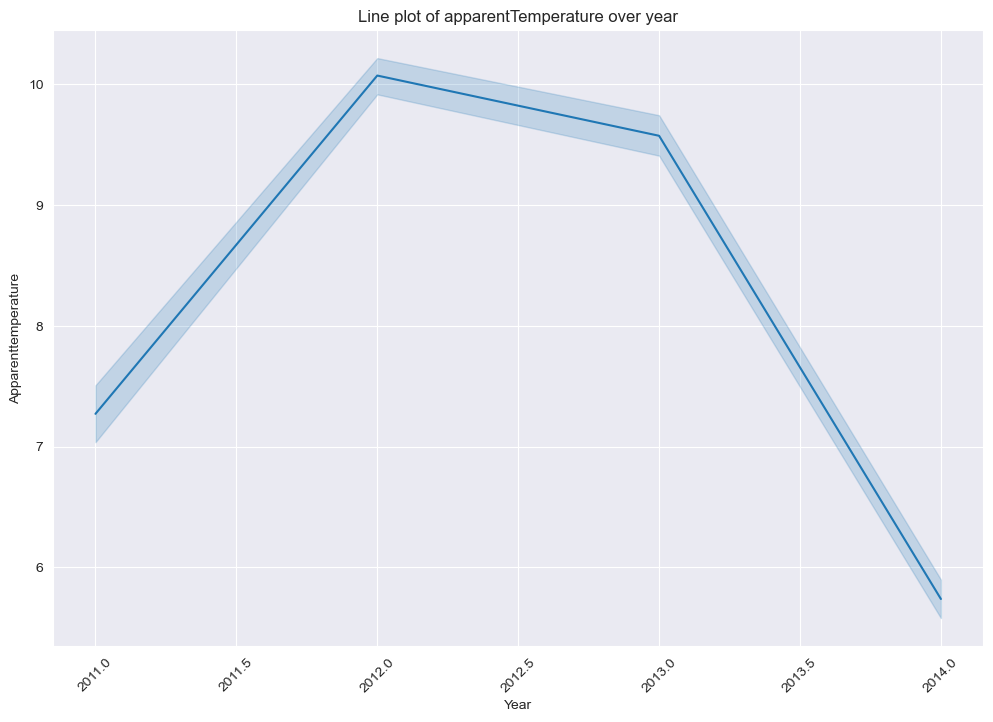

In [282]:
plot_level(2, lambda: plot_weather_lineplot(weather_hourly_darksky, 'apparentTemperature', 'year'))

- In another form, these graphs show the changes of temperature and sensory temperature over different time scales. The variation trends of sensory temperature and temperature are basically the same, and there are generally obvious diurnal temperature differences and seasonal fluctuations.

# 3. Time series clustering analysis
To identify seasonal fluctuations in energy consumption, daily variation patterns, and other key trends, this study chose to use time series clustering to analyze energy use characteristics across different households or time periods. Time series cluster analysis (Liao, 2005) is a technique for grouping time series data, aiming to classify sequences with similar time patterns into the same group. A series of steps such as data preparation, feature extraction and cluster execution will be carried out for time series cluster analysis.

## 3.1 Data Preparation

## 3.1.1 Timestamp alignment
First, the household electricity consumption data is processed, which needs to convert the time granularity. Since the household electricity consumption data is measured in half an hour and the weather data is measured in hours, the household electricity consumption data needs to be converted into hourly units. This part is achieved by calculating the average of two groups of half hour electricity consumption within each hour.

In [137]:
# First copy the non-consumption data columns in the original data
filtered_big_hhblock_one_hourly = filtered_big_hhblock[['LCLid', 'day']].copy()

# First copy the non-consumption data columns in the original data
for i in range(24):
    filtered_big_hhblock_one_hourly[f'hh_{i}'] = filtered_big_hhblock[[f'hh_{2 * i}', f'hh_{2 * i + 1}']].sum(axis=1)

In [138]:
filtered_big_hhblock_one_hourly.head(1000)

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_14,hh_15,hh_16,hh_17,hh_18,hh_19,hh_20,hh_21,hh_22,hh_23
0,MAC000002,2012-10-13,0.532,0.531,0.347,0.280,0.276,0.275,0.283,0.283,...,0.348,0.369,0.308,0.406,0.648,1.196,0.506,0.463,0.423,0.509
1,MAC000002,2012-10-14,0.428,0.314,0.208,0.206,0.199,0.196,0.197,0.195,...,0.280,0.231,0.256,0.464,1.471,2.031,1.566,1.223,0.441,0.437
2,MAC000002,2012-10-15,0.289,0.224,0.202,0.204,0.202,0.200,0.199,0.246,...,0.204,0.203,0.360,0.955,0.482,1.413,0.483,0.594,0.535,0.478
3,MAC000002,2012-10-16,0.474,0.311,0.205,0.203,0.196,0.195,0.195,0.194,...,0.207,0.206,0.368,0.488,0.713,1.138,0.420,0.414,0.401,0.359
4,MAC000002,2012-10-17,0.368,0.324,0.218,0.202,0.199,0.198,0.197,0.191,...,0.208,0.203,0.363,0.348,0.475,0.298,0.438,0.642,0.604,0.544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000246,2013-04-15,1.466,0.397,0.105,0.132,0.137,0.164,0.808,0.509,...,0.582,0.523,0.514,0.663,0.840,2.851,4.091,2.248,1.317,1.544
996,MAC000246,2013-04-16,0.735,1.441,0.326,0.101,0.087,0.114,1.037,1.573,...,0.108,0.087,0.370,0.326,0.426,3.371,5.093,3.478,1.688,1.437
997,MAC000246,2013-04-17,1.376,0.517,0.102,0.082,0.103,0.124,0.494,0.843,...,0.554,0.239,0.208,0.377,2.036,1.198,2.194,1.084,1.537,0.404
998,MAC000246,2013-04-18,0.254,0.512,0.897,0.577,0.088,0.174,0.858,0.766,...,0.637,0.539,0.289,0.269,0.445,1.310,4.080,2.916,2.059,0.976


In [139]:
filtered_big_hhblock_one_hourly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3439414 entries, 0 to 3469351
Data columns (total 26 columns):
 #   Column  Dtype         
---  ------  -----         
 0   LCLid   category      
 1   day     datetime64[ns]
 2   hh_0    float64       
 3   hh_1    float64       
 4   hh_2    float64       
 5   hh_3    float64       
 6   hh_4    float64       
 7   hh_5    float64       
 8   hh_6    float64       
 9   hh_7    float64       
 10  hh_8    float64       
 11  hh_9    float64       
 12  hh_10   float64       
 13  hh_11   float64       
 14  hh_12   float64       
 15  hh_13   float64       
 16  hh_14   float64       
 17  hh_15   float64       
 18  hh_16   float64       
 19  hh_17   float64       
 20  hh_18   float64       
 21  hh_19   float64       
 22  hh_20   float64       
 23  hh_21   float64       
 24  hh_22   float64       
 25  hh_23   float64       
dtypes: category(1), datetime64[ns](1), float64(24)
memory usage: 689.0 MB


### 3.1.2 Data Merging
(1) Time format conversion 
Converts the day column of household electricity consumption data to the same date and hour format as the time column of weather data and merges the two data sets accordingly.

In [140]:
@memory.cache
def turn_wide_to_long(filtered_big_hhblock_one_hourly):
    # Convert LCLid columns to categorical data types
    filtered_big_hhblock_one_hourly['LCLid'] = filtered_big_hhblock_one_hourly['LCLid'].astype('category')
    
    ddf = dd.from_pandas(filtered_big_hhblock_one_hourly, npartitions=32)

    # First convert Dask DataFrame to Pandas DataFrame for melt operation
    pdf = ddf.compute()  # Converting a Dask DataFrame back to a Pandas DataFrame

    # Use Pandas' melt function to perform the operation
    pdf_melted = pdf.melt(id_vars=['LCLid', 'day'], var_name='hour', value_name='energy')

    # Convert the 'hour' column, extracting the hours from 'hh_X' and converting them to integers
    pdf_melted['hour'] = pdf_melted['hour'].str.extract('(\d+)').astype(int)

    # Merge 'day' and 'hour' into a datetime column
    pdf_melted['day-hour'] = pd.to_datetime(pdf_melted['day']) + pd.to_timedelta(pdf_melted['hour'], unit='h')

    # Delete columns that are no longer needed
    pdf_melted.drop(['day', 'hour'], axis=1, inplace=True)

    # The processed Pandas DataFrame is then converted back to a Dask DataFrame
    ddf_melted = dd.from_pandas(pdf_melted, npartitions=10)

    # Setting the progress bar
    pbar = ProgressBar()
    pbar.register()

    df_result = ddf_melted.compute()

    # cancellation progress bar
    pbar.unregister()

    df_result.to_parquet('filtered_big_hhblock_one_hourly_one_row.parquet')

    return df_result

In [141]:
# %%time
# if os.path.exists('filtered_big_hhblock_one_hourly_one_row.parquet'):
#     filtered_big_hhblock_one_hourly_one_row = pd.read_parquet('filtered_big_hhblock_one_hourly_one_row.parquet')
# else:
#     filtered_big_hhblock_one_hourly_one_row = turn_wide_to_long(filtered_big_hhblock_one_hourly)

In [142]:
%%time
filtered_big_hhblock_one_hourly_one_row = turn_wide_to_long(filtered_big_hhblock_one_hourly)

CPU times: total: 141 ms
Wall time: 1.57 s


In [143]:
filtered_big_hhblock_one_hourly_one_row.head(1000)

,LCLid,energy,day-hour
0,MAC000002,0.532,2012-10-13
1,MAC000002,0.428,2012-10-14
2,MAC000002,0.289,2012-10-15
3,MAC000002,0.474,2012-10-16
4,MAC000002,0.368,2012-10-17
...,...,...,...
995,MAC000246,1.466,2013-04-15
996,MAC000246,0.735,2013-04-16
997,MAC000246,1.376,2013-04-17
998,MAC000246,0.254,2013-04-18


(2) Data merging
The converted household electricity consumption data and weather data are combined into one data set.

In [144]:
# sampled_filtered_big_hhblock_one_hourly_one_row = filtered_big_hhblock_one_hourly_one_row.sample(frac=0.001, random_state=0)

In [145]:
# sampled_filtered_big_hhblock_one_hourly_one_row

In [146]:
weather_hourly_darksky.head(1000)

,visibility,windBearing,temperature,time,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,5.97,104,10.24,2011-11-11 00:00:00,8.86,1016.76,10.24,2.77,rain,partly-cloudy-night,0.91,Partly Cloudy
1,4.88,99,9.76,2011-11-11 01:00:00,8.83,1016.63,8.24,2.95,rain,partly-cloudy-night,0.94,Partly Cloudy
2,3.70,98,9.46,2011-11-11 02:00:00,8.79,1016.36,7.76,3.17,rain,partly-cloudy-night,0.96,Partly Cloudy
3,3.12,99,9.23,2011-11-11 03:00:00,8.63,1016.28,7.44,3.25,rain,fog,0.96,Foggy
4,1.85,111,9.26,2011-11-11 04:00:00,9.21,1015.98,7.24,3.70,rain,fog,1.00,Foggy
...,...,...,...,...,...,...,...,...,...,...,...,...
995,13.07,252,11.63,2011-12-31 11:00:00,9.73,1010.91,11.63,5.24,rain,partly-cloudy-day,0.88,Mostly Cloudy
996,13.52,251,11.88,2011-12-31 12:00:00,9.77,1010.65,11.88,6.08,rain,partly-cloudy-day,0.87,Mostly Cloudy
997,13.07,252,12.16,2011-12-31 13:00:00,10.09,1010.47,12.16,6.00,rain,partly-cloudy-day,0.87,Mostly Cloudy
998,12.89,251,12.17,2011-12-31 14:00:00,9.74,1010.15,12.17,5.98,rain,partly-cloudy-day,0.85,Mostly Cloudy


In [147]:
weather_hourly_darksky.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21165 entries, 0 to 21164
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   visibility           21165 non-null  float64       
 1   windBearing          21165 non-null  int64         
 2   temperature          21165 non-null  float64       
 3   time                 21165 non-null  datetime64[ns]
 4   dewPoint             21165 non-null  float64       
 5   pressure             21165 non-null  float64       
 6   apparentTemperature  21165 non-null  float64       
 7   windSpeed            21165 non-null  float64       
 8   precipType           21165 non-null  object        
 9   icon                 21165 non-null  object        
 10  humidity             21165 non-null  float64       
 11  summary              21165 non-null  object        
dtypes: datetime64[ns](1), float64(7), int64(1), object(3)
memory usage: 1.9+ MB


In [148]:
@memory.cache
def combine_data_with_mapping(filtered_big_hhblock_one_hourly_one_row, weather_hourly_darksky):
    # Initialise a dictionary to hold the transformation mapping
    mapping_dict = {}

    # Convert to dask dataframe
    ddf_weather = dd.from_pandas(weather_hourly_darksky, npartitions=10)

    # Firstly the frequency of occurrence is calculated globally and a mapping dictionary is generated
    for col in ['precipType', 'icon', 'summary']:
        if col in ddf_weather.columns:
            # Use dask to calculate the number of occurrences of each value
            frequencies = ddf_weather[col].value_counts().compute()
            # Generate mapping based on frequency ordering
            mapping = {value: i for i, value in enumerate(frequencies.sort_values(ascending=False).index)}
            mapping_dict[col] = mapping

            # Generate mapping based on frequency ordering
        ddf_weather[col] = ddf_weather[col].map(mapping, meta=('x', 'int64')).astype('int64')
        
    # Data consolidation using Dask
    ddf_result = dd.from_pandas(filtered_big_hhblock_one_hourly_one_row, npartitions=10)

    combined_ddf = dd.merge(ddf_result, ddf_weather, left_on='day-hour', right_on='time', how='inner')

    pbar = ProgressBar()
    pbar.register()

    combined_pd = combined_ddf.compute()

    pbar.unregister()

    combined_pd.drop(['time'], axis=1, inplace=True)

    combined_pd.to_parquet('combined_hourly_weather.parquet')

    # Returns the merged DataFrame and mapping dictionary
    return combined_pd, mapping_dict


In [149]:
# %%time
# if os.path.exists('combined_hourly_weather.parquet'):
#     print('Reading combined_hourly_weather.parquet...')
#     combined_hourly_weather = pd.read_parquet('combined_hourly_weather.parquet')
# else:
#     print('Combining data...')
#     combined_hourly_weather, mapping_dict = combine_data_with_mapping(filtered_big_hhblock_one_hourly_one_row, weather_hourly_darksky)

In [150]:
%%time
combined_hourly_weather, mapping_dict = combine_data_with_mapping(filtered_big_hhblock_one_hourly_one_row, weather_hourly_darksky)

CPU times: total: 2.34 s
Wall time: 6.54 s


In [151]:
combined_hourly_weather.head(1000)

,LCLid,energy,day-hour,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,MAC002441,2.420,2013-05-13 07:00:00,11.84,257,11.39,6.88,1012.67,11.39,6.21,0,0,0.74,1
1,MAC002441,3.030,2013-05-14 07:00:00,12.26,234,8.76,4.53,1007.48,6.27,4.44,0,0,0.75,1
2,MAC002441,2.287,2013-05-16 07:00:00,7.92,182,7.81,6.52,1000.54,7.81,0.57,0,3,0.92,2
3,MAC002441,3.233,2013-05-28 07:00:00,4.47,58,10.41,9.40,1001.00,10.41,2.45,0,5,0.93,3
4,MAC002441,0.639,2013-06-03 07:00:00,13.89,39,12.34,6.36,1032.62,12.34,2.19,0,0,0.67,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000030,0.467,2013-03-28 07:00:00,7.61,17,-0.35,-2.32,1011.20,-3.61,2.67,1,3,0.87,2
996,MAC000030,0.162,2013-04-18 07:00:00,13.52,232,10.17,3.54,1011.44,10.17,9.05,0,4,0.63,6
997,MAC000030,0.424,2013-04-23 07:00:00,13.36,273,11.49,8.26,1018.52,11.49,3.91,0,0,0.81,0
998,MAC000030,0.316,2013-04-27 07:00:00,12.96,350,5.27,1.89,1013.80,2.35,3.73,0,0,0.79,0


In [152]:
display(mapping_dict)

{'precipType': {'rain': 0, 'snow': 1},
 'icon': {'partly-cloudy-day': 0,
  'partly-cloudy-night': 1,
  'clear-night': 2,
  'clear-day': 3,
  'wind': 4,
  'cloudy': 5,
  'fog': 6},
 'summary': {'Partly Cloudy': 0,
  'Mostly Cloudy': 1,
  'Clear': 2,
  'Overcast': 3,
  'Foggy': 4,
  'Breezy and Mostly Cloudy': 5,
  'Breezy and Partly Cloudy': 6,
  'Breezy': 7,
  'Breezy and Overcast': 8,
  'Windy and Mostly Cloudy': 9,
  'Windy': 10,
  'Windy and Overcast': 11,
  'Windy and Partly Cloudy': 12}}

In [153]:
combined_hourly_weather.head(1000)

,LCLid,energy,day-hour,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,MAC002441,2.420,2013-05-13 07:00:00,11.84,257,11.39,6.88,1012.67,11.39,6.21,0,0,0.74,1
1,MAC002441,3.030,2013-05-14 07:00:00,12.26,234,8.76,4.53,1007.48,6.27,4.44,0,0,0.75,1
2,MAC002441,2.287,2013-05-16 07:00:00,7.92,182,7.81,6.52,1000.54,7.81,0.57,0,3,0.92,2
3,MAC002441,3.233,2013-05-28 07:00:00,4.47,58,10.41,9.40,1001.00,10.41,2.45,0,5,0.93,3
4,MAC002441,0.639,2013-06-03 07:00:00,13.89,39,12.34,6.36,1032.62,12.34,2.19,0,0,0.67,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC000030,0.467,2013-03-28 07:00:00,7.61,17,-0.35,-2.32,1011.20,-3.61,2.67,1,3,0.87,2
996,MAC000030,0.162,2013-04-18 07:00:00,13.52,232,10.17,3.54,1011.44,10.17,9.05,0,4,0.63,6
997,MAC000030,0.424,2013-04-23 07:00:00,13.36,273,11.49,8.26,1018.52,11.49,3.91,0,0,0.81,0
998,MAC000030,0.316,2013-04-27 07:00:00,12.96,350,5.27,1.89,1013.80,2.35,3.73,0,0,0.79,0


(3) Missing value processing
The new combined data table is checked to contain no missing values.

In [154]:
missing_values_count = combined_hourly_weather.isnull().sum()
missing_values_count

LCLid                  0
energy                 0
day-hour               0
visibility             0
windBearing            0
temperature            0
dewPoint               0
pressure               0
apparentTemperature    0
windSpeed              0
precipType             0
icon                   0
humidity               0
summary                0
dtype: int64

### 3.1.3 Data standardization

(1) Feature column generation
Transform the overall time into a split time feature to better represent the periodicity of time." day-hour” -> ”hour”, ”day”, ”day_of_week”, ”month”, ”quarter”, ”year”
These periodic time features are then converted into cyclic features to better represent periodicity of time in the model." hour” -> ”hour_sin”, ”hour_cos” ”day” -> ”day_sin”, ”day_cos” ”day_of_week” -> ”day_of_week_sin”,  ”day_of_week_cos” ”month” -> ”month_sin”, ”month_cos” ”quarter” -> ”quarter_sin”, ”quarter_cos” ”year” -> ”year_sin”,  ”year_cos”

In [155]:
@memory.cache
def add_cyclic_features(df):
    # Extracting periodic features from 'day-hour' columns
    df['hour'] = df['day-hour'].dt.hour
    df['day'] = df['day-hour'].dt.day
    df['day_of_week'] = df['day-hour'].dt.dayofweek
    df['month'] = df['day-hour'].dt.month
    df['quarter'] = df['day-hour'].dt.quarter
    df['year'] = df['day-hour'].dt.year

    # Converting hourly features to cyclic features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

    # # Conversion days are cyclic features
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

    # Converting weekly features to cyclic features
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # Converting Monthly Features to Cyclic Features
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    # Converting quarterly features to cyclical features
    df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
    df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)

    # Converting year features to cyclic features
    df['year_sin'] = np.sin(2 * np.pi * df['year'] / 365)
    df['year_cos'] = np.cos(2 * np.pi * df['year'] / 365)
    
    # Delete the original time signature column
    df.drop(['day-hour', 'hour', 'day', 'day_of_week', 'month', 'quarter', 'year'], axis=1, inplace=True)

    df.to_parquet('cluster_cyclic_features.parquet')
    
    return df

In [156]:
%%time
if os.path.exists('cluster_cyclic_features.parquet'):
    print('Reading cluster_cyclic_features.parquet...')
    combined_hourly_weather_all_features = pd.read_parquet('cluster_cyclic_features.parquet')
else:
    print('Adding cyclic features...')
    combined_hourly_weather_all_features = add_cyclic_features(combined_hourly_weather)

Reading cluster_cyclic_features.parquet...
CPU times: total: 5.62 s
Wall time: 20.3 s


In [157]:
# %%time
# combined_hourly_weather_all_features = add_cyclic_features(combined_hourly_weather)

In [158]:
combined_hourly_weather_all_features.head(1000)

,LCLid,energy,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,...,day_sin,day_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,year_sin,year_cos
0,MAC000002,0.264,13.41,192,15.21,11.19,1002.39,15.21,5.45,0,...,-0.485302,-0.874347,0.433884,-0.900969,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
1,MAC000002,0.279,10.14,33,8.49,5.07,1011.97,5.68,5.06,0,...,-0.848644,0.528964,-0.433884,-0.900969,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
2,MAC000002,0.206,13.52,275,9.47,4.35,1005.13,7.54,3.62,0,...,-0.201299,0.979530,0.781831,0.623490,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
3,MAC000002,0.237,12.94,285,11.33,8.68,1007.07,11.33,3.89,0,...,-0.299363,-0.954139,-0.974928,-0.222521,-5.000000e-01,0.866025,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
4,MAC000002,0.500,13.44,342,5.21,1.04,1022.38,1.76,4.65,0,...,0.897805,-0.440394,0.000000,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC003482,0.346,11.99,220,11.62,7.33,1015.18,11.62,4.72,0,...,0.998717,-0.050649,0.974928,-0.222521,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747
996,MAC003482,0.290,12.13,200,9.01,3.96,1006.36,6.33,5.04,0,...,0.485302,-0.874347,0.000000,1.000000,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747
997,MAC003482,0.343,7.55,137,5.55,3.35,1010.80,4.04,1.97,0,...,-0.897805,-0.440394,0.781831,0.623490,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747
998,MAC003482,0.293,12.13,150,7.88,2.62,1004.21,4.11,7.36,0,...,0.571268,0.820763,0.000000,1.000000,8.660254e-01,0.500000,1.000000e+00,6.123234e-17,-0.111659,-0.993747


In [159]:
combined_hourly_weather_all_features.columns

Index(['LCLid', 'energy', 'visibility', 'windBearing', 'temperature',
       'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed',
       'precipType', 'icon', 'humidity', 'summary', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin',
       'month_cos', 'quarter_sin', 'quarter_cos', 'year_sin', 'year_cos'],
      dtype='object')

(2) Calculate the correlation coefficient

In [160]:
def compute_correlation(series_energy, column, series_column):
    series_energy_np = np.array(series_energy)
    series_column_np = np.array(series_column)

    # Calculating Pearson, Spearman and Kendall correlations
    pearson_corr = series_energy.corr(series_column, method='pearson')
    spearman_corr = series_energy.corr(series_column, method='spearman')
    kendall_corr = series_energy.corr(series_column, method='kendall')

    # Calculate DTW distance
    dtw_distance = dtw.distance(series_energy_np, series_column_np)

    return column, pearson_corr, spearman_corr, kendall_corr, dtw_distance

In [283]:
sampled_combined_hourly_weather_all_features = combined_hourly_weather_all_features.sample(frac=0.0001, random_state=0)
sampled_combined_hourly_weather_all_features

,LCLid,energy,visibility,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,...,day_sin,day_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,year_sin,year_cos
8055381,MAC000685,0.056,12.09,98,8.63,6.36,1017.88,8.63,0.52,0,...,0.988468,0.151428,0.781831,0.623490,5.000000e-01,-8.660254e-01,1.224647e-16,-1.000000e+00,-0.094537,-0.995521
2755035,MAC001234,0.231,7.32,89,3.83,1.90,1021.00,1.33,2.70,0,...,0.571268,0.820763,-0.781831,0.623490,1.000000e+00,6.123234e-17,1.000000e+00,6.123234e-17,-0.094537,-0.995521
6859792,MAC004681,0.013,9.98,212,12.18,11.07,1016.27,12.18,8.36,0,...,-0.101168,-0.994869,0.000000,1.000000,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00,-0.094537,-0.995521
8184989,MAC003973,0.504,13.62,64,14.11,7.02,1014.18,14.11,1.43,0,...,0.937752,0.347305,-0.974928,-0.222521,-8.660254e-01,5.000000e-01,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
331406,MAC005285,0.105,10.69,142,3.16,1.71,1002.87,3.16,0.56,0,...,-0.790776,-0.612106,0.000000,1.000000,5.000000e-01,8.660254e-01,1.000000e+00,6.123234e-17,-0.111659,-0.993747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1588242,MAC002585,0.089,13.21,208,5.77,3.67,1021.28,4.12,2.15,0,...,-0.571268,0.820763,-0.433884,-0.900969,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
918361,MAC001518,0.767,12.15,38,16.29,8.57,1011.96,16.29,2.22,0,...,-0.651372,-0.758758,-0.781831,0.623490,5.000000e-01,-8.660254e-01,1.224647e-16,-1.000000e+00,-0.094537,-0.995521
7415581,MAC000430,0.070,5.99,329,1.26,-0.86,1029.38,1.26,1.32,0,...,0.790776,-0.612106,0.781831,0.623490,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00,-0.077386,-0.997001
3334751,MAC003055,0.024,11.31,229,14.92,13.29,1017.01,14.92,4.82,0,...,-0.485302,-0.874347,0.974928,-0.222521,-5.000000e-01,-8.660254e-01,-1.000000e+00,-1.836970e-16,-0.077386,-0.997001


In [285]:
series_energy = sampled_combined_hourly_weather_all_features['energy']

In [286]:
df_dropped = sampled_combined_hourly_weather_all_features.drop(['LCLid', 'energy'], axis=1)

In [287]:
results = Parallel(n_jobs=32)(delayed(compute_correlation)(series_energy, column, df_dropped[column]) for column in df_dropped.columns)

In [288]:
correlation_df = pd.DataFrame(results, columns=['Column', 'Pearson', 'Spearman', 'Kendall', 'DTW']).set_index('Column')

In [289]:
correlation_df

,Pearson,Spearman,Kendall,DTW
Column,,,,
visibility,-0.001997,0.017165,0.011445,349.494058
windBearing,-0.008672,-0.009937,-0.006572,18814.831746
temperature,-0.090863,-0.054380,-0.035999,583.196718
dewPoint,-0.104810,-0.079260,-0.052680,475.984187
pressure,-0.033117,-0.017036,-0.011342,92004.857598
apparentTemperature,-0.096347,-0.058219,-0.038429,668.568483
windSpeed,0.044294,0.047792,0.032158,186.761194
precipType,0.014394,0.000646,0.000527,49.529414
icon,-0.026900,-0.053114,-0.039306,118.858007


In [290]:
print(correlation_df)

                      Pearson  Spearman   Kendall           DTW
Column                                                         
visibility          -0.001997  0.017165  0.011445    349.494058
windBearing         -0.008672 -0.009937 -0.006572  18814.831746
temperature         -0.090863 -0.054380 -0.035999    583.196718
dewPoint            -0.104810 -0.079260 -0.052680    475.984187
pressure            -0.033117 -0.017036 -0.011342  92004.857598
apparentTemperature -0.096347 -0.058219 -0.038429    668.568483
windSpeed            0.044294  0.047792  0.032158    186.761194
precipType           0.014394  0.000646  0.000527     49.529414
icon                -0.026900 -0.053114 -0.039306    118.858007
humidity            -0.008785 -0.057156 -0.038491     45.327360
summary             -0.018273 -0.070397 -0.052448    113.666549
hour_sin            -0.171443 -0.235632 -0.161398     65.134011
hour_cos            -0.049458 -0.079079 -0.053797     65.360221
day_sin              0.004797  0.002079 

Results for a frac=0.0001(8254 rows) : Pearson Spearman Kendall DTW Column
                      Pearson  Spearman   Kendall           DTW
Column                                                         
visibility          -0.006904  0.016826  0.011255    443.862792
windBearing         -0.006027 -0.006485 -0.004370  18906.127867
temperature         -0.083022 -0.054545 -0.036281    626.412410
dewPoint            -0.097926 -0.078054 -0.051959    466.723752
pressure            -0.011370 -0.005006 -0.003272  91988.135263
apparentTemperature -0.086513 -0.055480 -0.036885    683.244370
windSpeed            0.013820  0.030065  0.020107    190.000330
precipType           0.034258  0.018888  0.015430     48.576321
icon                -0.012922 -0.050057 -0.036609    120.986451
humidity            -0.011574 -0.054400 -0.036372     43.448652
summary             -0.019059 -0.054705 -0.040448    116.506113
hour_sin            -0.163699 -0.234208 -0.160950     64.558582
hour_cos            -0.029295 -0.063006 -0.042857     64.119046
day_sin              0.004296 -0.001687 -0.001163     64.604965
day_cos             -0.007818  0.000127  0.000092     63.945644
day_of_week_sin     -0.008611 -0.005341 -0.003856     63.926037
day_of_week_cos      0.024850  0.011692  0.008394     65.651662
month_sin            0.069973  0.042131  0.029486     65.454581
month_cos            0.084735  0.067386  0.047056     63.750382
quarter_sin          0.095618  0.057290  0.042831     64.398062
quarter_cos          0.040359  0.061399  0.045760     60.926613
year_sin            -0.024352 -0.008327 -0.006598     65.629302
year_cos             0.024858  0.008327  0.006598    137.013980



In [291]:
sampled_combined_hourly_weather_all_features.columns

Index(['LCLid', 'energy', 'visibility', 'windBearing', 'temperature',
       'dewPoint', 'pressure', 'apparentTemperature', 'windSpeed',
       'precipType', 'icon', 'humidity', 'summary', 'hour_sin', 'hour_cos',
       'day_sin', 'day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin',
       'month_cos', 'quarter_sin', 'quarter_cos', 'year_sin', 'year_cos'],
      dtype='object')

In [292]:
columns_morethan0 = []
for row in correlation_df.itertuples():
    if (row.Pearson > 0) or (row.Spearman > 0) or (row.Kendall > 0) or (row.DTW < 100):
        columns_morethan0.append(row.Index)

print(columns_morethan0)

['visibility', 'windSpeed', 'precipType', 'humidity', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'year_sin', 'year_cos']


In [293]:
# Converting DataFrame column names and columns_morethan0 to collections
columns_set = set(sampled_combined_hourly_weather_all_features.columns)
columns_morethan0_set = set(columns_morethan0)

# Converting DataFrame column names and columns_morethan0 to collections
if not columns_set.issubset(columns_morethan0_set):
    missing_columns = columns_set - columns_morethan0_set
    print("These columns are not in columns_morethan0:", missing_columns)


These columns are not in columns_morethan0: {'dewPoint', 'pressure', 'summary', 'windBearing', 'icon', 'temperature', 'apparentTemperature', 'LCLid', 'energy'}


There is only one possible reason why sin and cos are highly correlated:
- Asymmetric effects: If the sensitivity of the target variable to time is asymmetric, for example, if certain phenomena or behaviors are more frequent or intense during certain periods of the day, this asymmetry may cause one of the sin or cos to have a higher correlation with the target variable. For example, if energy consumption decreases at night but does not change much during the day, then the sin function (which represents the change during the day) may have a higher correlation with energy.
- Intrinsic properties of the data: Some properties in the data set may be more aligned with specific loop characteristics. For example, if energy consumption mainly varies significantly over a particular period of time, the pattern may be more reflected in changes in sin or cos values.

According to the results, the features with low correlation are excluded: "dewPoint", "pressure", "icon", "summary". At the same time, although the correlation of "temperature" and "apparentTemperature" is not high, they are retained because they are important features in meteorological data.


In [171]:
cluster_columns_use = [
    'LCLid', 'energy',
    'hour_sin', 'hour_cos',
    'day_sin', 'day_cos',
    'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos',
    'quarter_sin', 'quarter_cos',
    'year_sin', 'year_cos',
    'visibility', 
    'windSpeed', 
    'precipType',
    'humidity',
    'temperature', 'apparentTemperature',]
cluster_columns_not_use = ['dewPoint', 'pressure', 'icon', 'summary', 'windBearing' ]

(3) Standardize numerical data to ensure that they are compared on the same scale.

In [172]:
df_cluster = combined_hourly_weather_all_features[cluster_columns_use]
df_cluster.head(1000)

,LCLid,energy,hour_sin,hour_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,year_sin,year_cos,visibility,windSpeed,precipType,humidity,temperature,apparentTemperature
0,MAC000002,0.264,1.224647e-16,-1.0,-0.485302,-0.874347,0.433884,-0.900969,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,13.41,5.45,0,0.77,15.21,15.21
1,MAC000002,0.279,1.224647e-16,-1.0,-0.848644,0.528964,-0.433884,-0.900969,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,10.14,5.06,0,0.79,8.49,5.68
2,MAC000002,0.206,1.224647e-16,-1.0,-0.201299,0.979530,0.781831,0.623490,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,13.52,3.62,0,0.70,9.47,7.54
3,MAC000002,0.237,1.224647e-16,-1.0,-0.299363,-0.954139,-0.974928,-0.222521,-5.000000e-01,0.866025,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,12.94,3.89,0,0.84,11.33,11.33
4,MAC000002,0.500,1.224647e-16,-1.0,0.897805,-0.440394,0.000000,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,13.44,4.65,0,0.74,5.21,1.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC003482,0.346,1.224647e-16,-1.0,0.998717,-0.050649,0.974928,-0.222521,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747,11.99,4.72,0,0.75,11.62,11.62
996,MAC003482,0.290,1.224647e-16,-1.0,0.485302,-0.874347,0.000000,1.000000,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747,12.13,5.04,0,0.71,9.01,6.33
997,MAC003482,0.343,1.224647e-16,-1.0,-0.897805,-0.440394,0.781831,0.623490,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747,7.55,1.97,0,0.86,5.55,4.04
998,MAC003482,0.293,1.224647e-16,-1.0,0.571268,0.820763,0.000000,1.000000,8.660254e-01,0.500000,1.000000e+00,6.123234e-17,-0.111659,-0.993747,12.13,7.36,0,0.69,7.88,4.11


In [173]:
def std_scaler(df):
    # Initialising the StandardScaler
    scaler = StandardScaler()
    
    # Columns that need to be normalised.
    # sin, cos columns don't need to be normalised as they are already between 0 and 1.
    # precipType is categorical data and also doesn't need to be normalised
    norminal_columns = ['energy', 'visibility', 'windSpeed', 'humidity', 'temperature', 'apparentTemperature']
    
    df_copy = df.copy()
    
    # Modify directly in place to save space
    # And this modifies the original DataFrame
    df_copy[norminal_columns] = scaler.fit_transform(df_copy[norminal_columns])

    df_copy.to_parquet('cluster_cyclic_features_normalised.parquet')
    
    return df_copy

In [174]:
%%time
if os.path.exists('cluster_cyclic_features_normalised.parquet'):
    print('Reading cluster_cyclic_features_normalised.parquet...')
    df_cluster_normalised = pd.read_parquet('cluster_cyclic_features_normalised.parquet')
else:
    print('Normalising data...')
    df_cluster_normalised = std_scaler(df_cluster)

Reading cluster_cyclic_features_normalised.parquet...
CPU times: total: 3.58 s
Wall time: 41.3 s


In [175]:
# df_cluster_normalised = std_scaler(df_cluster)

In [176]:
df_cluster_normalised.head(1000)

,LCLid,energy,hour_sin,hour_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,year_sin,year_cos,visibility,windSpeed,precipType,humidity,temperature,apparentTemperature
0,MAC000002,-0.284566,1.224647e-16,-1.0,-0.485302,-0.874347,0.433884,-0.900969,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,0.710369,0.754277,0,-0.066609,0.703807,0.751198
1,MAC000002,-0.257717,1.224647e-16,-1.0,-0.848644,0.528964,-0.433884,-0.900969,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,-0.386590,0.562229,0,0.074064,-0.406333,-0.562270
2,MAC000002,-0.388384,1.224647e-16,-1.0,-0.201299,0.979530,0.781831,0.623490,-8.660254e-01,0.500000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,0.747270,-0.146872,0,-0.558964,-0.244437,-0.305916
3,MAC000002,-0.332895,1.224647e-16,-1.0,-0.299363,-0.954139,-0.974928,-0.222521,-5.000000e-01,0.866025,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,0.552702,-0.013916,0,0.425746,0.062834,0.216439
4,MAC000002,0.137864,1.224647e-16,-1.0,0.897805,-0.440394,0.000000,1.000000,-2.449294e-16,1.000000,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,0.720433,0.360332,0,-0.277618,-0.948187,-1.102542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,MAC003482,-0.137790,1.224647e-16,-1.0,0.998717,-0.050649,0.974928,-0.222521,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747,0.234014,0.394802,0,-0.207282,0.110741,0.256408
996,MAC003482,-0.238027,1.224647e-16,-1.0,0.485302,-0.874347,0.000000,1.000000,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747,0.280979,0.552380,0,-0.488627,-0.320429,-0.472684
997,MAC003482,-0.143160,1.224647e-16,-1.0,-0.897805,-0.440394,0.781831,0.623490,5.000000e-01,0.866025,1.000000e+00,6.123234e-17,-0.111659,-0.993747,-1.255434,-0.959383,0,0.566419,-0.892019,-0.788302
998,MAC003482,-0.232657,1.224647e-16,-1.0,0.571268,0.820763,0.000000,1.000000,8.660254e-01,0.500000,1.000000e+00,6.123234e-17,-0.111659,-0.993747,0.280979,1.694820,0,-0.629300,-0.507104,-0.778654


In [177]:
df_cluster_normalised.info()

<class 'pandas.core.frame.DataFrame'>
Index: 82535587 entries, 0 to 8325858
Data columns (total 20 columns):
 #   Column               Dtype   
---  ------               -----   
 0   LCLid                category
 1   energy               float64 
 2   hour_sin             float64 
 3   hour_cos             float64 
 4   day_sin              float64 
 5   day_cos              float64 
 6   day_of_week_sin      float64 
 7   day_of_week_cos      float64 
 8   month_sin            float64 
 9   month_cos            float64 
 10  quarter_sin          float64 
 11  quarter_cos          float64 
 12  year_sin             float64 
 13  year_cos             float64 
 14  visibility           float64 
 15  windSpeed            float64 
 16  precipType           int64   
 17  humidity             float64 
 18  temperature          float64 
 19  apparentTemperature  float64 
dtypes: category(1), float64(18), int64(1)
memory usage: 12.5 GB


## 3.2 Time Series MiniBatchKMeans Clustering execution

(1) Similarity measurement and clustering algorithm selection
Dynamic Time Warping (DTW)
DTW is a widely used time series similarity measurement method, which can flexibly compare sequences with different lengths or shifts in the timeline (Muller, 2007). By optimizing the alignment between sequences, DTW can quantify the similarity between them, even in the presence of time scaling, and DTW is suitable for processing data with time-varying properties.
Mini-Batch K-Means
Mini-Batch K-Means is a variant of the traditional K-Means algorithm that significantly reduces the computational cost of the algorithm by updating the cluster center with only one mini-batch of the data set in each iteration. This approach is particularly effective when dealing with large data sets because of its ability to reduce memory consumption and speed up clustering (Chavan, 2015).
In the upcoming cluster analysis of this study, the data set expected to be used is a large-scale multimedia time series data set, and DTW is first considered as a similarity measure, because it can effectively deal with time migration and scaling between time series. Secondly, considering the computational efficiency of processing large data sets, Mini-Batch K-Means is chosen as the clustering method.
A combination of Mini-Batch K-Means and DTW
From the research object of this study, the combination of Mini-Batch K-Means and DTW is a strategy aimed at improving the clustering efficiency and effect of time series data. By combining the computational efficiency of Mini-Batch K-Means with the flexibility and accuracy of DTW in processing time series data, the efficiency of processing large data sets can be improved while retaining the advantages of DTW in time series data clustering.


In [178]:
sampled_df_cluster_normalised = df_cluster_normalised.sample(frac=0.00001, random_state=0)

In [179]:
sampled_df_cluster_normalised

,LCLid,energy,hour_sin,hour_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,quarter_sin,quarter_cos,year_sin,year_cos,visibility,windSpeed,precipType,humidity,temperature,apparentTemperature
8055381,MAC000685,-0.656878,0.866025,0.500000,0.988468,0.151428,0.781831,0.623490,5.000000e-01,-8.660254e-01,1.224647e-16,-1.000000e+00,-0.094537,-0.995521,0.267560,-1.673409,0,0.566419,-0.383205,-0.155688
2755035,MAC001234,-0.343635,-0.500000,0.866025,0.571268,0.820763,-0.781831,0.623490,1.000000e+00,6.123234e-17,1.000000e+00,6.123234e-17,-0.094537,-0.995521,-1.332591,-0.599909,0,0.636755,-1.176162,-1.161806
6859792,MAC004681,-0.733846,0.000000,1.000000,-0.101168,-0.994869,0.000000,1.000000,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00,-0.094537,-0.995521,-0.440263,2.187252,0,1.058773,0.203253,0.333589
8184989,MAC003973,0.145024,-0.866025,-0.500000,0.937752,0.347305,-0.974928,-0.222521,-8.660254e-01,5.000000e-01,-2.449294e-16,1.000000e+00,-0.077386,-0.997001,0.780816,-1.225296,0,-1.121655,0.522088,0.599591
331406,MAC005285,-0.569170,0.258819,0.965926,-0.790776,-0.612106,0.000000,1.000000,5.000000e-01,8.660254e-01,1.000000e+00,6.123234e-17,-0.111659,-0.993747,-0.202086,-1.653711,0,0.847764,-1.286846,-0.909588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3786614,MAC004101,-0.545900,0.707107,-0.707107,0.848644,0.528964,0.781831,0.623490,1.000000e+00,6.123234e-17,1.000000e+00,6.123234e-17,-0.094537,-0.995521,-1.832428,-1.249918,0,0.847764,-0.913495,-0.712498
7570434,MAC002126,-0.640768,0.707107,0.707107,-0.201299,0.979530,0.000000,1.000000,-2.449294e-16,1.000000e+00,-2.449294e-16,1.000000e+00,-0.094537,-0.995521,0.136730,1.522469,0,0.425746,-0.358425,-0.604995
2804229,MAC002118,-0.692677,-0.258819,0.965926,-0.968077,-0.250653,0.000000,1.000000,8.660254e-01,-5.000000e-01,1.224647e-16,-1.000000e+00,-0.094537,-0.995521,-0.051128,0.448970,0,0.636755,-0.094106,0.085505
3369451,MAC002315,-0.687307,0.500000,-0.866025,0.897805,-0.440394,0.781831,0.623490,-1.000000e+00,-1.836970e-16,-1.000000e+00,-1.836970e-16,-0.094537,-0.995521,0.280979,0.488364,0,-0.488627,0.622860,0.683664


In [180]:
features = {
    'hour': ['energy', 'hour_sin', 'hour_cos'],
    'day': ['energy', 'day_sin', 'day_cos'],
    'day_of_week': ['energy', 'day_of_week_sin', 'day_of_week_cos'],
    'month': ['energy', 'month_sin', 'month_cos'],
    'quarter': ['energy', 'quarter_sin', 'quarter_cos'],
    'year': ['energy', 'year_sin', 'year_cos'],
    'visibility': ['energy', 'visibility'],
    'windSpeed': ['energy', 'windSpeed'],
    'precipType': ['energy', 'precipType'],
    'humidity':['energy', 'humidity'],
    'weather': ['energy', 'visibility',  'windSpeed', 'precipType', 'humidity'],
    'temperature': ['energy', 'temperature', 'apparentTemperature']}

(2) Cluster execution

Clustering of single factors separately

In [189]:
def compute_distance(i, j, df, features):
    distance, _ = fastdtw(df[features].iloc[i], df[features].iloc[j])
    return distance

def compute_distance_matrix(df, features):
    n_samples = len(df)
    distance_matrix = np.zeros((n_samples, n_samples))

    # Compute the distance matrix in parallel and display the progress bar in conjunction with tqdm
    results = []
    with tqdm(desc='Processing fastdtw', total=n_samples*(n_samples+1)//2) as pbar:
        for i in range(n_samples):
            results.extend(Parallel(n_jobs=32)(delayed(compute_distance)(i, j, df, features)
                                               for j in range(i, n_samples)))
            pbar.update(n_samples - i)

    # Filling the distance matrix
    idx = 0
    for i in range(n_samples):
        for j in range(i, n_samples):
            distance_matrix[i, j] = distance_matrix[j, i] = results[idx]
            idx += 1

    return distance_matrix

def calculate_umap(df, distance_matrix):
    # umap = UMAP(n_components=2, random_state=42)
    # data_transformed = umap.fit_transform(distance_matrix)
    mds = MDS(dissimilarity='precomputed', n_components=2, random_state=42, normalized_stress=False)
    data_transformed = mds.fit_transform(distance_matrix)
    return data_transformed

def fit_minibatchkmeans(data_transformed, n_clusters):
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=100, random_state=42, n_init=3)
    labels = mbkmeans.fit_predict(data_transformed)
    return mbkmeans, labels

def cluster_features(df, features, n_clusters=5, mode='hyper'):
    # Calculate the DTW distance matrix
    distance_matrix = compute_distance_matrix(df, features)

    # dimensionality
    data_transformed = Parallel(n_jobs=32)(delayed(calculate_umap)(df, distance_matrix) for _ in range(1))
    
    # clustering
    results = Parallel(n_jobs=32)(delayed(fit_minibatchkmeans)(data_transformed[0], n_clusters) for _ in range(1))

    mbkmeans, labels = results[0]
    
    if mode == 'hyper':  # Hyperparametric search mode
        inertia = mbkmeans.inertia_ # Calculate the inertia value
        # Calculate the contour coefficient
        silhouette_avg = silhouette_score(data_transformed[0], labels) if len(set(labels)) > 1 else 0

        return labels, silhouette_avg, data_transformed[0], inertia
    elif mode == 'cluster':  # clustering pattern
        return labels, data_transformed[0]
    else:
        raise ValueError("Invalid mode. Choose from 'hyper' or 'cluster'.")


In [194]:
def find_optimal_clusters(df, features, m, n):
    silhouette_avgs = []
    inertia_values = []

    # Try different number of clusters
    for n_clusters in range(m, n):
        # print('Finding optimal clusters')
        _, silhouette_avg, data_transformed, inertia = cluster_features(df, features, n_clusters=n_clusters)
        silhouette_avgs.append(silhouette_avg)
        inertia_values.append(inertia)

        print(f"Number of clusters: {n_clusters}, Silhouette Score: {silhouette_avg}, Inertia: {inertia}")
        
    return silhouette_avgs, inertia_values

In [202]:
def plot_elbow_and_silhouette(inertia_values, silhouette_avgs, m, n):
    # Plotting the elbow law and contour coefficient line graphs
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(range(m, n), inertia_values, marker='o')
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')

    # Plotting contour coefficients on a line graph
    plt.subplot(1, 2, 2)
    plt.plot(range(m, n), silhouette_avgs, marker='o')
    plt.title('Silhouette Score')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Score')

    plt.tight_layout()
    plt.show()


In [187]:
def plot_clusters(data_transformed, labels, title):
    # Plotting clustering results
    plt.figure(figsize=(12, 6))
    plt.scatter(data_transformed[:, 0], data_transformed[:, 1], c=labels, cmap='viridis', alpha=0.5)
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()

Clustering in hours

In [190]:
labels, silhouette_avg, data_transformed, inertia = cluster_features(sampled_df_cluster_normalised, features['hour'], n_clusters=5, mode='hyper')

Processing fastdtw: 100%|██████████| 340725/340725 [04:19<00:00, 1315.48it/s]


In [191]:
print(f'Silhouette Score: {silhouette_avg:.2f}')
print(f'Inertia: {inertia:.2f}')
print('Labels:', labels)
# print('Data Transformed:', data_transformed)

Silhouette Score: 0.46
Inertia: 624.54
Labels: [1 1 1 3 1 2 3 4 0 3 4 0 1 4 3 0 2 1 0 0 1 1 3 1 3 3 3 4 1 1 0 1 3 2 0 1 1
 1 1 1 3 0 1 0 0 1 0 1 1 1 4 4 0 4 0 3 3 1 1 1 1 3 1 1 1 1 1 0 1 1 0 1 0 3
 0 1 0 1 1 1 0 3 3 0 3 3 0 0 0 0 3 0 1 3 0 1 1 1 3 1 2 0 1 0 3 3 3 0 1 1 3
 1 0 3 3 1 0 3 0 0 1 0 3 0 3 0 1 2 2 1 1 1 0 3 3 3 1 1 1 1 0 0 0 1 0 3 0 0
 1 1 1 0 1 2 0 1 0 3 0 1 0 1 3 1 0 0 3 1 1 0 2 4 3 1 0 2 0 0 1 0 0 2 1 3 0
 2 3 3 1 1 0 3 3 1 1 3 1 3 0 0 1 3 4 1 1 0 3 0 0 0 3 3 1 1 1 2 4 1 0 0 3 1
 3 2 1 1 1 1 3 3 0 1 1 1 2 1 3 3 0 1 1 3 3 0 3 3 2 3 1 0 1 3 1 3 1 1 1 3 3
 1 1 2 1 1 4 1 2 2 4 1 0 4 0 0 1 0 1 1 0 2 3 1 0 3 1 1 3 0 3 0 4 1 1 3 3 3
 0 1 0 1 1 0 1 3 1 1 1 3 3 3 2 0 1 3 1 0 1 0 0 0 0 3 4 1 1 3 4 1 2 0 3 0 0
 1 3 1 1 3 3 0 4 0 0 1 3 2 1 3 1 0 3 2 1 1 3 1 1 1 3 0 3 3 2 0 1 1 1 1 3 3
 0 3 0 0 1 3 0 1 0 3 0 1 4 0 1 1 0 0 1 1 1 0 3 0 1 3 3 1 1 1 1 0 1 1 1 0 0
 1 0 1 0 1 1 1 0 0 3 0 1 2 3 1 3 0 3 3 0 0 4 0 1 1 4 4 3 1 3 0 1 0 0 2 0 0
 3 1 0 1 1 1 4 1 0 3 3 1 1 2 1 1 0 3 1 2 0 3 3 1 2 3 

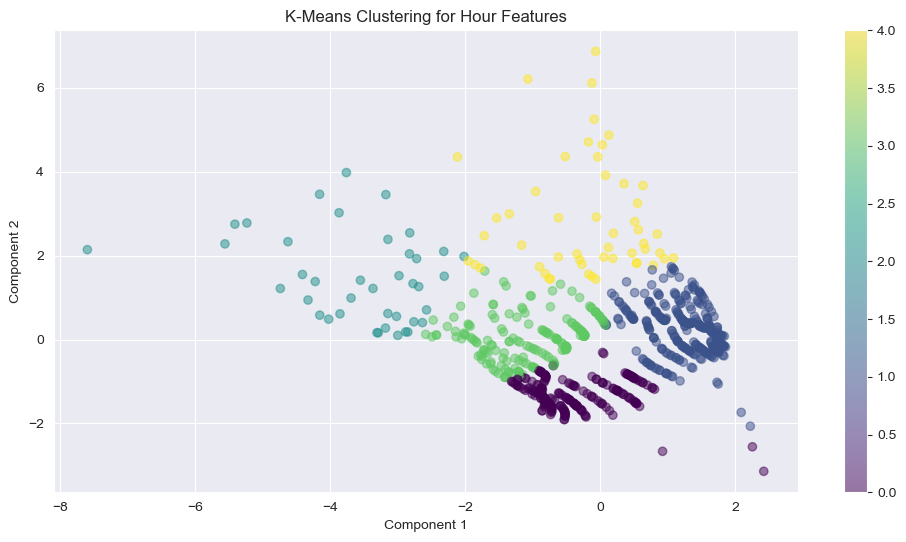

In [192]:
plot_clusters(data_transformed, labels, 'K-Means Clustering for Hour Features')

In [195]:
%%time
silhouette_avgs, inertia_values = find_optimal_clusters(sampled_df_cluster_normalised, features['hour'], 2, 11)

Processing fastdtw: 100%|██████████| 340725/340725 [03:51<00:00, 1469.18it/s]


Number of clusters: 2, Silhouette Score: 0.4380884710938285, Inertia: 1662.3036156436017


Processing fastdtw: 100%|██████████| 340725/340725 [03:47<00:00, 1496.34it/s]


Number of clusters: 3, Silhouette Score: 0.48103624186591154, Inertia: 1039.06425135699


Processing fastdtw: 100%|██████████| 340725/340725 [03:50<00:00, 1480.85it/s]


...

Number of clusters: 8, Silhouette Score: 0.39434159537157787, Inertia: 396.6189788219355


Processing fastdtw: 100%|██████████| 340725/340725 [03:49<00:00, 1487.32it/s]


Number of clusters: 9, Silhouette Score: 0.3875588096339203, Inertia: 342.2591751311009


Processing fastdtw: 100%|██████████| 340725/340725 [03:45<00:00, 1508.16it/s]


Number of clusters: 10, Silhouette Score: 0.38065492666057926, Inertia: 326.04043848729634
CPU times: total: 7min 21s
Wall time: 36min 43s


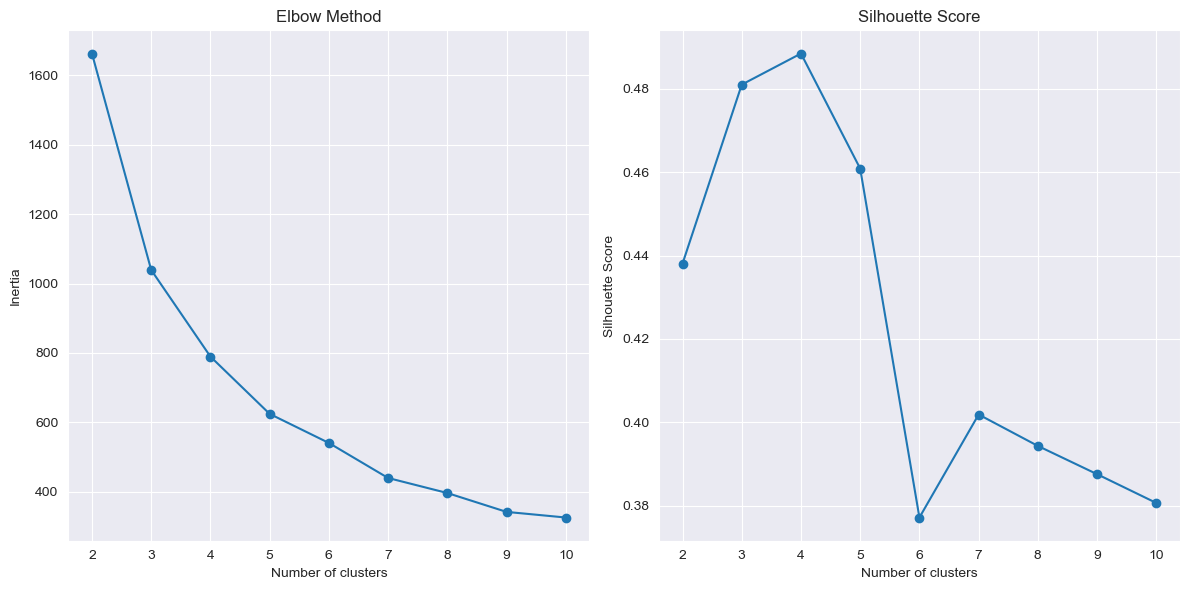

In [203]:
plot_elbow_and_silhouette(inertia_values, silhouette_avgs, 2, 11)

It can be seen that a better value for n_clusters is 10

In [204]:
labels, data_transformed = cluster_features(sampled_df_cluster_normalised, features['hour'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [03:55<00:00, 1449.63it/s]


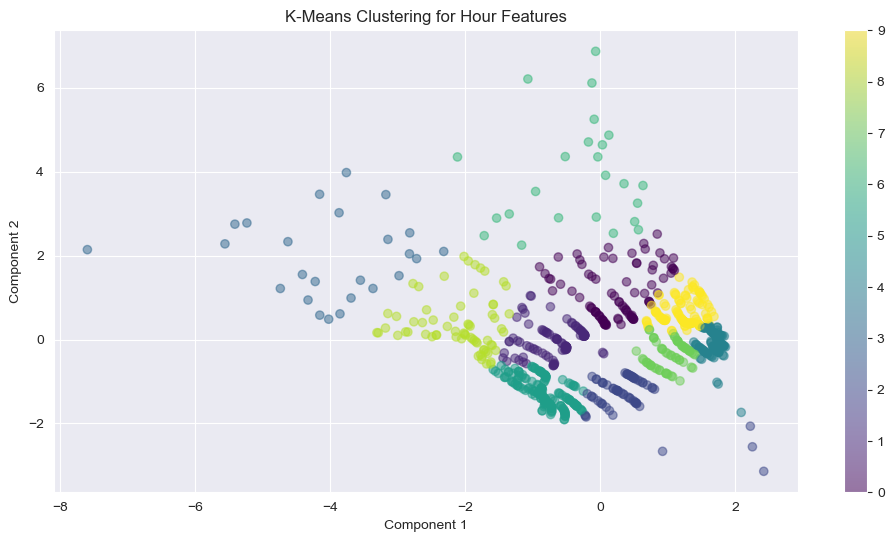

In [205]:
plot_clusters(data_transformed, labels, 'K-Means Clustering for Hour Features')

In [215]:
# def extract_cluster_centers(df, labels):
#     # Merge labels into raw data
#     df['cluster_label'] = labels
# 
#     # Grouped according to cluster labels and calculated the mean for each grouping
#     cluster_centers = df.groupby('cluster_label').mean().iloc[:, 1:]
# 
#     return cluster_centers

In [216]:
# def visualize_cluster_centers(cluster_centers):
#     # Visualisation of clustering centre eigenvalues
#     cluster_centers.plot(kind='bar', figsize=(12, 6))
#     plt.title('Cluster Centers')
#     plt.xlabel('Cluster Label')
#     plt.ylabel('Feature Value')
#     plt.xticks(rotation=0)
#     plt.legend(loc='upper right')
#     plt.show()

In [217]:
# # Extracting cluster centre eigenvalues
# cluster_centers = extract_cluster_centers(sampled_df_cluster_normalised, labels)

In [218]:
# # Visualisation of clustering centre eigenvalues
# visualize_cluster_centers(cluster_centers)

The figure shows the grouping based on "energy" and "hour_sin" and "hour_cos". These sine and cosine transformations capture the periodicity of the day, effectively mapping the 24-hour clock into a circular two-dimensional space where similar times are close to each other, regardless of whether it is morning or afternoon.
Inverting the clustering results to look at the eigenvalues at the centre of their clusters yields typical energy-hours models.
These models may reflect:
- Groups of households with similar energy consumption patterns at different times of the day.
- Clusters of high energy use that may be consistent with morning peaks and evening peaks.
- The circular distribution of clusters would reflect the natural time cycle over a 24-hour period, i.e., midnight as opposed to noon, and 6 am as opposed to 6 pm.
Given the sin-cos asymmetry effect, some explanation can be given for the fact that certain clusters appear more pronounced at particular times of the day. For example, if a cluster is densely distributed around vectors ("hour_sin" and "hour_cos") indicating the time of night, it may indicate that a group of households has peak energy consumption in the evening.

Clustering by day

In [219]:
day_labels, day_data_transformed = cluster_features(sampled_df_cluster_normalised, features['day'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [03:56<00:00, 1438.98it/s]


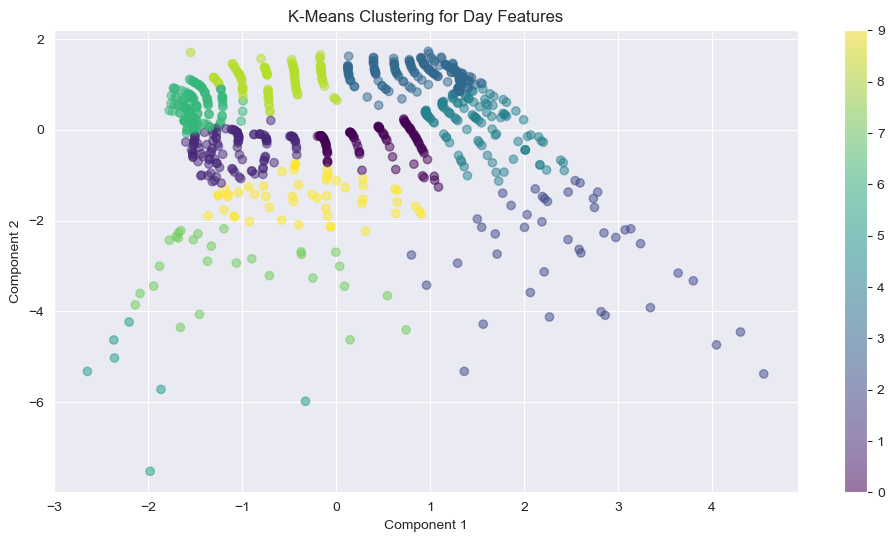

In [220]:
plot_clusters(day_data_transformed, day_labels, 'K-Means Clustering for Day Features')

Analyses similar to those above

Clustering by 'day_of_week'

In [295]:
day_of_week_labels, day_of_week_data_transformed = cluster_features(sampled_df_cluster_normalised, features['day_of_week'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [04:12<00:00, 1347.07it/s]


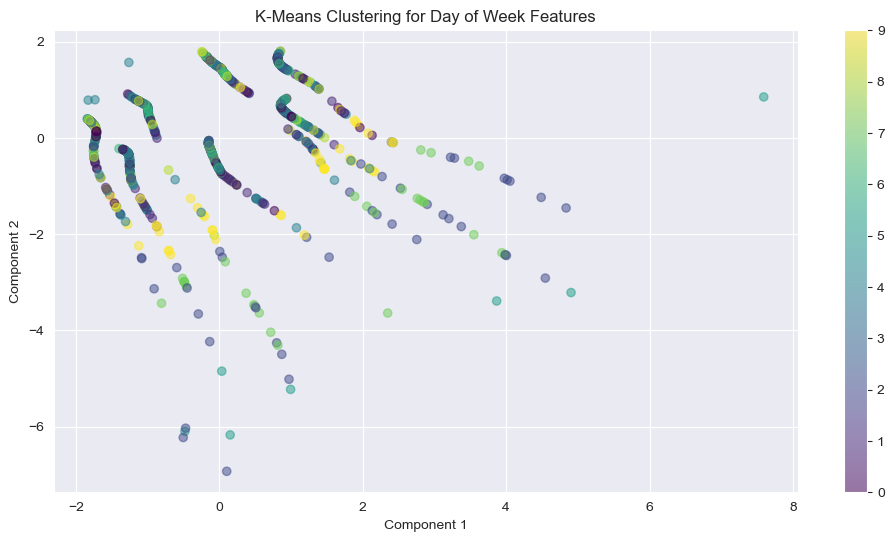

In [296]:
plot_clusters(day_of_week_data_transformed, day_labels, 'K-Means Clustering for Day of Week Features')

Clustering by 'month'

In [301]:
month_labels, month_data_transformed = cluster_features(sampled_df_cluster_normalised, features['month'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [04:14<00:00, 1339.87it/s]


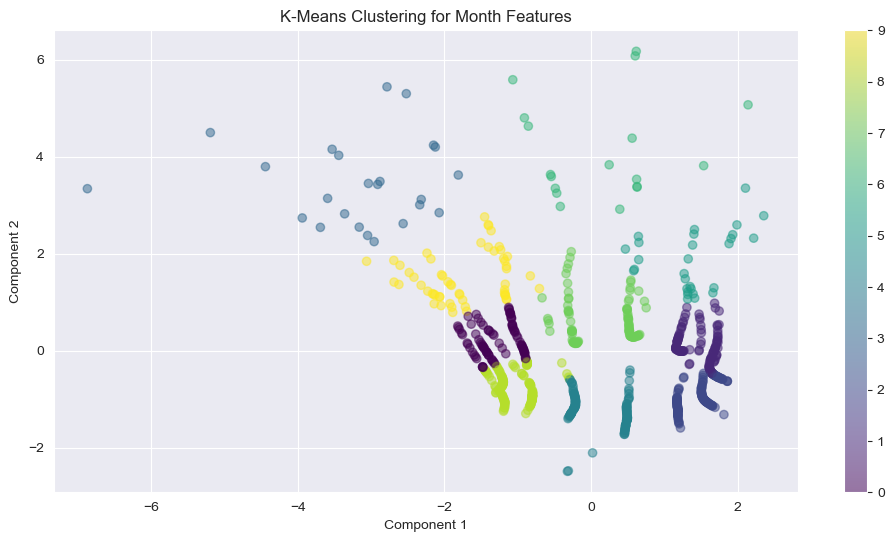

In [302]:
plot_clusters(month_data_transformed, month_labels, 'K-Means Clustering for Month Features')

Clustering by 'quarter'

In [305]:
# quarter_labels, quarter_data_transformed = cluster_features(sampled_df_cluster_normalised, features['quarter'], n_clusters=10, mode='cluster')

In [306]:
# plot_clusters(quarter_data_transformed, quarter_labels, 'K-Means Clustering for Quarter Features')

Clustering by 'year'

In [307]:
# year_labels, year_data_transformed = cluster_features(sampled_df_cluster_normalised, features['year'], n_clusters=10, mode='cluster')

In [308]:
# plot_clusters(year_data_transformed, year_labels, 'K-Means Clustering for Year Features')

Clustering by 'visibility'

In [303]:
visibility_labels, visibility_data_transformed = cluster_features(sampled_df_cluster_normalised, features['visibility'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [04:17<00:00, 1324.63it/s]


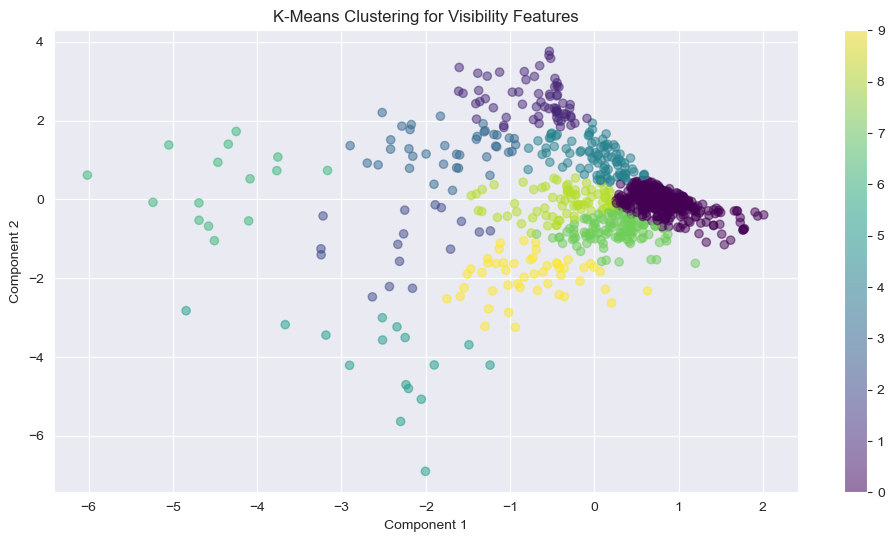

In [304]:
plot_clusters(visibility_data_transformed, visibility_labels, 'K-Means Clustering for Visibility Features')

Clustering by 'windSpeed'

In [309]:
# windSpeed_labels, windSpeed_data_transformed = cluster_features(sampled_df_cluster_normalised, features['windSpeed'], n_clusters=10, mode='cluster')

In [310]:
# plot_clusters(windSpeed_data_transformed, windSpeed_labels, 'K-Means Clustering for WindSpeed Features')

Clustering by 'precipType'

In [311]:
# precipType_labels, precipType_data_transformed = cluster_features(sampled_df_cluster_normalised, features['precipType'], n_clusters=10, mode='cluster')

In [312]:
# plot_clusters(precipType_data_transformed, precipType_labels, 'K-Means Clustering for PrecipType Features')

Clustering by 'humidity'

In [313]:
# humidity_labels, humidity_data_transformed = cluster_features(sampled_df_cluster_normalised, features['humidity'], n_clusters=10, mode='cluster')

In [314]:
# plot_clusters(humidity_data_transformed, humidity_labels, 'K-Means Clustering for Humidity Features')

Analyses similar to those above

Clustering by 'weather'

In [297]:
weather_labels, weather_data_transformed = cluster_features(sampled_df_cluster_normalised, features['weather'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [04:17<00:00, 1325.51it/s]


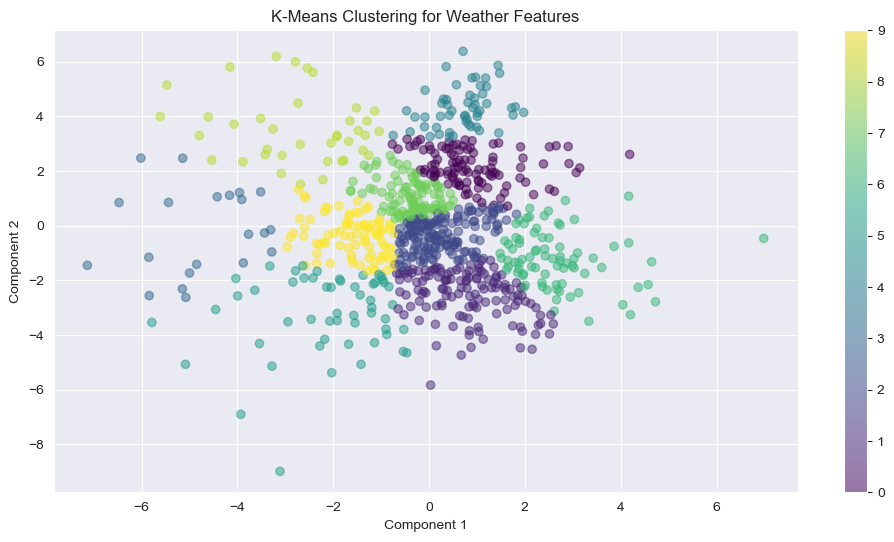

In [298]:
plot_clusters(weather_data_transformed, weather_labels, 'K-Means Clustering for Weather Features')

Clustering by 'temperature'

In [299]:
temperature_labels, temperature_data_transformed = cluster_features(sampled_df_cluster_normalised, features['temperature'], n_clusters=10, mode='cluster')

Processing fastdtw: 100%|██████████| 340725/340725 [04:08<00:00, 1369.78it/s]


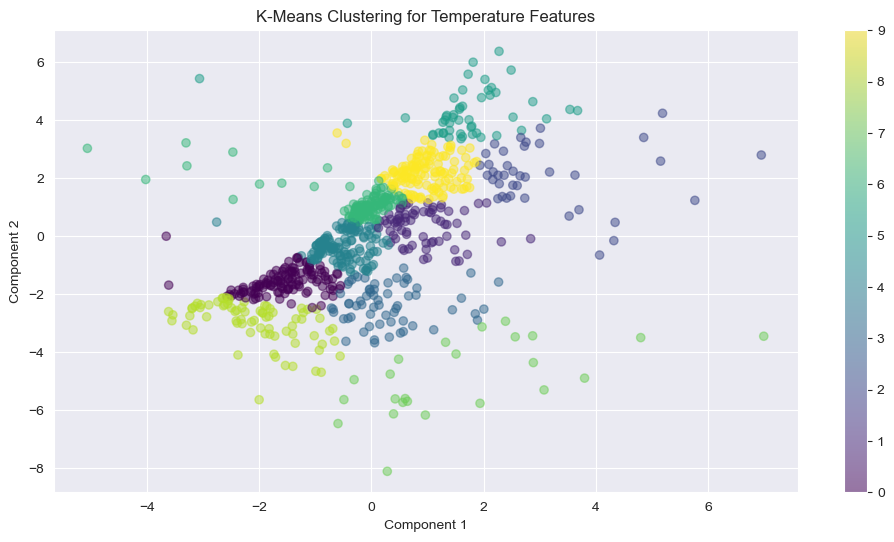

In [300]:
plot_clusters(temperature_data_transformed, temperature_labels, 'K-Means Clustering for Temperature Features')

The clustering process for the keys of the subsequent FEATURES is more or less the same, and due to the length, only the above ideas are shown here.

# 4. Conclusion
Using data from smart meter readings and weather conditions in the London area, this study uses time-series clustering analysis to reveal patterns and fluctuations in household energy consumption. By analyzing the daily and hourly energy consumption of households, and taking into account the impact of weather factors on energy use, the results show daily and seasonal trends in household energy consumption. The advantage of this study is to optimize the clustering efficiency of large-scale data sets by using the combination of Mini-Batch K-Means and DTW. The clustering results not only identify peak periods of energy consumption, but also reveal households' energy use behavior at different times, helping to further understand and predict household energy consumption and providing valuable insights for urban planners, energy providers and policymakers to achieve more efficient energy management and planning in urban environments.

References
Chavan, M., Patil, A., Dalvi, L. and Patil, A., 2015. Mini batch k-means clustering on large dataset. Int. J. Sci. Eng. Technol. Res, 4(07), pp.1356-1358.
Jean-Michel D. (2018). Smart Meters in London. [Online] Available at: https://www.kaggle.com/datasets/jeanmidev/smart-meters-in-london/data [Accessed 24 March 2024].
Kang, J. and Reiner, D.M., 2022. Off seasons, holidays and extreme weather events: using data-mining techniques on smart meter and energy consumption data from China. Energy Research & Social Science, 89, p.102637.
Kiprijanovska, I., Stankoski, S., Ilievski, I., Jovanovski, S., Gams, M. and Gjoreski, H., 2020. Houseec: Day-ahead household electrical energy consumption forecasting using deep learning. Energies, 13(10), p.2672.
Liao, T.W., 2005. Clustering of time series data—a survey. Pattern recognition, 38(11), pp.1857-1874.
Müller, M., 2007. Dynamic time warping. Information retrieval for music and motion, pp.69-84.
